# Required libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

files = os.listdir("/content")

print("Files available in /content:")
for file in files:
    print(file)

Files available in /content:
.config
City.xlsx
User.xlsx
Mode.xlsx
Item.xlsx
Type.xlsx
Transaction.xlsx
Continent.xlsx
Country.xlsx
Region.xlsx
sample_data


# Load dataset

In [3]:
import pandas as pd

city_df = pd.read_excel("/content/City.xlsx")

print("City dataset loaded successfully!")
print("Rows:", city_df.shape[0])
print("Columns:", city_df.shape[1])

City dataset loaded successfully!
Rows: 9143
Columns: 3


In [4]:
city_df.head()

,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3


In [5]:
city_df.dtypes

,0
CityId,int64
CityName,object
CountryId,int64


In [6]:
city_df.isnull().sum()

,0
CityId,0
CityName,1
CountryId,0


In [7]:
city_df[city_df["CityName"].isnull()]

,CityId,CityName,CountryId
6879,6879,NaN,151


In [8]:
city_df[city_df["CountryId"] == 151]

,CityId,CityName,CountryId
6793,6793,Agrate Brianza,151
6794,6794,Ancona,151
6795,6795,Appiano sulla Strada del Vino,151
6796,6796,Arese,151
6797,6797,Arezzo,151
...,...,...,...
6944,6944,Ventimiglia,151
6945,6945,Verbania,151
6946,6946,Verona,151
6947,6947,Vicenza,151


In [9]:
city_df[
    (city_df["CityId"] >= 6875) &
    (city_df["CityId"] <= 6885)
]

,CityId,CityName,CountryId
6875,6875,Monza,151
6876,6876,Murano,151
6877,6877,Naples,151
6878,6878,Nettuno,151
6879,6879,NaN,151
6880,6880,Novara,151
6881,6881,Novello,151
6882,6882,Padua,151
6883,6883,Palermo,151
6884,6884,Parma,151


In [10]:
transaction_df = pd.read_excel("/content/Transaction.xlsx")

print("Transaction dataset loaded successfully!")
print("Rows:", transaction_df.shape[0])
print("Columns:", transaction_df.shape[1])

Transaction dataset loaded successfully!
Rows: 52930
Columns: 7


In [11]:
transaction_df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [12]:
transaction_df.dtypes

,0
TransactionId,int64
UserId,int64
VisitYear,int64
VisitMonth,int64
VisitMode,int64
AttractionId,int64
Rating,int64


In [13]:
transaction_df.isnull().sum()

,0
TransactionId,0
UserId,0
VisitYear,0
VisitMonth,0
VisitMode,0
AttractionId,0
Rating,0


In [14]:
transaction_df.duplicated().sum()

np.int64(0)

In [15]:
transaction_df["VisitMonth"].unique()

array([10,  9,  8,  7,  6,  5,  4, 11,  1, 12,  3,  2])

In [16]:
transaction_df["Rating"].unique()

array([5, 3, 4, 1, 2])

In [17]:
transaction_df["VisitMode"].unique()

array([2, 4, 3, 5, 1])

In [18]:
mode_df = pd.read_excel("/content/Mode.xlsx")

print("Mode dataset loaded successfully!")
print("Rows:", mode_df.shape[0])
print("Columns:", mode_df.shape[1])

Mode dataset loaded successfully!
Rows: 6
Columns: 2


In [19]:
mode_df.head(10)

,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo


In [20]:
transaction_df["VisitMode"].value_counts()

,count
VisitMode,
2,21620
3,15217
4,10945
5,4525
1,623


In [21]:
transaction_df["AttractionId"].nunique()

30

In [22]:
item_df = pd.read_excel("/content/Item.xlsx")

print("Item dataset loaded successfully!")
print("Rows:", item_df.shape[0])
print("Columns:", item_df.shape[1])

Item dataset loaded successfully!
Rows: 30
Columns: 5


In [23]:
item_df.head()

,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


In [24]:
item_df.dtypes

,0
AttractionId,int64
AttractionCityId,int64
AttractionTypeId,int64
Attraction,object
AttractionAddress,object


In [25]:
item_df.isnull().sum()

,0
AttractionId,0
AttractionCityId,0
AttractionTypeId,0
Attraction,0
AttractionAddress,0


In [26]:
item_df.duplicated().sum()

np.int64(0)

In [27]:
item_df["AttractionId"].nunique()

30

In [28]:
transaction_attractions = set(transaction_df["AttractionId"])
item_attractions = set(item_df["AttractionId"])

print("Transaction Attraction IDs:", len(transaction_attractions))
print("Item Attraction IDs:", len(item_attractions))
print("Matching IDs:", len(transaction_attractions & item_attractions))

Transaction Attraction IDs: 30
Item Attraction IDs: 30
Matching IDs: 30


In [29]:
item_cities = set(item_df["AttractionCityId"])
city_ids = set(city_df["CityId"])

print("Item City IDs:", len(item_cities))
print("City IDs:", len(city_ids))
print("Matching City IDs:", len(item_cities & city_ids))

Item City IDs: 3
City IDs: 9143
Matching City IDs: 3


In [30]:
item_df["AttractionCityId"].unique()

array([1, 2, 3])

In [31]:
city_df[city_df["CityId"].isin([1, 2, 3])]

,CityId,CityName,CountryId
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2


In [32]:
city_df["CityId"].nunique()

9143

In [33]:
city_df.duplicated().sum()

np.int64(0)

In [34]:
country_df = pd.read_excel("/content/Country.xlsx")

print("Country dataset loaded successfully!")
print("Rows:", country_df.shape[0])
print("Columns:", country_df.shape[1])

Country dataset loaded successfully!
Rows: 165
Columns: 3


In [35]:
country_df.head()

,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1
3,3,Rwanda,1
4,4,Ethiopia,2


In [36]:
country_df.dtypes

,0
CountryId,int64
Country,object
RegionId,int64


In [37]:
country_df.isnull().sum()

,0
CountryId,0
Country,0
RegionId,0


In [38]:
country_df.duplicated().sum()

np.int64(0)

In [39]:
country_df["CountryId"].nunique()

165

In [40]:
region_df = pd.read_excel("/content/Region.xlsx")

print("Region dataset loaded successfully!")
print("Rows:", region_df.shape[0])
print("Columns:", region_df.shape[1])

Region dataset loaded successfully!
Rows: 22
Columns: 3


In [41]:
region_df.head()

,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1
3,North Africa,3,1
4,Southern Africa,4,1


In [42]:
region_df.dtypes

,0
Region,object
RegionId,int64
ContinentId,int64


In [43]:
region_df.isnull().sum()

,0
Region,0
RegionId,0
ContinentId,0


In [44]:
region_df.duplicated().sum()

np.int64(0)

In [45]:
region_df["RegionId"].nunique()

22

In [46]:
country_regions = set(country_df["RegionId"])
region_ids = set(region_df["RegionId"])

print("Country Region IDs:", len(country_regions))
print("Region IDs:", len(region_ids))
print("Matching Region IDs:", len(country_regions & region_ids))

Country Region IDs: 22
Region IDs: 22
Matching Region IDs: 22


In [47]:
continent_df = pd.read_excel("/content/Continent.xlsx")

print("Continent dataset loaded successfully!")
print("Rows:", continent_df.shape[0])
print("Columns:", continent_df.shape[1])

Continent dataset loaded successfully!
Rows: 6
Columns: 2


In [48]:
continent_df.head()

,ContinentId,Continent
0,0,-
1,1,Africa
2,2,America
3,3,Asia
4,4,Australia & Oceania


In [49]:
continent_df.dtypes

,0
ContinentId,int64
Continent,object


In [50]:
continent_df.isnull().sum()

,0
ContinentId,0
Continent,0


In [51]:
continent_df.duplicated().sum()

np.int64(0)

In [52]:
continent_df["ContinentId"].nunique()

6

In [53]:
region_continents = set(region_df["ContinentId"])
continent_ids = set(continent_df["ContinentId"])

print("Region Continent IDs:", len(region_continents))
print("Continent IDs:", len(continent_ids))
print("Matching Continent IDs:", len(region_continents & continent_ids))

Region Continent IDs: 6
Continent IDs: 6
Matching Continent IDs: 6


In [54]:
user_df = pd.read_excel("/content/User.xlsx")

print("User dataset loaded successfully!")
print("Rows:", user_df.shape[0])
print("Columns:", user_df.shape[1])

User dataset loaded successfully!
Rows: 33530
Columns: 5


In [55]:
user_df.head()

,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


In [56]:
user_df.dtypes

,0
UserId,int64
ContinentId,int64
RegionId,int64
CountryId,int64
CityId,float64


In [57]:
user_df.isnull().sum()

,0
UserId,0
ContinentId,0
RegionId,0
CountryId,0
CityId,4


In [58]:
user_df[user_df["CityId"].isnull()]

,UserId,ContinentId,RegionId,CountryId,CityId
2279,7175,5,17,135,NaN
6027,17595,1,4,22,NaN
21303,56972,5,17,135,NaN
25494,67461,5,17,135,NaN


In [59]:
city_df[city_df["CountryId"] == 135]

,CityId,CityName,CountryId
6205,6205,Aarau,135
6206,6206,Aclens,135
6207,6207,Affoltern am Albis,135
6208,6208,Altdorf,135
6209,6209,Asuel,135
...,...,...,...
6323,6323,Zermatt,135
6324,6324,Zuerich,135
6325,6325,Zug,135
6326,6326,Zurich,135


In [60]:
city_df[city_df["CountryId"] == 22]

,CityId,CityName,CountryId
93,93,Alberton,22
94,94,Ballito,22
95,95,Barrydale,22
96,96,Bedfordview,22
97,97,Benoni,22
...,...,...,...
208,208,westbrook,22
209,209,Western Cape,22
210,210,Westville,22
211,211,White River,22


In [61]:
transaction_df[transaction_df["UserId"] == 7175]

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
7134,10437,7175,2016,10,5,640,5
34799,71574,7175,2016,10,5,748,5


In [62]:
item_df[item_df["AttractionId"].isin([640, 748])]

,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
6,748,1,72,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia"


In [63]:
city_df[city_df["CityId"] == 1]

,CityId,CityName,CountryId
1,1,Douala,1


In [64]:
city_df[city_df["CityId"] == 1][["CityId", "CityName", "CountryId"]]

,CityId,CityName,CountryId
1,1,Douala,1


In [65]:
transaction_df[transaction_df["UserId"] == 17595]

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
22283,35006,17595,2014,12,3,673,4
36610,74011,17595,2014,12,3,748,5


In [66]:
item_df[item_df["AttractionId"].isin([673, 748])][
    ["AttractionId", "AttractionCityId", "Attraction"]
]

,AttractionId,AttractionCityId,Attraction
4,673,1,Seminyak Beach
6,748,1,Tegalalang Rice Terrace


In [67]:
transaction_df[transaction_df["UserId"] == 56972]


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
21190,33604,56972,2016,12,2,673,4
26249,42487,56972,2016,12,2,650,5
34600,71286,56972,2016,12,2,748,5


In [68]:
item_df[item_df["AttractionId"].isin([673, 650, 748])][
    ["AttractionId", "AttractionCityId", "Attraction"]
]

,AttractionId,AttractionCityId,Attraction
3,650,1,Sanur Beach
4,673,1,Seminyak Beach
6,748,1,Tegalalang Rice Terrace


In [69]:
transaction_df[transaction_df["UserId"] == 67461]

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
31689,67298,67461,2019,5,4,748,5


In [70]:
user_df.duplicated().sum()

np.int64(0)

In [71]:
user_df["UserId"].nunique()

33530

In [72]:
transaction_users = set(transaction_df["UserId"])
user_ids = set(user_df["UserId"])

print("Transaction User IDs:", len(transaction_users))
print("User IDs:", len(user_ids))
print("Matching User IDs:", len(transaction_users & user_ids))

Transaction User IDs: 33530
User IDs: 33530
Matching User IDs: 33530


In [73]:
user_country_check = user_df.merge(
    country_df[["CountryId", "RegionId"]],
    on="CountryId",
    suffixes=("_user", "_country")
)

print("Total records:", len(user_country_check))
print(
    "Matching Region IDs:",
    (user_country_check["RegionId_user"] == user_country_check["RegionId_country"]).sum()
)

Total records: 33530
Matching Region IDs: 33529


In [74]:
user_country_check[
    user_country_check["RegionId_user"] != user_country_check["RegionId_country"]
]

,UserId,ContinentId,RegionId_user,CountryId,CityId,RegionId_country
30407,79730,5,20,76,2488.0,12


In [75]:
country_df[country_df["CountryId"] == 76]

,CountryId,Country,RegionId
76,76,Cyprus,12


In [76]:
region_df[region_df["RegionId"] == 12]

,Region,RegionId,ContinentId
12,Middle East,12,3


In [77]:
city_df[city_df["CityId"] == 2488]

,CityId,CityName,CountryId
2488,2488,Nicosia,76


In [78]:
user_region_check = user_df.merge(
    region_df[["RegionId", "ContinentId"]],
    on="RegionId",
    suffixes=("_user", "_region")
)

print("Total records:", len(user_region_check))
print(
    "Matching Continent IDs:",
    (user_region_check["ContinentId_user"] == user_region_check["ContinentId_region"]).sum()
)

Total records: 33530
Matching Continent IDs: 33511


In [79]:
user_region_check[
    user_region_check["ContinentId_user"] != user_region_check["ContinentId_region"]
]

,UserId,ContinentId_user,RegionId,CountryId,CityId,ContinentId_region
1384,4305,5,0,120,5688.0,0
6093,17778,5,0,120,5688.0,0
7297,21064,3,0,62,2253.0,0
8122,23154,3,0,62,2253.0,0
8845,25020,5,0,120,5688.0,0
12060,33805,3,0,62,2253.0,0
13271,36830,3,0,62,2253.0,0
14528,39883,3,0,62,2253.0,0
15901,43346,3,0,62,2253.0,0
16316,44388,3,0,62,2253.0,0


In [80]:
region_df[region_df["RegionId"] == 0]

,Region,RegionId,ContinentId
0,-,0,0


In [81]:
user_country_check = user_df.merge(
    country_df[["CountryId", "RegionId"]],
    on="CountryId",
    suffixes=("_user", "_country")
)

valid_region_users = user_country_check[
    user_country_check["RegionId_user"] != 0
]

print("Users with non-zero RegionId:", len(valid_region_users))
print(
    "Matching Region IDs:",
    (
        valid_region_users["RegionId_user"]
        == valid_region_users["RegionId_country"]
    ).sum()
)

Users with non-zero RegionId: 33511
Matching Region IDs: 33510


In [82]:
user_city_check = user_df.merge(
    city_df[["CityId", "CountryId"]],
    on="CityId",
    suffixes=("_user", "_city")
)

valid_city_users = user_city_check[
    user_city_check["CityId"].notna()
]

print("Users with valid CityId:", len(valid_city_users))
print(
    "Matching Country IDs:",
    (
        valid_city_users["CountryId_user"]
        == valid_city_users["CountryId_city"]
    ).sum()
)

Users with valid CityId: 33526
Matching Country IDs: 27482


In [83]:
city_df["CityId"].nunique()

9143

In [84]:
len(city_df)

9143

In [85]:
city_country_mismatch = valid_city_users[
    valid_city_users["CountryId_user"] != valid_city_users["CountryId_city"]
]

print("Mismatched records:", len(city_country_mismatch))

Mismatched records: 6044


In [86]:
city_country_mismatch.head(10)

,UserId,ContinentId,RegionId,CountryId_user,CityId,CountryId_city
0,14,5,20,155,220.0,27
5,26,5,21,163,4485.0,109
12,37,5,21,158,721.0,51
17,52,4,15,109,535.0,48
21,59,5,20,150,692.0,51
23,61,4,15,109,535.0,48
32,92,5,21,163,426.0,48
44,122,4,15,109,1434.0,51
52,147,5,19,145,1963.0,51
55,153,4,15,109,1434.0,51


In [87]:
id_pairs = (
    city_country_mismatch
    .groupby(["CountryId_user", "CountryId_city"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

id_pairs.head(20)

,CountryId_user,CountryId_city,Count
28,109,51,1734
67,163,48,1110
27,109,48,1056
68,163,51,649
42,138,51,225
69,163,109,208
63,162,51,130
23,109,22,107
7,51,48,81
61,160,51,80


In [88]:
country_df[country_df["CountryId"] == 109]

,CountryId,Country,RegionId
109,109,Australia,15


In [89]:
country_df[country_df["CountryId"] == 51]

,CountryId,Country,RegionId
51,51,United States,8


In [90]:
city_df[city_df["CountryId"] == 51].head(10)

,CityId,CityName,CountryId
639,639,-,51
640,640,Aberdeen,51
641,641,Addison,51
642,642,Agawam,51
643,643,Agoura Hills,51
644,644,Akron,51
645,645,Alameda,51
646,646,Alamo,51
647,647,Alamogordo,51
648,648,Alaska,51


In [91]:
user_df[user_df["CityId"] == 640][
    ["UserId", "ContinentId", "RegionId", "CountryId", "CityId"]
].head(10)

,UserId,ContinentId,RegionId,CountryId,CityId
1702,5267,5,21,163,640.0
5338,15546,5,21,163,640.0
5427,15794,5,21,163,640.0
6773,19612,5,21,163,640.0
9958,28338,5,21,163,640.0
10139,28799,5,21,163,640.0
10724,30389,5,21,163,640.0
13021,36198,5,21,163,640.0
17129,46506,5,21,163,640.0
17760,48034,2,8,51,640.0


In [92]:
country_df[country_df["CountryId"] == 163]

,CountryId,Country,RegionId
163,163,United Kingdom,21


In [93]:
region_df[region_df["RegionId"] == 8]

,Region,RegionId,ContinentId
8,Northern America,8,2


In [94]:
country_region_check = user_df.merge(
    country_df[["CountryId", "RegionId"]],
    on="CountryId",
    suffixes=("_user", "_country")
)

country_region_mismatch = country_region_check[
    country_region_check["RegionId_user"] != country_region_check["RegionId_country"]
]

print("Country → Region mismatches:", len(country_region_mismatch))

Country → Region mismatches: 1


In [95]:
city_country_check = city_df.merge(
    country_df[["CountryId", "RegionId"]],
    on="CountryId",
    how="left"
)

print("Total city records:", len(city_country_check))
print("Missing country mapping:",
      city_country_check["RegionId"].isna().sum())

Total city records: 9143
Missing country mapping: 0


In [96]:
city_country_variation = (
    user_df[user_df["CityId"].notna()]
    .groupby("CityId")["CountryId"]
    .nunique()
)

print("City IDs with multiple User CountryIds:",
      (city_country_variation > 1).sum())

City IDs with multiple User CountryIds: 194


In [97]:
ambiguous_city_ids = city_country_variation[
    city_country_variation > 1
].index

ambiguous_users = user_df[
    user_df["CityId"].isin(ambiguous_city_ids)
]

print("Ambiguous City IDs:", len(ambiguous_city_ids))
print("Users with ambiguous City IDs:", len(ambiguous_users))

Ambiguous City IDs: 194
Users with ambiguous City IDs: 6869


In [98]:
ambiguous_mismatch = ambiguous_users.merge(
    city_df[["CityId", "CountryId"]],
    on="CityId",
    suffixes=("_user", "_city")
)

print(
    "Ambiguous users with Country mismatch:",
    (
        ambiguous_mismatch["CountryId_user"]
        != ambiguous_mismatch["CountryId_city"]
    ).sum()
)

Ambiguous users with Country mismatch: 4262


In [99]:
city_country_counts = (
    user_df[user_df["CityId"].notna()]
    .groupby(["CityId", "CountryId"])
    .size()
    .reset_index(name="Count")
    .sort_values(["CityId", "Count"], ascending=[True, False])
)

city_country_counts.head(20)

,CityId,CountryId,Count
0,1.0,1,1
1,3.0,2,1
2,4.0,3,2
3,6.0,4,1
4,11.0,5,7
5,12.0,5,1
6,14.0,6,1
7,15.0,6,1
8,16.0,6,1
9,17.0,6,1


In [100]:
city_user_country_check = city_country_counts.merge(
    city_df[["CityId", "CountryId"]],
    on="CityId",
    how="left",
    suffixes=("_user", "_city")
)

city_user_country_check.head(20)

,CityId,CountryId_user,Count,CountryId_city
0,1.0,1,1,1
1,3.0,2,1,2
2,4.0,3,2,3
3,6.0,4,1,4
4,11.0,5,7,5
5,12.0,5,1,5
6,14.0,6,1,6
7,15.0,6,1,6
8,16.0,6,1,6
9,17.0,6,1,6


In [101]:
user_location_check = user_df.merge(
    country_df[["CountryId", "RegionId"]],
    on="CountryId",
    how="left",
    suffixes=("_user", "_country")
)

user_location_check = user_location_check.merge(
    region_df[["RegionId", "ContinentId"]],
    left_on="RegionId_user",
    right_on="RegionId",
    how="left",
    suffixes=("", "_region")
)

print("Total users:", len(user_location_check))

print(
    "Country → Region matches:",
    (
        user_location_check["RegionId_user"]
        == user_location_check["RegionId_country"]
    ).sum()
)

print(
    "Region → Continent matches:",
    (
        user_location_check["ContinentId"]
        == user_location_check["ContinentId_region"]
    ).sum()
)

Total users: 33530
Country → Region matches: 33529
Region → Continent matches: 33511


In [102]:
# Start from User data
user_city_location_check = user_df[
    ["UserId", "ContinentId", "RegionId", "CountryId", "CityId"]
].copy()

# Add City's CountryId
user_city_location_check = user_city_location_check.merge(
    city_df[["CityId", "CountryId"]],
    on="CityId",
    how="left",
    suffixes=("_user", "_city")
)

# Add RegionId belonging to City's Country
user_city_location_check = user_city_location_check.merge(
    country_df[["CountryId", "RegionId"]],
    left_on="CountryId_city",
    right_on="CountryId",
    how="left"
)

# Rename the newly obtained RegionId
user_city_location_check.rename(
    columns={"RegionId_y": "RegionId_city"},
    inplace=True
)

# If pandas kept the original RegionId as RegionId_x
user_city_location_check.rename(
    columns={
        "RegionId_x": "RegionId_user",
        "ContinentId": "ContinentId_user"
    },
    inplace=True
)

print("Total records:", len(user_city_location_check))

print(
    "City → Country matches:",
    (
        user_city_location_check["CountryId_user"]
        ==
        user_city_location_check["CountryId_city"]
    ).sum()
)

print(
    "City Country → User Region matches:",
    (
        user_city_location_check["RegionId_user"]
        ==
        user_city_location_check["RegionId_city"]
    ).sum()
)

Total records: 33530
City → Country matches: 27482
City Country → User Region matches: 27583


In [103]:
mismatch_region_check = user_city_location_check[
    user_city_location_check["CountryId_user"]
    != user_city_location_check["CountryId_city"]
].copy()

print("Country mismatches:", len(mismatch_region_check))

print(
    "Region matches among country mismatches:",
    (
        mismatch_region_check["RegionId_user"]
        ==
        mismatch_region_check["RegionId_city"]
    ).sum()
)

print(
    "Region mismatches among country mismatches:",
    (
        mismatch_region_check["RegionId_user"]
        !=
        mismatch_region_check["RegionId_city"]
    ).sum()
)

Country mismatches: 6048
Region matches among country mismatches: 102
Region mismatches among country mismatches: 5946


In [104]:
valid_city_mismatches = user_city_location_check[
    user_city_location_check["CityId"].notna() &
    user_city_location_check["CountryId_user"].notna() &
    user_city_location_check["CountryId_city"].notna() &
    (
        user_city_location_check["CountryId_user"]
        !=
        user_city_location_check["CountryId_city"]
    )
].copy()

print("Exact City → Country mismatches:", len(valid_city_mismatches))

Exact City → Country mismatches: 6044


In [105]:
print(
    "Same Region:",
    (
        valid_city_mismatches["RegionId_user"]
        ==
        valid_city_mismatches["RegionId_city"]
    ).sum()
)

Same Region: 102


In [106]:
print(
    "Different Region:",
    (
        valid_city_mismatches["RegionId_user"]
        !=
        valid_city_mismatches["RegionId_city"]
    ).sum()
)

Different Region: 5942


In [107]:
# Get RegionId and ContinentId for the City's Country
city_hierarchy = city_df[["CityId", "CountryId"]].merge(
    country_df[["CountryId", "RegionId"]],
    on="CountryId",
    how="left"
).merge(
    region_df[["RegionId", "ContinentId"]],
    on="RegionId",
    how="left"
)

city_hierarchy = city_hierarchy.rename(columns={
    "CountryId": "CountryId_city",
    "RegionId": "RegionId_city",
    "ContinentId": "ContinentId_city"
})

# Merge User data with complete City hierarchy
continent_check = user_df[
    ["UserId", "ContinentId", "RegionId", "CountryId", "CityId"]
].merge(
    city_hierarchy,
    on="CityId",
    how="left"
)

continent_check = continent_check.rename(columns={
    "ContinentId": "ContinentId_user",
    "RegionId": "RegionId_user",
    "CountryId": "CountryId_user"
})

# Keep only exact 6,044 City → Country mismatches
valid_city_mismatches = continent_check[
    continent_check["CityId"].notna() &
    (
        continent_check["CountryId_user"]
        !=
        continent_check["CountryId_city"]
    )
].copy()

print("Exact City → Country mismatches:", len(valid_city_mismatches))

print(
    "Same Continent:",
    (
        valid_city_mismatches["ContinentId_user"]
        ==
        valid_city_mismatches["ContinentId_city"]
    ).sum()
)

print(
    "Different Continent:",
    (
        valid_city_mismatches["ContinentId_user"]
        !=
        valid_city_mismatches["ContinentId_city"]
    ).sum()
)

Exact City → Country mismatches: 6044
Same Continent: 139
Different Continent: 5905


In [108]:
location_combinations = (
    user_df[
        ["ContinentId", "RegionId", "CountryId", "CityId"]
    ]
    .value_counts()
    .reset_index(name="Count")
)

print("Unique location combinations:", len(location_combinations))
print(location_combinations.head(20))

Unique location combinations: 5762
    ContinentId  RegionId  CountryId  CityId  Count
0             3        14        106  3551.0   1784
1             4        15        109  1434.0   1501
2             4        15        109  4940.0   1229
3             5        21        163   426.0    995
4             4        15        109   535.0    978
5             2         8         51  1133.0    826
6             3        14        101  3098.0    749
7             4        15        109  3687.0    623
8             4        15        109  3915.0    554
9             3        14        103  3354.0    422
10            3        14        101  3013.0    386
11            3        13         93  2819.0    353
12            5        21        163  8745.0    321
13            5        17        130  6117.0    310
14            3        12         89  2623.0    270
15            3        14        101  3071.0    230
16            5        18        138   693.0    224
17            3        11    

In [109]:
print(
    "Users with complete location data:",
    user_df[
        ["ContinentId", "RegionId", "CountryId", "CityId"]
    ].notna().all(axis=1).sum()
)

Users with complete location data: 33526


In [110]:
user_transaction_city = transaction_df.merge(
    item_df[["AttractionId", "AttractionCityId"]],
    on="AttractionId",
    how="left"
)

print(user_transaction_city.head())
print("Total transaction records:", len(user_transaction_city))

   TransactionId  UserId  VisitYear  VisitMonth  VisitMode  AttractionId  \
0              3   70456       2022          10          2           640   
1              8    7567       2022          10          4           640   
2              9   79069       2022          10          3           640   
3             10   31019       2022          10          3           640   
4             15   43611       2022          10          2           640   

   Rating  AttractionCityId  
0       5                 1  
1       5                 1  
2       5                 1  
3       3                 1  
4       3                 1  
Total transaction records: 52930


In [111]:
[x for x in dir() if hasattr(globals()[x], "shape") and hasattr(globals()[x], "columns")]

['_',
 '_100',
 '_11',
 '_19',
 '_23',
 '_31',
 '_35',
 '_4',
 '_41',
 '_48',
 '_55',
 '_58',
 '_59',
 '_60',
 '_61',
 '_62',
 '_63',
 '_64',
 '_65',
 '_66',
 '_67',
 '_68',
 '_69',
 '_7',
 '_74',
 '_75',
 '_76',
 '_77',
 '_79',
 '_8',
 '_80',
 '_86',
 '_87',
 '_88',
 '_89',
 '_9',
 '_90',
 '_91',
 '_92',
 '_93',
 '_99',
 '__',
 '___',
 'ambiguous_mismatch',
 'ambiguous_users',
 'city_country_check',
 'city_country_counts',
 'city_country_mismatch',
 'city_df',
 'city_hierarchy',
 'city_user_country_check',
 'continent_check',
 'continent_df',
 'country_df',
 'country_region_check',
 'country_region_mismatch',
 'id_pairs',
 'item_df',
 'location_combinations',
 'mismatch_region_check',
 'mode_df',
 'region_df',
 'transaction_df',
 'user_city_check',
 'user_city_location_check',
 'user_country_check',
 'user_df',
 'user_location_check',
 'user_region_check',
 'user_transaction_city',
 'valid_city_mismatches',
 'valid_city_users',
 'valid_region_users']

In [112]:
user_transaction_city = transaction_df.merge(
    item_df[["AttractionId", "AttractionCityId"]],
    on="AttractionId",
    how="left"
)

user_transaction_city = user_transaction_city.merge(
    user_df[
        ["UserId", "CountryId", "RegionId", "ContinentId", "CityId"]
    ],
    on="UserId",
    how="left",
    suffixes=("_transaction", "_user")
)

print("Total transaction records:", len(user_transaction_city))

print(
    "Transactions with valid AttractionCityId:",
    user_transaction_city["AttractionCityId"].notna().sum()
)

Total transaction records: 52930
Transactions with valid AttractionCityId: 52930


In [113]:
user_transaction_city["CityMatch"] = (
    user_transaction_city["CityId"]
    ==
    user_transaction_city["AttractionCityId"]
)

print(
    "User City = Attraction City:",
    user_transaction_city["CityMatch"].sum()
)

print(
    "User City != Attraction City:",
    (~user_transaction_city["CityMatch"]).sum()
)

User City = Attraction City: 2
User City != Attraction City: 52928


In [114]:
datasets = {
    "User": user_df,
    "City": city_df,
    "Country": country_df,
    "Region": region_df,
    "Continent": continent_df,
    "Transaction": transaction_df,
    "Item/Attraction": item_df,
    "Mode": mode_df
}

for name, df in datasets.items():
    print(f"{name:15} → Rows: {len(df):6} | Columns: {len(df.columns):2}")

User            → Rows:  33530 | Columns:  5
City            → Rows:   9143 | Columns:  3
Country         → Rows:    165 | Columns:  3
Region          → Rows:     22 | Columns:  3
Continent       → Rows:      6 | Columns:  2
Transaction     → Rows:  52930 | Columns:  7
Item/Attraction → Rows:     30 | Columns:  5
Mode            → Rows:      6 | Columns:  2


In [115]:
for name, df in datasets.items():
    print(f"{name:15} → Duplicate rows: {df.duplicated().sum()}")

User            → Duplicate rows: 0
City            → Duplicate rows: 0
Country         → Duplicate rows: 0
Region          → Duplicate rows: 0
Continent       → Duplicate rows: 0
Transaction     → Duplicate rows: 0
Item/Attraction → Duplicate rows: 0
Mode            → Duplicate rows: 0


In [116]:
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(df.dtypes)


User
UserId           int64
ContinentId      int64
RegionId         int64
CountryId        int64
CityId         float64
dtype: object

City
CityId        int64
CityName     object
CountryId     int64
dtype: object

Country
CountryId     int64
Country      object
RegionId      int64
dtype: object

Region
Region         object
RegionId        int64
ContinentId     int64
dtype: object

Continent
ContinentId     int64
Continent      object
dtype: object

Transaction
TransactionId    int64
UserId           int64
VisitYear        int64
VisitMonth       int64
VisitMode        int64
AttractionId     int64
Rating           int64
dtype: object

Item/Attraction
AttractionId          int64
AttractionCityId      int64
AttractionTypeId      int64
Attraction           object
AttractionAddress    object
dtype: object

Mode
VisitModeId     int64
VisitMode      object
dtype: object


In [117]:
print(user_df.dtypes)

UserId           int64
ContinentId      int64
RegionId         int64
CountryId        int64
CityId         float64
dtype: object


In [118]:
missing_city_users = user_df[user_df["CityId"].isna()]

print(missing_city_users)

       UserId  ContinentId  RegionId  CountryId  CityId
2279     7175            5        17        135     NaN
6027    17595            1         4         22     NaN
21303   56972            5        17        135     NaN
25494   67461            5        17        135     NaN


In [119]:
missing_city_transactions = transaction_df[
    transaction_df["UserId"].isin(
        missing_city_users["UserId"]
    )
]

print(missing_city_transactions)

       TransactionId  UserId  VisitYear  VisitMonth  VisitMode  AttractionId  \
7134           10437    7175       2016          10          5           640   
21190          33604   56972       2016          12          2           673   
22283          35006   17595       2014          12          3           673   
26249          42487   56972       2016          12          2           650   
31689          67298   67461       2019           5          4           748   
34600          71286   56972       2016          12          2           748   
34799          71574    7175       2016          10          5           748   
36610          74011   17595       2014          12          3           748   

       Rating  
7134        5  
21190       4  
22283       4  
26249       5  
31689       5  
34600       5  
34799       5  
36610       5  


In [120]:
print(
    "Transactions for missing-City users:",
    len(missing_city_transactions)
)

Transactions for missing-City users: 8


In [121]:
missing_city_attractions = missing_city_transactions.merge(
    item_df[
        ["AttractionId", "AttractionCityId", "Attraction"]
    ],
    on="AttractionId",
    how="left"
)

print(missing_city_attractions[
    [
        "UserId",
        "AttractionId",
        "AttractionCityId",
        "Attraction",
        "Rating"
    ]
])

   UserId  AttractionId  AttractionCityId                      Attraction  \
0    7175           640                 1  Sacred Monkey Forest Sanctuary   
1   56972           673                 1                  Seminyak Beach   
2   17595           673                 1                  Seminyak Beach   
3   56972           650                 1                     Sanur Beach   
4   67461           748                 1         Tegalalang Rice Terrace   
5   56972           748                 1         Tegalalang Rice Terrace   
6    7175           748                 1         Tegalalang Rice Terrace   
7   17595           748                 1         Tegalalang Rice Terrace   

   Rating  
0       5  
1       4  
2       4  
3       5  
4       5  
5       5  
6       5  
7       5  


In [122]:
for name, df in datasets.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)


User
CityId    4
dtype: int64

City
CityName    1
dtype: int64

Country
No missing values

Region
No missing values

Continent
No missing values

Transaction
No missing values

Item/Attraction
No missing values

Mode
No missing values


In [123]:
missing_city_name = city_df[city_df["CityName"].isna()]

print(missing_city_name)

      CityId CityName  CountryId
6879    6879      NaN        151


In [124]:
print("Missing CityName records:", len(missing_city_name))

Missing CityName records: 1


In [125]:
country_df[country_df["CountryId"] == 151]

,CountryId,Country,RegionId
151,151,Italy,20


In [126]:
italy_cities = city_df[
    city_df["CountryId"] == 151
].sort_values("CityId")

print(italy_cities.to_string(index=False))

 CityId                         CityName  CountryId
   6793                   Agrate Brianza        151
   6794                           Ancona        151
   6795    Appiano sulla Strada del Vino        151
   6796                            Arese        151
   6797                           Arezzo        151
   6798                            Arona        151
   6799                        Arzignano        151
   6800                           Asiago        151
   6801                           Assisi        151
   6802                         Avellino        151
   6803                             Bari        151
   6804               Bassano Del Grappa        151
   6805                              Bee        151
   6806                          Bergamo        151
   6807                           Biella        151
   6808                          Bologna        151
   6809                        Bracciano        151
   6810                          Brescia        151
   6811     

In [127]:
users_with_6879 = user_df[user_df["CityId"] == 6879]

print(users_with_6879)
print("Users with CityId 6879:", len(users_with_6879))

Empty DataFrame
Columns: [UserId, ContinentId, RegionId, CountryId, CityId]
Index: []
Users with CityId 6879: 0


In [128]:
attraction_6879 = item_df[
    item_df["AttractionCityId"] == 6879
]

print(attraction_6879)
print("Attractions in CityId 6879:", len(attraction_6879))

Empty DataFrame
Columns: [AttractionId, AttractionCityId, AttractionTypeId, Attraction, AttractionAddress]
Index: []
Attractions in CityId 6879: 0


In [129]:
print(item_df.to_string(index=False))

 AttractionId  AttractionCityId  AttractionTypeId                         Attraction                                                                      AttractionAddress
          369                 1                13                  Kuta Beach - Bali                                                                                   Kuta
          481                 1                13                     Nusa Dua Beach                                         Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia
          640                 1                63     Sacred Monkey Forest Sanctuary                                                Jl. Monkey Forest, Ubud 80571 Indonesia
          650                 1                13                        Sanur Beach                                                                                  Sanur
          673                 1                13                     Seminyak Beach                                                        

In [130]:
attraction_type_counts = (
    item_df.groupby("AttractionTypeId")
    .size()
    .reset_index(name="AttractionCount")
    .sort_values("AttractionCount", ascending=False)
)

print(attraction_type_counts.to_string(index=False))

 AttractionTypeId  AttractionCount
               13                6
               72                3
                2                2
               61                2
               63                2
               91                2
               93                2
               76                2
               10                1
               44                1
               45                1
               19                1
               34                1
               82                1
               64                1
               84                1
               92                1


In [131]:
print("Total transactions:", len(transaction_df))
print("Unique TransactionIds:", transaction_df["TransactionId"].nunique())

Total transactions: 52930
Unique TransactionIds: 52930


In [132]:
duplicate_transaction_ids = transaction_df[
    transaction_df["TransactionId"].duplicated(keep=False)
]

print(duplicate_transaction_ids)

Empty DataFrame
Columns: [TransactionId, UserId, VisitYear, VisitMonth, VisitMode, AttractionId, Rating]
Index: []


In [133]:
print("Visit Year:")
print(sorted(transaction_df["VisitYear"].unique()))

print("\nVisit Month:")
print(sorted(transaction_df["VisitMonth"].unique()))

print("\nVisit Mode:")
print(sorted(transaction_df["VisitMode"].unique()))

print("\nRating:")
print(sorted(transaction_df["Rating"].unique()))

Visit Year:
[np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Visit Month:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Visit Mode:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rating:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [134]:
transaction_user_check = transaction_df.merge(
    user_df[["UserId"]],
    on="UserId",
    how="left",
    indicator=True
)

print(
    transaction_user_check["_merge"]
    .value_counts()
)

_merge
both          52930
left_only         0
right_only        0
Name: count, dtype: int64


In [135]:
transaction_attraction_check = transaction_df.merge(
    item_df[["AttractionId"]],
    on="AttractionId",
    how="left",
    indicator=True
)

print(
    transaction_attraction_check["_merge"]
    .value_counts()
)

_merge
both          52930
left_only         0
right_only        0
Name: count, dtype: int64


In [136]:
attraction_city_check = item_df.merge(
    city_df[["CityId"]],
    left_on="AttractionCityId",
    right_on="CityId",
    how="left",
    indicator=True
)

print(attraction_city_check["_merge"].value_counts())

_merge
both          30
left_only      0
right_only     0
Name: count, dtype: int64


In [137]:
city_country_fk_check = city_df.merge(
    country_df[["CountryId"]],
    on="CountryId",
    how="left",
    indicator=True
)

print(city_country_fk_check["_merge"].value_counts())

_merge
both          9143
left_only        0
right_only       0
Name: count, dtype: int64


In [138]:
country_region_fk_check = country_df.merge(
    region_df[["RegionId"]],
    on="RegionId",
    how="left",
    indicator=True
)

print(country_region_fk_check["_merge"].value_counts())

_merge
both          165
left_only       0
right_only      0
Name: count, dtype: int64


In [139]:
region_continent_fk_check = region_df.merge(
    continent_df[["ContinentId"]],
    on="ContinentId",
    how="left",
    indicator=True
)

print(region_continent_fk_check["_merge"].value_counts())

_merge
both          22
left_only      0
right_only     0
Name: count, dtype: int64


In [140]:
transaction_mode_check = transaction_df.merge(
    mode_df[["VisitModeId"]],
    left_on="VisitMode",
    right_on="VisitModeId",
    how="left",
    indicator=True
)

print(transaction_mode_check["_merge"].value_counts())

_merge
both          52930
left_only         0
right_only        0
Name: count, dtype: int64


In [141]:
print("Missing AttractionTypeId:",
      item_df["AttractionTypeId"].isna().sum())

print("\nUnique AttractionTypeIds:",
      item_df["AttractionTypeId"].nunique())

print("\nAttractionTypeIds:")
print(sorted(item_df["AttractionTypeId"].unique()))

Missing AttractionTypeId: 0

Unique AttractionTypeIds: 17

AttractionTypeIds:
[np.int64(2), np.int64(10), np.int64(13), np.int64(19), np.int64(34), np.int64(44), np.int64(45), np.int64(61), np.int64(63), np.int64(64), np.int64(72), np.int64(76), np.int64(82), np.int64(84), np.int64(91), np.int64(92), np.int64(93)]


In [142]:
rating_counts = (
    transaction_df["Rating"]
    .value_counts()
    .sort_index()
)

print(rating_counts)

Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64


In [143]:
print("\nRating percentages:")
print(
    (transaction_df["Rating"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)


Rating percentages:
Rating
1     2.39
2     3.84
3    14.60
4    33.94
5    45.22
Name: proportion, dtype: float64


In [144]:
visit_mode_counts = (
    transaction_df["VisitMode"]
    .value_counts()
    .sort_index()
)

print(visit_mode_counts)

print("\nVisitMode percentages:")
print(
    (transaction_df["VisitMode"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

VisitMode
1      623
2    21620
3    15217
4    10945
5     4525
Name: count, dtype: int64

VisitMode percentages:
VisitMode
1     1.18
2    40.85
3    28.75
4    20.68
5     8.55
Name: proportion, dtype: float64


In [145]:
year_counts = (
    transaction_df["VisitYear"]
    .value_counts()
    .sort_index()
)

print(year_counts)

print("\nYear percentages:")
print(
    (transaction_df["VisitYear"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

VisitYear
2013     2983
2014     4808
2015     8687
2016    12823
2017     9444
2018     7461
2019     5913
2020      529
2021       35
2022      247
Name: count, dtype: int64

Year percentages:
VisitYear
2013     5.64
2014     9.08
2015    16.41
2016    24.23
2017    17.84
2018    14.10
2019    11.17
2020     1.00
2021     0.07
2022     0.47
Name: proportion, dtype: float64


In [146]:
month_counts = (
    transaction_df["VisitMonth"]
    .value_counts()
    .sort_index()
)

print(month_counts)

print("\nMonth percentages:")
print(
    (transaction_df["VisitMonth"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

VisitMonth
1     4458
2     3671
3     3772
4     4445
5     4316
6     4361
7     4861
8     5026
9     4917
10    4715
11    3846
12    4542
Name: count, dtype: int64

Month percentages:
VisitMonth
1     8.42
2     6.94
3     7.13
4     8.40
5     8.15
6     8.24
7     9.18
8     9.50
9     9.29
10    8.91
11    7.27
12    8.58
Name: proportion, dtype: float64


In [147]:
attraction_counts = (
    transaction_df["AttractionId"]
    .value_counts()
    .reset_index()
)

attraction_counts.columns = ["AttractionId", "TransactionCount"]

print(attraction_counts)

    AttractionId  TransactionCount
0            640             13198
1            841              6429
2            748              5815
3            824              3359
4            737              3352
5            650              3044
6            673              2914
7            369              2765
8           1171              2235
9            749              2190
10           481              2104
11          1166              1324
12          1278               978
13          1297               798
14           888               381
15          1220               377
16          1238               377
17          1280               373
18          1225               204
19          1133               135
20          1137               130
21           947                83
22           937                64
23           897                55
24           913                54
25           975                53
26           920                44
27           877    

In [148]:
print("\nTotal unique attractions visited:",
      transaction_df["AttractionId"].nunique())


Total unique attractions visited: 30


In [149]:
user_activity = (
    transaction_df["UserId"]
    .value_counts()
    .reset_index()
)

user_activity.columns = ["UserId", "TransactionCount"]

print(user_activity.head(20))

    UserId  TransactionCount
0    60799                59
1    84842                40
2    83466                33
3    70663                25
4    53429                25
5    22099                23
6    65568                22
7    25963                22
8    42223                22
9    44574                22
10   44015                21
11   46913                20
12   26271                20
13   29371                20
14    1088                19
15    1941                18
16   15211                17
17   13754                17
18   26333                16
19   13781                15


In [150]:
print("\nUnique users with transactions:",
      transaction_df["UserId"].nunique())

print("\nUsers with only 1 transaction:",
      (user_activity["TransactionCount"] == 1).sum())

print("\nMaximum transactions by one user:",
      user_activity["TransactionCount"].max())


Unique users with transactions: 33530

Users with only 1 transaction: 22912

Maximum transactions by one user: 59


In [151]:
user_attraction_counts = (
    transaction_df
    .groupby(["UserId", "AttractionId"])
    .size()
    .reset_index(name="InteractionCount")
)

print(user_attraction_counts["InteractionCount"].value_counts().sort_index())

InteractionCount
1     40231
2      3885
3       622
4       253
5       122
6        56
7        29
8        22
9        19
10        5
11        9
12        3
13        3
14        2
15        5
16        1
18        1
20        1
22        3
24        1
35        1
49        1
Name: count, dtype: int64


In [152]:
print(
    "Repeated User-Attraction pairs:",
    (user_attraction_counts["InteractionCount"] > 1).sum()
)

Repeated User-Attraction pairs: 5044


In [153]:
rating_variation = (
    transaction_df
    .groupby(["UserId", "AttractionId"])["Rating"]
    .nunique()
)

print(rating_variation.value_counts().sort_index())

Rating
1    43401
2     1570
3      266
4       32
5        6
Name: count, dtype: int64


In [154]:
print(
    "User-Attraction pairs with multiple different ratings:",
    (rating_variation > 1).sum()
)

User-Attraction pairs with multiple different ratings: 1874


In [155]:
year_variation = (
    transaction_df
    .groupby(["UserId", "AttractionId"])["VisitYear"]
    .nunique()
)

print(year_variation.value_counts().sort_index())

VisitYear
1    43848
2     1216
3      164
4       41
5        6
Name: count, dtype: int64


In [156]:
print(
    "User-Attraction pairs across multiple years:",
    (year_variation > 1).sum()
)

User-Attraction pairs across multiple years: 1427


In [157]:
month_variation = (
    transaction_df
    .groupby(["UserId", "AttractionId"])["VisitMonth"]
    .nunique()
)

print(month_variation.value_counts().sort_index())

VisitMonth
1    43460
2     1484
3      238
4       65
5       15
6        6
7        6
9        1
Name: count, dtype: int64


In [158]:
print(
    "User-Attraction pairs across multiple months:",
    (month_variation > 1).sum()
)

User-Attraction pairs across multiple months: 1815


In [159]:
mode_variation = (
    transaction_df
    .groupby(["UserId", "AttractionId"])["VisitMode"]
    .nunique()
)

print(mode_variation.value_counts().sort_index())

VisitMode
1    43932
2     1208
3      123
4       12
Name: count, dtype: int64


In [160]:
print(
    "User-Attraction pairs across multiple VisitModes:",
    (mode_variation > 1).sum()
)

User-Attraction pairs across multiple VisitModes: 1343


In [161]:
attraction_rating_stats = (
    transaction_df
    .groupby("AttractionId")["Rating"]
    .agg(
        RatingCount="count",
        AverageRating="mean"
    )
    .sort_values("RatingCount", ascending=False)
)

print(attraction_rating_stats)

              RatingCount  AverageRating
AttractionId                            
640                 13198       4.267086
841                  6429       4.646601
748                  5815       4.157524
824                  3359       4.219411
737                  3352       4.194809
650                  3044       3.976347
673                  2914       3.800618
369                  2765       3.415190
1171                 2235       4.079195
749                  2190       3.895434
481                  2104       4.275665
1166                 1324       3.869335
1278                  978       4.256646
1297                  798       3.538847
888                   381       4.611549
1220                  377       4.180371
1238                  377       4.124668
1280                  373       3.815013
1225                  204       3.936275
1133                  135       4.503704
1137                  130       3.846154
947                    83       4.698795
937             

In [162]:
print("\nOverall average rating:",
      transaction_df["Rating"].mean())


Overall average rating: 4.15769884753448


In [163]:
user_rating_stats = (
    transaction_df
    .groupby("UserId")["Rating"]
    .agg(
        RatingCount="count",
        AverageRating="mean"
    )
)

print(user_rating_stats.head(20))

        RatingCount  AverageRating
UserId                            
14                3       4.666667
16               10       4.700000
20                1       4.000000
23                1       5.000000
25                1       5.000000
26                1       5.000000
27                1       4.000000
28                1       5.000000
29                1       5.000000
32                1       4.000000
33                1       4.000000
34                1       4.000000
37                1       4.000000
39                1       4.000000
42                1       4.000000
48                1       3.000000
51                1       5.000000
52                1       3.000000
54                1       3.000000
56                1       1.000000


In [164]:
print("\nOverall user average rating:")
print(user_rating_stats["AverageRating"].describe())


Overall user average rating:
count    33530.000000
mean         4.167413
std          0.915425
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: AverageRating, dtype: float64


In [165]:
transaction_date_check = pd.to_datetime(
    transaction_df["VisitYear"].astype(str) + "-" +
    transaction_df["VisitMonth"].astype(str) + "-01",
    errors="coerce"
)

print("Invalid dates:", transaction_date_check.isna().sum())

print("Earliest date:", transaction_date_check.min())
print("Latest date:", transaction_date_check.max())

Invalid dates: 0
Earliest date: 2013-01-01 00:00:00
Latest date: 2022-10-01 00:00:00


# Data cleaning

In [166]:
# Make copies so original data remains safe
user_final = user_df.copy()

# City → Country
user_final = user_final.merge(
    city_df[["CityId", "CountryId"]],
    on="CityId",
    how="left",
    suffixes=("", "_city")
)

# Country → Region
user_final = user_final.merge(
    country_df[["CountryId", "RegionId"]],
    left_on="CountryId_city",
    right_on="CountryId",
    how="left",
    suffixes=("", "_country")
)

# Region → Continent
user_final = user_final.merge(
    region_df[["RegionId", "ContinentId"]],
    left_on="RegionId_country",
    right_on="RegionId",
    how="left",
    suffixes=("", "_region")
)

print(user_final.head())
print("\nShape:", user_final.shape)

   UserId  ContinentId  RegionId  CountryId  CityId  CountryId_city  \
0      14            5        20        155   220.0            27.0   
1      16            3        14        101  3098.0           101.0   
2      20            4        15        109  4303.0           109.0   
3      23            1         4         22   154.0            22.0   
4      25            3        14        101  3098.0           101.0   

   CountryId_country  RegionId_country  RegionId_region  ContinentId_region  
0               27.0               5.0              5.0                 1.0  
1              101.0              14.0             14.0                 3.0  
2              109.0              15.0             15.0                 4.0  
3               22.0               4.0              4.0                 1.0  
4              101.0              14.0             14.0                 3.0  

Shape: (33530, 10)


In [167]:
print("Missing City → Country:",
      user_final["CountryId_city"].isna().sum())

print("Missing Country → Region:",
      user_final["RegionId_country"].isna().sum())

print("Missing Region → Continent:",
      user_final["ContinentId_region"].isna().sum())

print("\nCity → Country mismatches:",
      (user_final["CountryId"] != user_final["CountryId_city"]).sum())

print("Country → Region mismatches:",
      (user_final["RegionId"] != user_final["RegionId_country"]).sum())

print("Region → Continent mismatches:",
      (user_final["ContinentId"] != user_final["ContinentId_region"]).sum())

Missing City → Country: 4
Missing Country → Region: 4
Missing Region → Continent: 4

City → Country mismatches: 6048
Country → Region mismatches: 5947
Region → Continent mismatches: 5929


# EDA

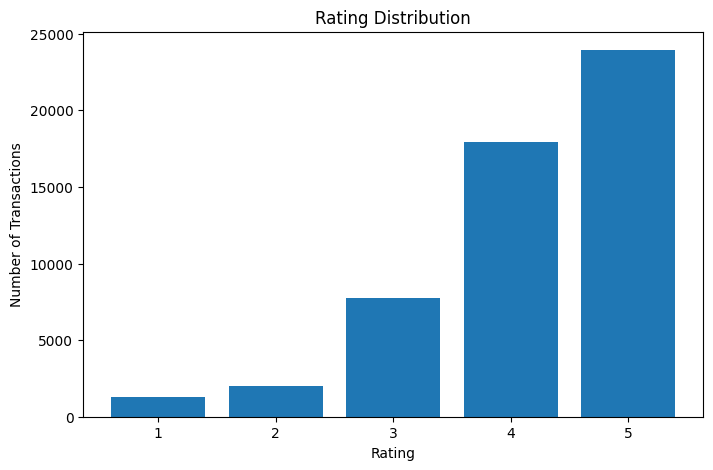

In [168]:
import matplotlib.pyplot as plt

rating_counts = transaction_df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values)

plt.xlabel("Rating")
plt.ylabel("Number of Transactions")
plt.title("Rating Distribution")

plt.xticks([1, 2, 3, 4, 5])
plt.show()

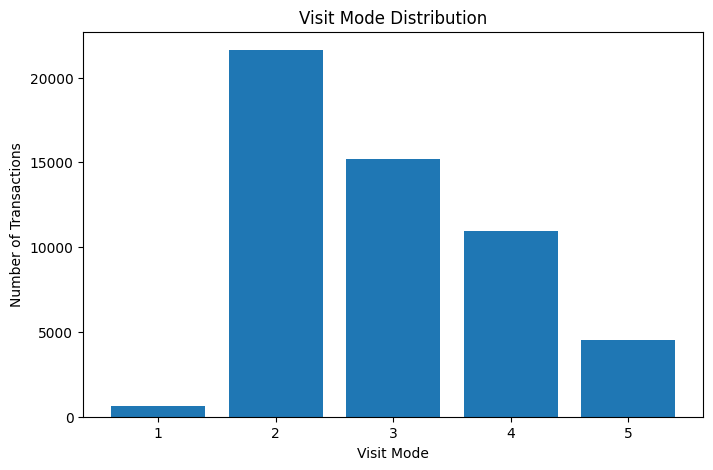

In [169]:
mode_counts = transaction_df["VisitMode"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(mode_counts.index, mode_counts.values)

plt.xlabel("Visit Mode")
plt.ylabel("Number of Transactions")
plt.title("Visit Mode Distribution")

plt.xticks(mode_counts.index)
plt.show()

In [170]:
print(mode_counts)

print("\nPercentages:")
print((mode_counts / len(transaction_df) * 100).round(2))

VisitMode
1      623
2    21620
3    15217
4    10945
5     4525
Name: count, dtype: int64

Percentages:
VisitMode
1     1.18
2    40.85
3    28.75
4    20.68
5     8.55
Name: count, dtype: float64


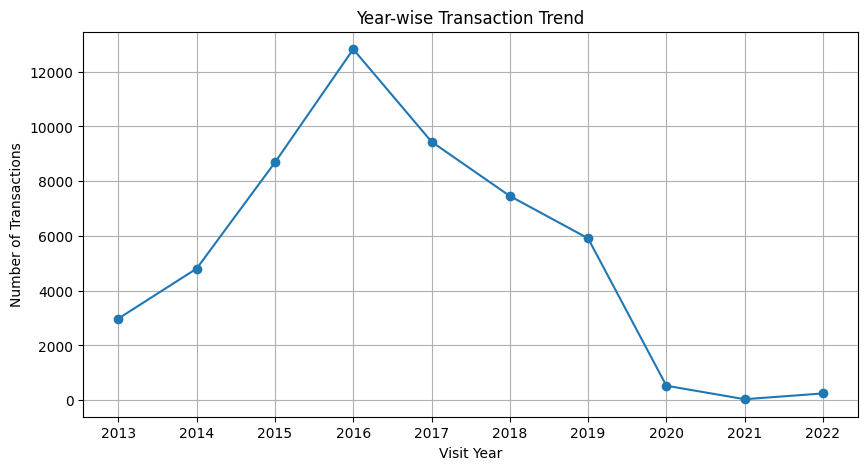

In [171]:
year_counts = (
    transaction_df["VisitYear"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(year_counts.index, year_counts.values, marker="o")

plt.xlabel("Visit Year")
plt.ylabel("Number of Transactions")
plt.title("Year-wise Transaction Trend")
plt.xticks(year_counts.index)
plt.grid(True)
plt.show()

In [172]:
print(year_counts)

print("\nPercentages:")
print((year_counts / len(transaction_df) * 100).round(2))

VisitYear
2013     2983
2014     4808
2015     8687
2016    12823
2017     9444
2018     7461
2019     5913
2020      529
2021       35
2022      247
Name: count, dtype: int64

Percentages:
VisitYear
2013     5.64
2014     9.08
2015    16.41
2016    24.23
2017    17.84
2018    14.10
2019    11.17
2020     1.00
2021     0.07
2022     0.47
Name: count, dtype: float64


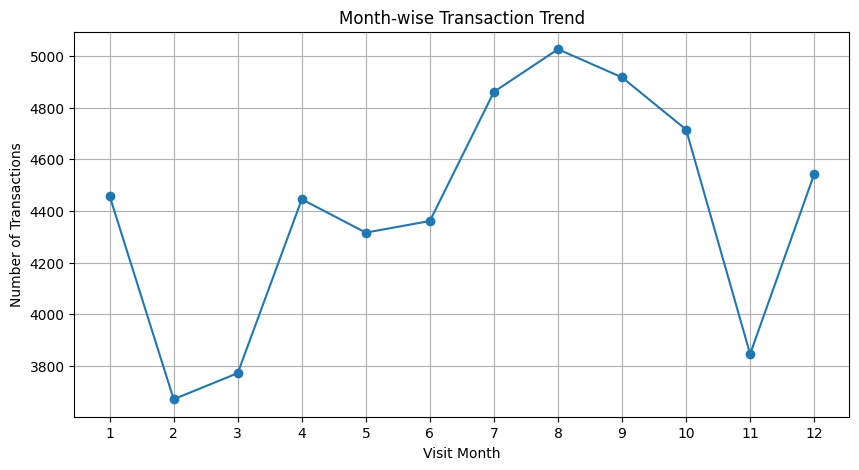

In [173]:
month_counts = (
    transaction_df["VisitMonth"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(month_counts.index, month_counts.values, marker="o")

plt.xlabel("Visit Month")
plt.ylabel("Number of Transactions")
plt.title("Month-wise Transaction Trend")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [174]:
print(month_counts)

print("\nPercentages:")
print((month_counts / len(transaction_df) * 100).round(2))

VisitMonth
1     4458
2     3671
3     3772
4     4445
5     4316
6     4361
7     4861
8     5026
9     4917
10    4715
11    3846
12    4542
Name: count, dtype: int64

Percentages:
VisitMonth
1     8.42
2     6.94
3     7.13
4     8.40
5     8.15
6     8.24
7     9.18
8     9.50
9     9.29
10    8.91
11    7.27
12    8.58
Name: count, dtype: float64


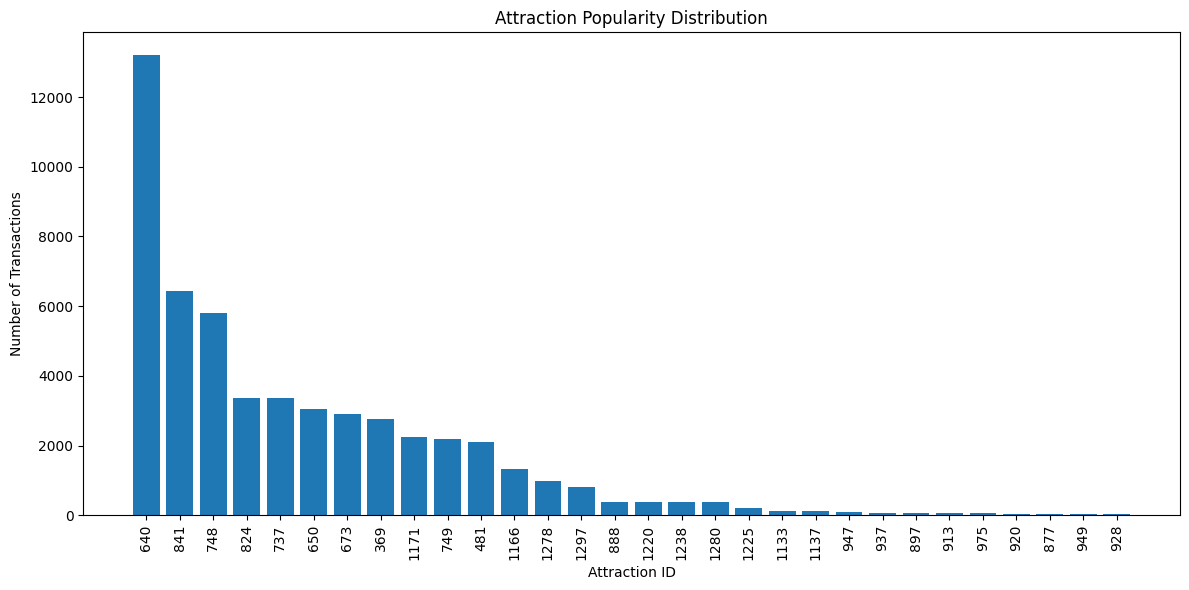

In [175]:
attraction_counts = (
    transaction_df["AttractionId"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(
    attraction_counts.index.astype(str),
    attraction_counts.values
)

plt.xlabel("Attraction ID")
plt.ylabel("Number of Transactions")
plt.title("Attraction Popularity Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [176]:
print("Most visited attraction:")
print(attraction_counts.head(10))

print("\nLeast visited attractions:")
print(attraction_counts.tail(10))

Most visited attraction:
AttractionId
640     13198
841      6429
748      5815
824      3359
737      3352
650      3044
673      2914
369      2765
1171     2235
749      2190
Name: count, dtype: int64

Least visited attractions:
AttractionId
1137    130
947      83
937      64
897      55
913      54
975      53
920      44
877      36
949      31
928      28
Name: count, dtype: int64


In [177]:
attraction_analysis = (
    transaction_df
    .groupby("AttractionId")
    .agg(
        TransactionCount=("Rating", "count"),
        AverageRating=("Rating", "mean")
    )
    .sort_values("AverageRating", ascending=False)
)

print(attraction_analysis)

              TransactionCount  AverageRating
AttractionId                                 
947                         83       4.698795
841                       6429       4.646601
888                        381       4.611549
928                         28       4.571429
1133                       135       4.503704
920                         44       4.318182
481                       2104       4.275665
640                      13198       4.267086
1278                       978       4.256646
824                       3359       4.219411
975                         53       4.207547
737                       3352       4.194809
1220                       377       4.180371
748                       5815       4.157524
1238                       377       4.124668
913                         54       4.092593
1171                      2235       4.079195
949                         31       4.032258
877                         36       4.027778
650                       3044    

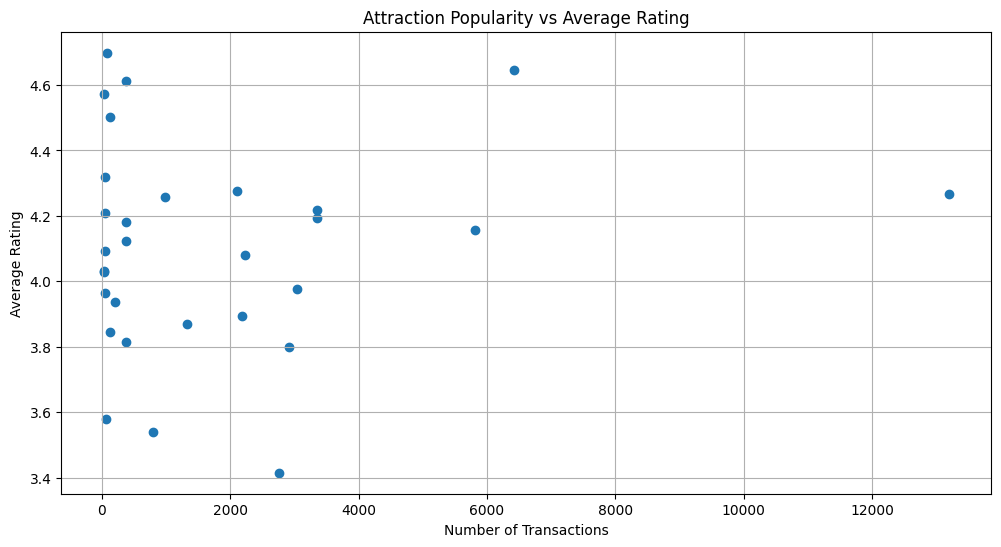

In [178]:
plt.figure(figsize=(12, 6))

plt.scatter(
    attraction_analysis["TransactionCount"],
    attraction_analysis["AverageRating"]
)

plt.xlabel("Number of Transactions")
plt.ylabel("Average Rating")
plt.title("Attraction Popularity vs Average Rating")
plt.grid(True)
plt.show()

In [179]:
print(mode_df)

   VisitModeId VisitMode
0            0         -
1            1  Business
2            2   Couples
3            3    Family
4            4   Friends
5            5      Solo


In [180]:
mode_rating = (
    transaction_df
    .groupby("VisitMode")["Rating"]
    .agg(
        TransactionCount="count",
        AverageRating="mean"
    )
)

mode_rating["VisitModeName"] = mode_rating.index.map(
    mode_df.set_index("VisitModeId")["VisitMode"]
)

mode_rating = mode_rating[
    ["VisitModeName", "TransactionCount", "AverageRating"]
]

print(mode_rating)

          VisitModeName  TransactionCount  AverageRating
VisitMode                                               
1              Business               623       4.313002
2               Couples             21620       4.116559
3                Family             15217       4.218703
4               Friends             10945       4.174052
5                  Solo              4525       4.088177


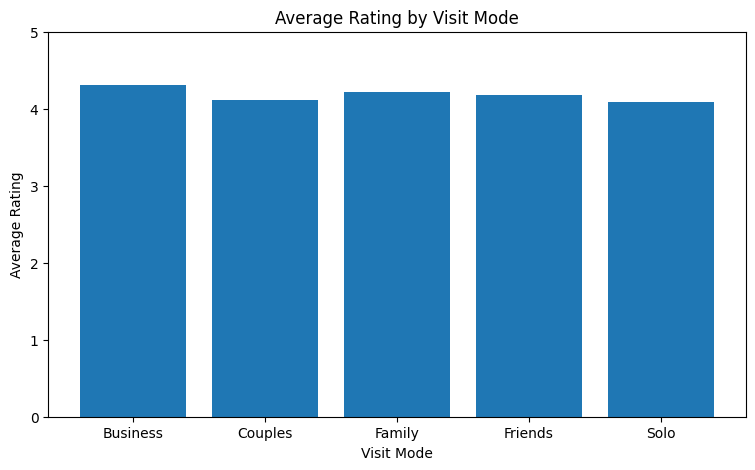

In [181]:
plt.figure(figsize=(9, 5))

plt.bar(
    mode_rating["VisitModeName"],
    mode_rating["AverageRating"]
)

plt.xlabel("Visit Mode")
plt.ylabel("Average Rating")
plt.title("Average Rating by Visit Mode")
plt.ylim(0, 5)
plt.show()

In [182]:
mode_attraction = (
    transaction_df
    .groupby(["VisitMode", "AttractionId"])
    .size()
    .reset_index(name="TransactionCount")
)

mode_attraction["VisitModeName"] = mode_attraction["VisitMode"].map(
    mode_df.set_index("VisitModeId")["VisitMode"]
)

print(mode_attraction.head(20))

    VisitMode  AttractionId  TransactionCount VisitModeName
0           1           369                37      Business
1           1           481                66      Business
2           1           640                59      Business
3           1           650                33      Business
4           1           673                15      Business
5           1           737                29      Business
6           1           748                39      Business
7           1           749                17      Business
8           1           824                48      Business
9           1           841                21      Business
10          1           877                 1      Business
11          1           888                19      Business
12          1           897                 1      Business
13          1           913                 1      Business
14          1           920                 1      Business
15          1           937             

In [183]:
top_mode_attractions = (
    mode_attraction
    .sort_values(
        ["VisitMode", "TransactionCount"],
        ascending=[True, False]
    )
    .groupby("VisitMode")
    .head(5)
)

print(top_mode_attractions)

     VisitMode  AttractionId  TransactionCount VisitModeName
21           1          1171                87      Business
1            1           481                66      Business
2            1           640                59      Business
20           1          1166                53      Business
8            1           824                48      Business
30           2           640              6383       Couples
34           2           748              2782       Couples
33           2           737              1499       Couples
36           2           824              1491       Couples
32           2           673              1434       Couples
67           3           841              3942        Family
60           3           640              3113        Family
64           3           748              1207        Family
63           3           737               855        Family
66           3           824               851        Family
90           4          

In [184]:
user_transaction_location = transaction_df.merge(
    user_df[["UserId", "CityId"]],
    on="UserId",
    how="left"
).merge(
    item_df[["AttractionId", "AttractionCityId"]],
    on="AttractionId",
    how="left"
)

print("Total transactions:", len(user_transaction_location))

print(
    "User City = Attraction City:",
    (
        user_transaction_location["CityId"]
        == user_transaction_location["AttractionCityId"]
    ).sum()
)

print(
    "User City != Attraction City:",
    (
        user_transaction_location["CityId"]
        != user_transaction_location["AttractionCityId"]
    ).sum()
)

print(
    "Missing User City:",
    user_transaction_location["CityId"].isna().sum()
)

Total transactions: 52930
User City = Attraction City: 2
User City != Attraction City: 52928
Missing User City: 8


In [185]:
user_transaction_country = transaction_df.merge(
    user_df[["UserId", "CountryId"]],
    on="UserId",
    how="left"
).merge(
    item_df[["AttractionId", "AttractionCityId"]],
    on="AttractionId",
    how="left"
).merge(
    city_df[["CityId", "CountryId"]],
    left_on="AttractionCityId",
    right_on="CityId",
    how="left",
    suffixes=("_user", "_attraction_city")
)

same_country = (
    user_transaction_country["CountryId_user"]
    == user_transaction_country["CountryId_attraction_city"]
)

print("Total transactions:", len(user_transaction_country))
print("Same Country:", same_country.sum())
print("Different Country:", (~same_country).sum())
print("Missing user country:",
      user_transaction_country["CountryId_user"].isna().sum())
print("Missing attraction country:",
      user_transaction_country["CountryId_attraction_city"].isna().sum())

Total transactions: 52930
Same Country: 2
Different Country: 52928
Missing user country: 0
Missing attraction country: 0


In [186]:
attraction_user_stats = (
    transaction_df
    .groupby("AttractionId")["UserId"]
    .nunique()
    .reset_index(name="UniqueUsers")
    .sort_values("UniqueUsers", ascending=False)
)

print(attraction_user_stats)

    AttractionId  UniqueUsers
2            640        11487
9            841         5605
6            748         5415
8            824         3183
5            737         3156
3            650         2808
4            673         2754
0            369         2571
7            749         2152
1            481         1992
23          1171          855
22          1166          521
27          1278          477
29          1297          472
11           888          381
28          1280          246
24          1220          224
26          1238          169
25          1225          162
20          1133          119
17           947           83
21          1137           82
16           937           64
12           897           54
19           975           53
13           913           52
14           920           43
10           877           36
18           949           31
15           928           28


In [187]:
user_attraction_stats = (
    transaction_df
    .groupby("UserId")["AttractionId"]
    .nunique()
    .reset_index(name="UniqueAttractions")
)

print(user_attraction_stats["UniqueAttractions"].value_counts().sort_index())

UniqueAttractions
1     25596
2      5474
3      1603
4       551
5       187
6        71
7        36
8         6
9         3
10        3
Name: count, dtype: int64


In [188]:
print("\nUser attraction diversity statistics:")
print(user_attraction_stats["UniqueAttractions"].describe())


User attraction diversity statistics:
count    33530.000000
mean         1.350283
std          0.763066
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: UniqueAttractions, dtype: float64


In [189]:
print(
    "\nUsers with only 1 unique attraction:",
    (user_attraction_stats["UniqueAttractions"] == 1).sum()
)

print(
    "Users with more than 1 unique attraction:",
    (user_attraction_stats["UniqueAttractions"] > 1).sum()
)

print(
    "Maximum unique attractions for one user:",
    user_attraction_stats["UniqueAttractions"].max()
)


Users with only 1 unique attraction: 25596
Users with more than 1 unique attraction: 7934
Maximum unique attractions for one user: 10


In [190]:
unique_user_attraction = (
    transaction_df[["UserId", "AttractionId"]]
    .drop_duplicates()
)

print("Unique User-Attraction pairs:",
      len(unique_user_attraction))

Unique User-Attraction pairs: 45275


In [191]:
total_possible = (
    transaction_df["UserId"].nunique()
    * transaction_df["AttractionId"].nunique()
)

print("Total possible User-Attraction pairs:",
      total_possible)

Total possible User-Attraction pairs: 1005900


In [192]:
sparsity = (
    1 - len(unique_user_attraction) / total_possible
) * 100

density = (
    len(unique_user_attraction) / total_possible
) * 100

print("Interaction Density:", round(density, 4), "%")
print("Interaction Sparsity:", round(sparsity, 4), "%")

Interaction Density: 4.5009 %
Interaction Sparsity: 95.4991 %


In [193]:
print(
    "User × Attraction matrix:",
    transaction_df["UserId"].nunique(),
    "×",
    transaction_df["AttractionId"].nunique()
)

User × Attraction matrix: 33530 × 30


In [194]:
user_interaction_counts = (
    transaction_df
    .groupby("UserId")
    .size()
    .reset_index(name="InteractionCount")
)

user_interaction_counts["UserType"] = pd.cut(
    user_interaction_counts["InteractionCount"],
    bins=[0, 1, 3, 5, float("inf")],
    labels=[
        "1 Interaction",
        "2-3 Interactions",
        "4-5 Interactions",
        "6+ Interactions"
    ]
)

print(
    user_interaction_counts["UserType"]
    .value_counts()
    .sort_index()
)

print("\nPercentages:")
print(
    (
        user_interaction_counts["UserType"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
)

UserType
1 Interaction       22912
2-3 Interactions     8739
4-5 Interactions     1328
6+ Interactions       551
Name: count, dtype: int64

Percentages:
UserType
1 Interaction       68.33
2-3 Interactions    26.06
4-5 Interactions     3.96
6+ Interactions      1.64
Name: proportion, dtype: float64


In [195]:
pair_stats = (
    transaction_df
    .groupby(["UserId", "AttractionId"])
    .agg(
        InteractionCount=("Rating", "count"),
        AverageRating=("Rating", "mean"),
        RatingStd=("Rating", "std")
    )
    .reset_index()
)

print("Total unique User-Attraction pairs:", len(pair_stats))

print(
    "Repeated User-Attraction pairs:",
    (pair_stats["InteractionCount"] > 1).sum()
)

print(
    "Single-interaction pairs:",
    (pair_stats["InteractionCount"] == 1).sum()
)

print("\nInteraction count distribution:")
print(
    pair_stats["InteractionCount"]
    .value_counts()
    .sort_index()
)

Total unique User-Attraction pairs: 45275
Repeated User-Attraction pairs: 5044
Single-interaction pairs: 40231

Interaction count distribution:
InteractionCount
1     40231
2      3885
3       622
4       253
5       122
6        56
7        29
8        22
9        19
10        5
11        9
12        3
13        3
14        2
15        5
16        1
18        1
20        1
22        3
24        1
35        1
49        1
Name: count, dtype: int64


In [196]:
print("=" * 60)
print("FINAL EDA SUMMARY")
print("=" * 60)

print("\nDATASET")
print("Users:", transaction_df["UserId"].nunique())
print("Attractions:", transaction_df["AttractionId"].nunique())
print("Transactions:", len(transaction_df))

print("\nRATING")
print("Average Rating:", round(transaction_df["Rating"].mean(), 4))

print("\nUSER ACTIVITY")
print("Unique users with transactions:",
      transaction_df["UserId"].nunique())

print("Users with 1 transaction:",
      (user_interaction_counts["InteractionCount"] == 1).sum())

print("Maximum transactions by user:",
      user_interaction_counts["InteractionCount"].max())

print("\nUSER-ATTRACTION")
print("Unique pairs:", len(pair_stats))
print("Repeated pairs:",
      (pair_stats["InteractionCount"] > 1).sum())

print("Maximum interactions per pair:",
      pair_stats["InteractionCount"].max())

print("\nSPARSITY")
print("Possible pairs:", total_possible)
print("Observed pairs:", len(unique_user_attraction))
print("Density:", round(density, 4), "%")
print("Sparsity:", round(sparsity, 4), "%")

print("\nTIME")
print("Earliest:", transaction_df["VisitYear"].min())
print("Latest:", transaction_df["VisitYear"].max())

print("\nLOCATION")
print("Same country transactions:", same_country.sum())
print("Different country transactions:", (~same_country).sum())

FINAL EDA SUMMARY

DATASET
Users: 33530
Attractions: 30
Transactions: 52930

RATING
Average Rating: 4.1577

USER ACTIVITY
Unique users with transactions: 33530
Users with 1 transaction: 22912
Maximum transactions by user: 59

USER-ATTRACTION
Unique pairs: 45275
Repeated pairs: 5044
Maximum interactions per pair: 49

SPARSITY
Possible pairs: 1005900
Observed pairs: 45275
Density: 4.5009 %
Sparsity: 95.4991 %

TIME
Earliest: 2013
Latest: 2022

LOCATION
Same country transactions: 2
Different country transactions: 52928


# Feature Engineering

In [197]:
user_attraction_features = (
    transaction_df
    .groupby(["UserId", "AttractionId"])
    .agg(
        InteractionCount=("Rating", "count"),
        AverageRating=("Rating", "mean"),
        RatingStd=("Rating", "std"),
        FirstVisitYear=("VisitYear", "min"),
        LastVisitYear=("VisitYear", "max"),
        UniqueVisitMonths=("VisitMonth", "nunique"),
        UniqueVisitModes=("VisitMode", "nunique")
    )
    .reset_index()
)

print("Shape:", user_attraction_features.shape)

print("\nFirst 10 rows:")
print(user_attraction_features.head(10))

Shape: (45275, 9)

First 10 rows:
   UserId  AttractionId  InteractionCount  AverageRating  RatingStd  \
0      14           640                 1           4.00        NaN   
1      14           748                 2           5.00   0.000000   
2      16           481                 2           5.00   0.000000   
3      16           640                 4           4.25   0.957427   
4      16           748                 1           5.00        NaN   
5      16           824                 1           5.00        NaN   
6      16           841                 2           5.00   0.000000   
7      20           841                 1           4.00        NaN   
8      23           748                 1           5.00        NaN   
9      25           888                 1           5.00        NaN   

   FirstVisitYear  LastVisitYear  UniqueVisitMonths  UniqueVisitModes  
0            2018           2018                  1                 1  
1            2018           2018        

In [198]:
print("\nMissing values:")
print(user_attraction_features.isna().sum())


Missing values:
UserId                   0
AttractionId             0
InteractionCount         0
AverageRating            0
RatingStd            40231
FirstVisitYear           0
LastVisitYear            0
UniqueVisitMonths        0
UniqueVisitModes         0
dtype: int64


In [199]:
user_features = (
    transaction_df
    .groupby("UserId")
    .agg(
        TotalInteractions=("Rating", "count"),
        AverageRating=("Rating", "mean"),
        UniqueAttractions=("AttractionId", "nunique"),
        UniqueVisitModes=("VisitMode", "nunique"),
        UniqueVisitYears=("VisitYear", "nunique"),
        UniqueVisitMonths=("VisitMonth", "nunique")
    )
    .reset_index()
)

print("Shape:", user_features.shape)

print("\nFirst 10 rows:")
print(user_features.head(10))

Shape: (33530, 7)

First 10 rows:
   UserId  TotalInteractions  AverageRating  UniqueAttractions  \
0      14                  3       4.666667                  2   
1      16                 10       4.700000                  5   
2      20                  1       4.000000                  1   
3      23                  1       5.000000                  1   
4      25                  1       5.000000                  1   
5      26                  1       5.000000                  1   
6      27                  1       4.000000                  1   
7      28                  1       5.000000                  1   
8      29                  1       5.000000                  1   
9      32                  1       4.000000                  1   

   UniqueVisitModes  UniqueVisitYears  UniqueVisitMonths  
0                 1                 1                  1  
1                 4                 4                  5  
2                 1                 1                  1  
3  

In [200]:
print("\nMissing values:")
print(user_features.isna().sum())


Missing values:
UserId               0
TotalInteractions    0
AverageRating        0
UniqueAttractions    0
UniqueVisitModes     0
UniqueVisitYears     0
UniqueVisitMonths    0
dtype: int64


In [201]:
attraction_features = (
    transaction_df
    .groupby("AttractionId")
    .agg(
        TotalInteractions=("Rating", "count"),
        AverageRating=("Rating", "mean"),
        UniqueUsers=("UserId", "nunique"),
        UniqueVisitModes=("VisitMode", "nunique"),
        UniqueVisitYears=("VisitYear", "nunique"),
        UniqueVisitMonths=("VisitMonth", "nunique")
    )
    .reset_index()
)

print("Shape:", attraction_features.shape)

print("\nFirst 10 rows:")
print(attraction_features.head(10))

Shape: (30, 7)

First 10 rows:
   AttractionId  TotalInteractions  AverageRating  UniqueUsers  \
0           369               2765       3.415190         2571   
1           481               2104       4.275665         1992   
2           640              13198       4.267086        11487   
3           650               3044       3.976347         2808   
4           673               2914       3.800618         2754   
5           737               3352       4.194809         3156   
6           748               5815       4.157524         5415   
7           749               2190       3.895434         2152   
8           824               3359       4.219411         3183   
9           841               6429       4.646601         5605   

   UniqueVisitModes  UniqueVisitYears  UniqueVisitMonths  
0                 5                10                 12  
1                 5                 9                 12  
2                 5                10                 12  
3     

In [202]:
print("\nMissing values:")
print(attraction_features.isna().sum())


Missing values:
AttractionId         0
TotalInteractions    0
AverageRating        0
UniqueUsers          0
UniqueVisitModes     0
UniqueVisitYears     0
UniqueVisitMonths    0
dtype: int64


In [203]:
transaction_df["VisitDate"] = pd.to_datetime(
    transaction_df["VisitYear"].astype(str) + "-" +
    transaction_df["VisitMonth"].astype(str) + "-01"
)

print(transaction_df[[
    "VisitYear",
    "VisitMonth",
    "VisitDate"
]].head(10))

print("\nMissing VisitDate:")
print(transaction_df["VisitDate"].isna().sum())

   VisitYear  VisitMonth  VisitDate
0       2022          10 2022-10-01
1       2022          10 2022-10-01
2       2022          10 2022-10-01
3       2022          10 2022-10-01
4       2022          10 2022-10-01
5       2022          10 2022-10-01
6       2022           9 2022-09-01
7       2022          10 2022-10-01
8       2022           9 2022-09-01
9       2022           9 2022-09-01

Missing VisitDate:
0


In [204]:
transaction_df["VisitQuarter"] = transaction_df["VisitDate"].dt.quarter

transaction_df["VisitSeason"] = transaction_df["VisitMonth"].apply(
    lambda month: (
        "Winter" if month in [12, 1, 2]
        else "Spring" if month in [3, 4, 5]
        else "Summer" if month in [6, 7, 8]
        else "Autumn"
    )
)

print(transaction_df[[
    "VisitYear",
    "VisitMonth",
    "VisitQuarter",
    "VisitSeason"
]].head(15))

    VisitYear  VisitMonth  VisitQuarter VisitSeason
0        2022          10             4      Autumn
1        2022          10             4      Autumn
2        2022          10             4      Autumn
3        2022          10             4      Autumn
4        2022          10             4      Autumn
5        2022          10             4      Autumn
6        2022           9             3      Autumn
7        2022          10             4      Autumn
8        2022           9             3      Autumn
9        2022           9             3      Autumn
10       2022           9             3      Autumn
11       2022           9             3      Autumn
12       2022           9             3      Autumn
13       2022           8             3      Summer
14       2022           9             3      Autumn


In [205]:
print("\nQuarter distribution:")
print(transaction_df["VisitQuarter"].value_counts().sort_index())

print("\nSeason distribution:")
print(transaction_df["VisitSeason"].value_counts())


Quarter distribution:
VisitQuarter
1    11901
2    13122
3    14804
4    13103
Name: count, dtype: int64

Season distribution:
VisitSeason
Summer    14248
Autumn    13478
Winter    12671
Spring    12533
Name: count, dtype: int64


In [206]:
transaction_features = transaction_df.merge(
    user_attraction_features,
    on=["UserId", "AttractionId"],
    how="left"
)

print("Shape:", transaction_features.shape)

print("\nFirst 5 rows:")
print(transaction_features.head())

Shape: (52930, 17)

First 5 rows:
   TransactionId  UserId  VisitYear  VisitMonth  VisitMode  AttractionId  \
0              3   70456       2022          10          2           640   
1              8    7567       2022          10          4           640   
2              9   79069       2022          10          3           640   
3             10   31019       2022          10          3           640   
4             15   43611       2022          10          2           640   

   Rating  VisitDate  VisitQuarter VisitSeason  InteractionCount  \
0       5 2022-10-01             4      Autumn                 1   
1       5 2022-10-01             4      Autumn                 1   
2       5 2022-10-01             4      Autumn                 1   
3       3 2022-10-01             4      Autumn                 2   
4       3 2022-10-01             4      Autumn                 1   

   AverageRating  RatingStd  FirstVisitYear  LastVisitYear  UniqueVisitMonths  \
0            5.0   

In [207]:
print("\nMissing values:")
print(transaction_features.isna().sum())


Missing values:
TransactionId            0
UserId                   0
VisitYear                0
VisitMonth               0
VisitMode                0
AttractionId             0
Rating                   0
VisitDate                0
VisitQuarter             0
VisitSeason              0
InteractionCount         0
AverageRating            0
RatingStd            40231
FirstVisitYear           0
LastVisitYear            0
UniqueVisitMonths        0
UniqueVisitModes         0
dtype: int64


In [208]:
transaction_features = transaction_features.merge(
    user_features,
    on="UserId",
    how="left",
    suffixes=("", "_User")
)

print("Shape:", transaction_features.shape)

print("\nFirst 5 rows:")
print(transaction_features.head())

Shape: (52930, 23)

First 5 rows:
   TransactionId  UserId  VisitYear  VisitMonth  VisitMode  AttractionId  \
0              3   70456       2022          10          2           640   
1              8    7567       2022          10          4           640   
2              9   79069       2022          10          3           640   
3             10   31019       2022          10          3           640   
4             15   43611       2022          10          2           640   

   Rating  VisitDate  VisitQuarter VisitSeason  ...  FirstVisitYear  \
0       5 2022-10-01             4      Autumn  ...            2022   
1       5 2022-10-01             4      Autumn  ...            2022   
2       5 2022-10-01             4      Autumn  ...            2022   
3       3 2022-10-01             4      Autumn  ...            2022   
4       3 2022-10-01             4      Autumn  ...            2022   

   LastVisitYear  UniqueVisitMonths  UniqueVisitModes  TotalInteractions  \
0     

In [209]:
print("\nMissing values:")
print(transaction_features.isna().sum())


Missing values:
TransactionId                 0
UserId                        0
VisitYear                     0
VisitMonth                    0
VisitMode                     0
AttractionId                  0
Rating                        0
VisitDate                     0
VisitQuarter                  0
VisitSeason                   0
InteractionCount              0
AverageRating                 0
RatingStd                 40231
FirstVisitYear                0
LastVisitYear                 0
UniqueVisitMonths             0
UniqueVisitModes              0
TotalInteractions             0
AverageRating_User            0
UniqueAttractions             0
UniqueVisitModes_User         0
UniqueVisitYears              0
UniqueVisitMonths_User        0
dtype: int64


In [210]:
transaction_features = transaction_features.merge(
    attraction_features,
    on="AttractionId",
    how="left",
    suffixes=("", "_Attraction")
)

print("Shape:", transaction_features.shape)

print("\nFirst 5 rows:")
print(transaction_features.head())

Shape: (52930, 29)

First 5 rows:
   TransactionId  UserId  VisitYear  VisitMonth  VisitMode  AttractionId  \
0              3   70456       2022          10          2           640   
1              8    7567       2022          10          4           640   
2              9   79069       2022          10          3           640   
3             10   31019       2022          10          3           640   
4             15   43611       2022          10          2           640   

   Rating  VisitDate  VisitQuarter VisitSeason  ...  UniqueAttractions  \
0       5 2022-10-01             4      Autumn  ...                  1   
1       5 2022-10-01             4      Autumn  ...                  1   
2       5 2022-10-01             4      Autumn  ...                  1   
3       3 2022-10-01             4      Autumn  ...                  1   
4       3 2022-10-01             4      Autumn  ...                  3   

   UniqueVisitModes_User  UniqueVisitYears  UniqueVisitMonths_Us

In [211]:
print("\nMissing values:")
print(transaction_features.isna().sum())


Missing values:
TransactionId                       0
UserId                              0
VisitYear                           0
VisitMonth                          0
VisitMode                           0
AttractionId                        0
Rating                              0
VisitDate                           0
VisitQuarter                        0
VisitSeason                         0
InteractionCount                    0
AverageRating                       0
RatingStd                       40231
FirstVisitYear                      0
LastVisitYear                       0
UniqueVisitMonths                   0
UniqueVisitModes                    0
TotalInteractions                   0
AverageRating_User                  0
UniqueAttractions                   0
UniqueVisitModes_User               0
UniqueVisitYears                    0
UniqueVisitMonths_User              0
TotalInteractions_Attraction        0
AverageRating_Attraction            0
UniqueUsers                      

In [212]:
print("Total columns:", len(transaction_features.columns))

print("\nAll columns:")
for i, col in enumerate(transaction_features.columns, start=1):
    print(i, col)

Total columns: 29

All columns:
1 TransactionId
2 UserId
3 VisitYear
4 VisitMonth
5 VisitMode
6 AttractionId
7 Rating
8 VisitDate
9 VisitQuarter
10 VisitSeason
11 InteractionCount
12 AverageRating
13 RatingStd
14 FirstVisitYear
15 LastVisitYear
16 UniqueVisitMonths
17 UniqueVisitModes
18 TotalInteractions
19 AverageRating_User
20 UniqueAttractions
21 UniqueVisitModes_User
22 UniqueVisitYears
23 UniqueVisitMonths_User
24 TotalInteractions_Attraction
25 AverageRating_Attraction
26 UniqueUsers
27 UniqueVisitModes_Attraction
28 UniqueVisitYears_Attraction
29 UniqueVisitMonths_Attraction


In [213]:
transaction_features["RatingDeviationFromUser"] = (
    transaction_features["Rating"]
    - transaction_features["AverageRating_User"]
)

transaction_features["RatingDeviationFromAttraction"] = (
    transaction_features["Rating"]
    - transaction_features["AverageRating_Attraction"]
)

print(
    transaction_features[
        [
            "UserId",
            "AttractionId",
            "Rating",
            "AverageRating_User",
            "AverageRating_Attraction",
            "RatingDeviationFromUser",
            "RatingDeviationFromAttraction"
        ]
    ].head(10)
)

   UserId  AttractionId  Rating  AverageRating_User  AverageRating_Attraction  \
0   70456           640       5            5.000000                  4.267086   
1    7567           640       5            5.000000                  4.267086   
2   79069           640       5            5.000000                  4.267086   
3   31019           640       3            3.000000                  4.267086   
4   43611           640       3            3.000000                  4.267086   
5   43471           640       5            5.000000                  4.267086   
6   76492           640       4            4.000000                  4.267086   
7   20977           640       5            5.000000                  4.267086   
8   18655           640       3            3.000000                  4.267086   
9   62907           640       5            3.928571                  4.267086   

   RatingDeviationFromUser  RatingDeviationFromAttraction  
0                 0.000000                      

In [214]:
print("\nMissing values:")
print(
    transaction_features[
        [
            "RatingDeviationFromUser",
            "RatingDeviationFromAttraction"
        ]
    ].isna().sum()
)


Missing values:
RatingDeviationFromUser          0
RatingDeviationFromAttraction    0
dtype: int64


In [215]:
transaction_features["AttractionsPerInteraction"] = (
    transaction_features["UniqueAttractions"]
    / transaction_features["TotalInteractions"]
)

print(
    transaction_features[
        [
            "UserId",
            "TotalInteractions",
            "UniqueAttractions",
            "AttractionsPerInteraction"
        ]
    ].head(10)
)

   UserId  TotalInteractions  UniqueAttractions  AttractionsPerInteraction
0   70456                  1                  1                   1.000000
1    7567                  1                  1                   1.000000
2   79069                  1                  1                   1.000000
3   31019                  2                  1                   0.500000
4   43611                  3                  3                   1.000000
5   43471                  2                  1                   0.500000
6   76492                  2                  1                   0.500000
7   20977                  1                  1                   1.000000
8   18655                  1                  1                   1.000000
9   62907                 14                  6                   0.428571


In [216]:
print("\nMissing values:")
print(transaction_features["AttractionsPerInteraction"].isna().sum())

print("\nFeature statistics:")
print(transaction_features["AttractionsPerInteraction"].describe())


Missing values:
0

Feature statistics:
count    52930.000000
mean         0.855375
std          0.242635
min          0.045455
25%          0.666667
50%          1.000000
75%          1.000000
max          1.000000
Name: AttractionsPerInteraction, dtype: float64


In [217]:
print("Shape:", transaction_features.shape)

print("\nMissing values:")
print(transaction_features.isna().sum())

print("\nData types:")
print(transaction_features.dtypes)

Shape: (52930, 32)

Missing values:
TransactionId                        0
UserId                               0
VisitYear                            0
VisitMonth                           0
VisitMode                            0
AttractionId                         0
Rating                               0
VisitDate                            0
VisitQuarter                         0
VisitSeason                          0
InteractionCount                     0
AverageRating                        0
RatingStd                        40231
FirstVisitYear                       0
LastVisitYear                        0
UniqueVisitMonths                    0
UniqueVisitModes                     0
TotalInteractions                    0
AverageRating_User                   0
UniqueAttractions                    0
UniqueVisitModes_User                0
UniqueVisitYears                     0
UniqueVisitMonths_User               0
TotalInteractions_Attraction         0
AverageRating_Attraction    

In [218]:
transaction_features["RatingStd"] = (
    transaction_features["RatingStd"].fillna(0)
)

print("Missing RatingStd:")
print(transaction_features["RatingStd"].isna().sum())

print("\nRatingStd statistics:")
print(transaction_features["RatingStd"].describe())

Missing RatingStd:
0

RatingStd statistics:
count    52930.000000
mean         0.098967
std          0.312989
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.828427
Name: RatingStd, dtype: float64


In [219]:
print(transaction_features["VisitSeason"].value_counts())

print("\nUnique seasons:")
print(transaction_features["VisitSeason"].unique())

VisitSeason
Summer    14248
Autumn    13478
Winter    12671
Spring    12533
Name: count, dtype: int64

Unique seasons:
['Autumn' 'Summer' 'Spring' 'Winter']


In [220]:
season_encoded = pd.get_dummies(
    transaction_features["VisitSeason"],
    prefix="Season",
    dtype=int
)

transaction_features = pd.concat(
    [transaction_features, season_encoded],
    axis=1
)

print("New season columns:")
print(season_encoded.head(10))

print("\nSeason columns:")
print(season_encoded.columns.tolist())

New season columns:
   Season_Autumn  Season_Spring  Season_Summer  Season_Winter
0              1              0              0              0
1              1              0              0              0
2              1              0              0              0
3              1              0              0              0
4              1              0              0              0
5              1              0              0              0
6              1              0              0              0
7              1              0              0              0
8              1              0              0              0
9              1              0              0              0

Season columns:
['Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']


In [221]:
print("\nSeason encoding check:")
print(season_encoded.sum())

print("\nShape:", transaction_features.shape)


Season encoding check:
Season_Autumn    13478
Season_Spring    12533
Season_Summer    14248
Season_Winter    12671
dtype: int64

Shape: (52930, 36)


In [222]:
print(transaction_features["VisitMode"].value_counts().sort_index())

print("\nUnique VisitModes:")
print(sorted(transaction_features["VisitMode"].unique()))

VisitMode
1      623
2    21620
3    15217
4    10945
5     4525
Name: count, dtype: int64

Unique VisitModes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [223]:
mode_encoded = pd.get_dummies(
    transaction_features["VisitMode"],
    prefix="VisitMode",
    dtype=int
)

transaction_features = pd.concat(
    [transaction_features, mode_encoded],
    axis=1
)

print("New VisitMode columns:")
print(mode_encoded.head(10))

print("\nVisitMode columns:")
print(mode_encoded.columns.tolist())

New VisitMode columns:
   VisitMode_1  VisitMode_2  VisitMode_3  VisitMode_4  VisitMode_5
0            0            1            0            0            0
1            0            0            0            1            0
2            0            0            1            0            0
3            0            0            1            0            0
4            0            1            0            0            0
5            0            0            0            1            0
6            0            1            0            0            0
7            0            0            0            1            0
8            0            1            0            0            0
9            0            1            0            0            0

VisitMode columns:
['VisitMode_1', 'VisitMode_2', 'VisitMode_3', 'VisitMode_4', 'VisitMode_5']


In [224]:
print("\nVisitMode encoding check:")
print(mode_encoded.sum())

print("\nShape:", transaction_features.shape)


VisitMode encoding check:
VisitMode_1      623
VisitMode_2    21620
VisitMode_3    15217
VisitMode_4    10945
VisitMode_5     4525
dtype: int64

Shape: (52930, 41)


In [225]:
print("Shape:", transaction_features.shape)

print("\nVisitMode encoded columns:")
print(mode_encoded.columns.tolist())

print("\nMissing values in encoded columns:")
print(mode_encoded.isna().sum())

Shape: (52930, 41)

VisitMode encoded columns:
['VisitMode_1', 'VisitMode_2', 'VisitMode_3', 'VisitMode_4', 'VisitMode_5']

Missing values in encoded columns:
VisitMode_1    0
VisitMode_2    0
VisitMode_3    0
VisitMode_4    0
VisitMode_5    0
dtype: int64


In [226]:
season_check = (
    transaction_features[
        [
            "Season_Autumn",
            "Season_Spring",
            "Season_Summer",
            "Season_Winter"
        ]
    ]
    .sum(axis=1)
)

mode_check = (
    transaction_features[
        [
            "VisitMode_1",
            "VisitMode_2",
            "VisitMode_3",
            "VisitMode_4",
            "VisitMode_5"
        ]
    ]
    .sum(axis=1)
)

print("Season encoding validation:")
print(season_check.value_counts())

print("\nVisitMode encoding validation:")
print(mode_check.value_counts())

Season encoding validation:
1    52930
Name: count, dtype: int64

VisitMode encoding validation:
1    52930
Name: count, dtype: int64


In [227]:
print("Attraction columns:")
print(item_df.columns.tolist())

Attraction columns:
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']


In [228]:
attraction_type_data = item_df[
    ["AttractionId", "AttractionTypeId"]
].drop_duplicates()

transaction_features = transaction_features.merge(
    attraction_type_data,
    on="AttractionId",
    how="left"
)

print("Shape:", transaction_features.shape)

print("\nAttractionTypeId distribution:")
print(transaction_features["AttractionTypeId"].value_counts().sort_index())

print("\nMissing AttractionTypeId:")
print(transaction_features["AttractionTypeId"].isna().sum())

Shape: (52930, 42)

AttractionTypeId distribution:
AttractionTypeId
2       581
10      377
13    10917
19      135
34     1324
44      798
45      978
61      511
63    13251
64       44
72     6252
76     6711
82       28
84       31
91     2318
92     6429
93     2245
Name: count, dtype: int64

Missing AttractionTypeId:
0


In [229]:
print("Unique Attraction Types:")
print(sorted(transaction_features["AttractionTypeId"].unique()))

print("\nNumber of unique types:")
print(transaction_features["AttractionTypeId"].nunique())

Unique Attraction Types:
[np.int64(2), np.int64(10), np.int64(13), np.int64(19), np.int64(34), np.int64(44), np.int64(45), np.int64(61), np.int64(63), np.int64(64), np.int64(72), np.int64(76), np.int64(82), np.int64(84), np.int64(91), np.int64(92), np.int64(93)]

Number of unique types:
17


In [230]:
type_encoded = pd.get_dummies(
    transaction_features["AttractionTypeId"],
    prefix="AttractionType",
    dtype=int
)

transaction_features = pd.concat(
    [transaction_features, type_encoded],
    axis=1
)

print("New Attraction Type columns:")
print(type_encoded.columns.tolist())

print("\nShape:", transaction_features.shape)

New Attraction Type columns:
['AttractionType_2', 'AttractionType_10', 'AttractionType_13', 'AttractionType_19', 'AttractionType_34', 'AttractionType_44', 'AttractionType_45', 'AttractionType_61', 'AttractionType_63', 'AttractionType_64', 'AttractionType_72', 'AttractionType_76', 'AttractionType_82', 'AttractionType_84', 'AttractionType_91', 'AttractionType_92', 'AttractionType_93']

Shape: (52930, 59)


In [231]:
print("\nEncoding check:")
print(type_encoded.sum())

print("\nMissing values:")
print(type_encoded.isna().sum())


Encoding check:
AttractionType_2       581
AttractionType_10      377
AttractionType_13    10917
AttractionType_19      135
AttractionType_34     1324
AttractionType_44      798
AttractionType_45      978
AttractionType_61      511
AttractionType_63    13251
AttractionType_64       44
AttractionType_72     6252
AttractionType_76     6711
AttractionType_82       28
AttractionType_84       31
AttractionType_91     2318
AttractionType_92     6429
AttractionType_93     2245
dtype: int64

Missing values:
AttractionType_2     0
AttractionType_10    0
AttractionType_13    0
AttractionType_19    0
AttractionType_34    0
AttractionType_44    0
AttractionType_45    0
AttractionType_61    0
AttractionType_63    0
AttractionType_64    0
AttractionType_72    0
AttractionType_76    0
AttractionType_82    0
AttractionType_84    0
AttractionType_91    0
AttractionType_92    0
AttractionType_93    0
dtype: int64


In [232]:
print("\nMissing values:")
print(type_encoded.isna().sum())

print("\nOne Type per transaction:")
type_check = type_encoded.sum(axis=1)
print(type_check.value_counts())


Missing values:
AttractionType_2     0
AttractionType_10    0
AttractionType_13    0
AttractionType_19    0
AttractionType_34    0
AttractionType_44    0
AttractionType_45    0
AttractionType_61    0
AttractionType_63    0
AttractionType_64    0
AttractionType_72    0
AttractionType_76    0
AttractionType_82    0
AttractionType_84    0
AttractionType_91    0
AttractionType_92    0
AttractionType_93    0
dtype: int64

One Type per transaction:
1    52930
Name: count, dtype: int64


In [233]:
print("Final Shape:", transaction_features.shape)

print("\nTotal columns:", len(transaction_features.columns))

print("\nMissing values:")
print(transaction_features.isna().sum())

Final Shape: (52930, 59)

Total columns: 59

Missing values:
TransactionId                    0
UserId                           0
VisitYear                        0
VisitMonth                       0
VisitMode                        0
AttractionId                     0
Rating                           0
VisitDate                        0
VisitQuarter                     0
VisitSeason                      0
InteractionCount                 0
AverageRating                    0
RatingStd                        0
FirstVisitYear                   0
LastVisitYear                    0
UniqueVisitMonths                0
UniqueVisitModes                 0
TotalInteractions                0
AverageRating_User               0
UniqueAttractions                0
UniqueVisitModes_User            0
UniqueVisitYears                 0
UniqueVisitMonths_User           0
TotalInteractions_Attraction     0
AverageRating_Attraction         0
UniqueUsers                      0
UniqueVisitModes_Attraction  

In [234]:
print("\nDuplicate rows:")
print(transaction_features.duplicated().sum())


Duplicate rows:
0


# Preprocessing

In [235]:
print("Target column:")
print(transaction_features["Rating"].value_counts().sort_index())

print("\nTarget distribution (%):")
print(
    transaction_features["Rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Target column:
Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64

Target distribution (%):
Rating
1     2.39
2     3.84
3    14.60
4    33.94
5    45.22
Name: proportion, dtype: float64


In [236]:
leakage_columns = [
    "AverageRating",
    "RatingStd",
    "AverageRating_User",
    "AverageRating_Attraction",
    "RatingDeviationFromUser",
    "RatingDeviationFromAttraction"
]

print("Potential leakage columns:")
for col in leakage_columns:
    print("-", col)

Potential leakage columns:
- AverageRating
- RatingStd
- AverageRating_User
- AverageRating_Attraction
- RatingDeviationFromUser
- RatingDeviationFromAttraction


In [237]:
print("\nColumns present:")
print(
    [col for col in leakage_columns
     if col in transaction_features.columns]
)


Columns present:
['AverageRating', 'RatingStd', 'AverageRating_User', 'AverageRating_Attraction', 'RatingDeviationFromUser', 'RatingDeviationFromAttraction']


In [238]:
model_df = transaction_features.drop(
    columns=leakage_columns
).copy()

print("Original shape:", transaction_features.shape)
print("Model dataset shape:", model_df.shape)

print("\nRemaining leakage columns:")
print(
    [col for col in leakage_columns
     if col in model_df.columns]
)

Original shape: (52930, 59)
Model dataset shape: (52930, 53)

Remaining leakage columns:
[]


In [239]:
print("Model dataset columns:")
for i, col in enumerate(model_df.columns, start=1):
    print(i, col)

Model dataset columns:
1 TransactionId
2 UserId
3 VisitYear
4 VisitMonth
5 VisitMode
6 AttractionId
7 Rating
8 VisitDate
9 VisitQuarter
10 VisitSeason
11 InteractionCount
12 FirstVisitYear
13 LastVisitYear
14 UniqueVisitMonths
15 UniqueVisitModes
16 TotalInteractions
17 UniqueAttractions
18 UniqueVisitModes_User
19 UniqueVisitYears
20 UniqueVisitMonths_User
21 TotalInteractions_Attraction
22 UniqueUsers
23 UniqueVisitModes_Attraction
24 UniqueVisitYears_Attraction
25 UniqueVisitMonths_Attraction
26 AttractionsPerInteraction
27 Season_Autumn
28 Season_Spring
29 Season_Summer
30 Season_Winter
31 VisitMode_1
32 VisitMode_2
33 VisitMode_3
34 VisitMode_4
35 VisitMode_5
36 AttractionTypeId
37 AttractionType_2
38 AttractionType_10
39 AttractionType_13
40 AttractionType_19
41 AttractionType_34
42 AttractionType_44
43 AttractionType_45
44 AttractionType_61
45 AttractionType_63
46 AttractionType_64
47 AttractionType_72
48 AttractionType_76
49 AttractionType_82
50 AttractionType_84
51 AttractionT

In [240]:
target_column = "Rating"

id_columns = [
    "TransactionId",
    "UserId",
    "AttractionId"
]

raw_categorical_columns = [
    "VisitMode",
    "VisitSeason",
    "AttractionTypeId"
]

datetime_columns = [
    "VisitDate"
]

print("Target:")
print(target_column)

print("\nID columns:")
print(id_columns)

print("\nRaw categorical columns:")
print(raw_categorical_columns)

print("\nDatetime columns:")
print(datetime_columns)

Target:
Rating

ID columns:
['TransactionId', 'UserId', 'AttractionId']

Raw categorical columns:
['VisitMode', 'VisitSeason', 'AttractionTypeId']

Datetime columns:
['VisitDate']


In [241]:
feature_drop_columns = [
    "TransactionId",
    "UserId",
    "AttractionId",
    "Rating",
    "VisitDate",
    "VisitMode",
    "VisitSeason",
    "AttractionTypeId"
]

X = model_df.drop(columns=feature_drop_columns).copy()
y = model_df["Rating"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts().sort_index())

X shape: (52930, 45)
y shape: (52930,)

X columns:
['VisitYear', 'VisitMonth', 'VisitQuarter', 'InteractionCount', 'FirstVisitYear', 'LastVisitYear', 'UniqueVisitMonths', 'UniqueVisitModes', 'TotalInteractions', 'UniqueAttractions', 'UniqueVisitModes_User', 'UniqueVisitYears', 'UniqueVisitMonths_User', 'TotalInteractions_Attraction', 'UniqueUsers', 'UniqueVisitModes_Attraction', 'UniqueVisitYears_Attraction', 'UniqueVisitMonths_Attraction', 'AttractionsPerInteraction', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'VisitMode_1', 'VisitMode_2', 'VisitMode_3', 'VisitMode_4', 'VisitMode_5', 'AttractionType_2', 'AttractionType_10', 'AttractionType_13', 'AttractionType_19', 'AttractionType_34', 'AttractionType_44', 'AttractionType_45', 'AttractionType_61', 'AttractionType_63', 'AttractionType_64', 'AttractionType_72', 'AttractionType_76', 'AttractionType_82', 'AttractionType_84', 'AttractionType_91', 'AttractionType_92', 'AttractionType_93']

Target distribution:
Ratin

In [242]:
print("Feature data types:")
print(X.dtypes.value_counts())

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

Feature data types:
int64      43
int32       1
float64     1
Name: count, dtype: int64

Non-numeric columns:
[]


In [243]:
leakage_risk_features = [
    "InteractionCount",
    "FirstVisitYear",
    "LastVisitYear",
    "UniqueVisitMonths",
    "UniqueVisitModes",
    "TotalInteractions",
    "UniqueAttractions",
    "UniqueVisitModes_User",
    "UniqueVisitYears",
    "UniqueVisitMonths_User",
    "TotalInteractions_Attraction",
    "UniqueUsers",
    "UniqueVisitModes_Attraction",
    "UniqueVisitYears_Attraction",
    "UniqueVisitMonths_Attraction",
    "AttractionsPerInteraction"
]

print("Potential leakage-risk features:")
print(leakage_risk_features)

print("\nNumber of features:", len(leakage_risk_features))

print("\nPresent in X:")
print([col for col in leakage_risk_features if col in X.columns])

Potential leakage-risk features:
['InteractionCount', 'FirstVisitYear', 'LastVisitYear', 'UniqueVisitMonths', 'UniqueVisitModes', 'TotalInteractions', 'UniqueAttractions', 'UniqueVisitModes_User', 'UniqueVisitYears', 'UniqueVisitMonths_User', 'TotalInteractions_Attraction', 'UniqueUsers', 'UniqueVisitModes_Attraction', 'UniqueVisitYears_Attraction', 'UniqueVisitMonths_Attraction', 'AttractionsPerInteraction']

Number of features: 16

Present in X:
['InteractionCount', 'FirstVisitYear', 'LastVisitYear', 'UniqueVisitMonths', 'UniqueVisitModes', 'TotalInteractions', 'UniqueAttractions', 'UniqueVisitModes_User', 'UniqueVisitYears', 'UniqueVisitMonths_User', 'TotalInteractions_Attraction', 'UniqueUsers', 'UniqueVisitModes_Attraction', 'UniqueVisitYears_Attraction', 'UniqueVisitMonths_Attraction', 'AttractionsPerInteraction']


In [244]:
safe_features = [
    col for col in X.columns
    if col not in leakage_risk_features
]

risk_features = [
    col for col in X.columns
    if col in leakage_risk_features
]

print("Safe features:", len(safe_features))
print("Risk features:", len(risk_features))

print("\nSafe features:")
print(safe_features)

print("\nRisk features:")
print(risk_features)

Safe features: 29
Risk features: 16

Safe features:
['VisitYear', 'VisitMonth', 'VisitQuarter', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'VisitMode_1', 'VisitMode_2', 'VisitMode_3', 'VisitMode_4', 'VisitMode_5', 'AttractionType_2', 'AttractionType_10', 'AttractionType_13', 'AttractionType_19', 'AttractionType_34', 'AttractionType_44', 'AttractionType_45', 'AttractionType_61', 'AttractionType_63', 'AttractionType_64', 'AttractionType_72', 'AttractionType_76', 'AttractionType_82', 'AttractionType_84', 'AttractionType_91', 'AttractionType_92', 'AttractionType_93']

Risk features:
['InteractionCount', 'FirstVisitYear', 'LastVisitYear', 'UniqueVisitMonths', 'UniqueVisitModes', 'TotalInteractions', 'UniqueAttractions', 'UniqueVisitModes_User', 'UniqueVisitYears', 'UniqueVisitMonths_User', 'TotalInteractions_Attraction', 'UniqueUsers', 'UniqueVisitModes_Attraction', 'UniqueVisitYears_Attraction', 'UniqueVisitMonths_Attraction', 'AttractionsPerInteraction']


In [245]:
print("VisitYear distribution:")
print(model_df["VisitYear"].value_counts().sort_index())

print("\nMinimum year:", model_df["VisitYear"].min())
print("Maximum year:", model_df["VisitYear"].max())

VisitYear distribution:
VisitYear
2013     2983
2014     4808
2015     8687
2016    12823
2017     9444
2018     7461
2019     5913
2020      529
2021       35
2022      247
Name: count, dtype: int64

Minimum year: 2013
Maximum year: 2022


In [246]:
train_years = model_df["VisitYear"] <= 2019
test_years = model_df["VisitYear"] >= 2020

print("Training records:", train_years.sum())
print("Testing records:", test_years.sum())

print("\nTraining year range:")
print(
    model_df.loc[train_years, "VisitYear"].min(),
    "to",
    model_df.loc[train_years, "VisitYear"].max()
)

print("\nTesting year range:")
print(
    model_df.loc[test_years, "VisitYear"].min(),
    "to",
    model_df.loc[test_years, "VisitYear"].max()
)

print("\nTraining target distribution:")
print(model_df.loc[train_years, "Rating"].value_counts().sort_index())

print("\nTesting target distribution:")
print(model_df.loc[test_years, "Rating"].value_counts().sort_index())

Training records: 52119
Testing records: 811

Training year range:
2013 to 2019

Testing year range:
2020 to 2022

Training target distribution:
Rating
1     1237
2     1998
3     7646
4    17799
5    23439
Name: count, dtype: int64

Testing target distribution:
Rating
1     26
2     37
3     84
4    167
5    497
Name: count, dtype: int64


In [247]:
train_df = model_df[model_df["VisitYear"] <= 2019].copy()
test_df = model_df[model_df["VisitYear"] >= 2020].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain years:")
print(sorted(train_df["VisitYear"].unique()))

print("\nTest years:")
print(sorted(test_df["VisitYear"].unique()))

Train shape: (52119, 53)
Test shape: (811, 53)

Train years:
[np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]

Test years:
[np.int64(2020), np.int64(2021), np.int64(2022)]


In [248]:
# STEP 201: Training-only user historical features

user_train_features = (
    train_df
    .groupby("UserId")
    .agg(
        TotalInteractions=("Rating", "count"),
        UniqueAttractions=("AttractionId", "nunique"),
        UniqueVisitModes_User=("VisitMode", "nunique"),
        UniqueVisitYears=("VisitYear", "nunique"),
        UniqueVisitMonths_User=("VisitMonth", "nunique")
    )
    .reset_index()
)

print("User training features shape:", user_train_features.shape)

print("\nColumns:")
print(user_train_features.columns.tolist())

print("\nMissing values:")
print(user_train_features.isna().sum())

print("\nFirst 5 rows:")
print(user_train_features.head())

User training features shape: (33008, 6)

Columns:
['UserId', 'TotalInteractions', 'UniqueAttractions', 'UniqueVisitModes_User', 'UniqueVisitYears', 'UniqueVisitMonths_User']

Missing values:
UserId                    0
TotalInteractions         0
UniqueAttractions         0
UniqueVisitModes_User     0
UniqueVisitYears          0
UniqueVisitMonths_User    0
dtype: int64

First 5 rows:
   UserId  TotalInteractions  UniqueAttractions  UniqueVisitModes_User  \
0      14                  3                  2                      1   
1      16                 10                  5                      4   
2      20                  1                  1                      1   
3      23                  1                  1                      1   
4      26                  1                  1                      1   

   UniqueVisitYears  UniqueVisitMonths_User  
0                 1                       1  
1                 4                       5  
2                 1          

In [249]:
# STEP 202: Training-only attraction historical features

attraction_train_features = (
    train_df
    .groupby("AttractionId")
    .agg(
        TotalInteractions_Attraction=("Rating", "count"),
        UniqueUsers=("UserId", "nunique"),
        UniqueVisitModes_Attraction=("VisitMode", "nunique"),
        UniqueVisitYears_Attraction=("VisitYear", "nunique"),
        UniqueVisitMonths_Attraction=("VisitMonth", "nunique")
    )
    .reset_index()
)

print("Attraction training features shape:", attraction_train_features.shape)

print("\nColumns:")
print(attraction_train_features.columns.tolist())

print("\nMissing values:")
print(attraction_train_features.isna().sum())

print("\nFirst 5 rows:")
print(attraction_train_features.head())

Attraction training features shape: (30, 6)

Columns:
['AttractionId', 'TotalInteractions_Attraction', 'UniqueUsers', 'UniqueVisitModes_Attraction', 'UniqueVisitYears_Attraction', 'UniqueVisitMonths_Attraction']

Missing values:
AttractionId                    0
TotalInteractions_Attraction    0
UniqueUsers                     0
UniqueVisitModes_Attraction     0
UniqueVisitYears_Attraction     0
UniqueVisitMonths_Attraction    0
dtype: int64

First 5 rows:
   AttractionId  TotalInteractions_Attraction  UniqueUsers  \
0           369                          2717         2524   
1           481                          2092         1980   
2           640                         12972        11320   
3           650                          3001         2769   
4           673                          2882         2727   

   UniqueVisitModes_Attraction  UniqueVisitYears_Attraction  \
0                            5                            7   
1                            5          

In [250]:
# STEP 203: Training-only User-Attraction historical features

user_attraction_train_features = (
    train_df
    .groupby(["UserId", "AttractionId"])
    .agg(
        InteractionCount=("Rating", "count"),
        FirstVisitYear=("VisitYear", "min"),
        LastVisitYear=("VisitYear", "max"),
        UniqueVisitMonths=("VisitMonth", "nunique"),
        UniqueVisitModes=("VisitMode", "nunique")
    )
    .reset_index()
)

print("User-Attraction training features shape:",
      user_attraction_train_features.shape)

print("\nColumns:")
print(user_attraction_train_features.columns.tolist())

print("\nMissing values:")
print(user_attraction_train_features.isna().sum())

print("\nFirst 5 rows:")
print(user_attraction_train_features.head())

User-Attraction training features shape: (44597, 7)

Columns:
['UserId', 'AttractionId', 'InteractionCount', 'FirstVisitYear', 'LastVisitYear', 'UniqueVisitMonths', 'UniqueVisitModes']

Missing values:
UserId               0
AttractionId         0
InteractionCount     0
FirstVisitYear       0
LastVisitYear        0
UniqueVisitMonths    0
UniqueVisitModes     0
dtype: int64

First 5 rows:
   UserId  AttractionId  InteractionCount  FirstVisitYear  LastVisitYear  \
0      14           640                 1            2018           2018   
1      14           748                 2            2018           2018   
2      16           481                 2            2018           2018   
3      16           640                 4            2015           2018   
4      16           748                 1            2018           2018   

   UniqueVisitMonths  UniqueVisitModes  
0                  1                 1  
1                  1                 1  
2                  1         

In [251]:
# STEP 204: Validate training-only historical feature tables

print("USER FEATURES")
print("Shape:", user_train_features.shape)
print("Missing:", user_train_features.isna().sum().sum())

print("\nATTRACTION FEATURES")
print("Shape:", attraction_train_features.shape)
print("Missing:", attraction_train_features.isna().sum().sum())

print("\nUSER-ATTRACTION FEATURES")
print("Shape:", user_attraction_train_features.shape)
print("Missing:", user_attraction_train_features.isna().sum().sum())

USER FEATURES
Shape: (33008, 6)
Missing: 0

ATTRACTION FEATURES
Shape: (30, 6)
Missing: 0

USER-ATTRACTION FEATURES
Shape: (44597, 7)
Missing: 0


In [252]:
# STEP 205: Merge training-only historical features

train_model_df = train_df.copy()

# User history
train_model_df = train_model_df.merge(
    user_train_features,
    on="UserId",
    how="left",
    suffixes=("", "_TrainUser")
)

# Attraction history
train_model_df = train_model_df.merge(
    attraction_train_features,
    on="AttractionId",
    how="left",
    suffixes=("", "_TrainAttraction")
)

# User-Attraction history
train_model_df = train_model_df.merge(
    user_attraction_train_features,
    on=["UserId", "AttractionId"],
    how="left",
    suffixes=("", "_TrainPair")
)

print("Train model shape:", train_model_df.shape)

print("\nMissing values:")
print(train_model_df.isna().sum().sum())

print("\nFirst 5 rows:")
print(train_model_df.head())

Train model shape: (52119, 68)

Missing values:
0

First 5 rows:
   TransactionId  UserId  VisitYear  VisitMonth  VisitMode  AttractionId  \
0            145   61849       2019          11          2           640   
1            150   51784       2019          10          2           640   
2            158   61709       2019          12          2           640   
3            171   27449       2019           7          3           640   
4            174   79911       2019          11          2           640   

   Rating  VisitDate  VisitQuarter VisitSeason  ...  \
0       4 2019-11-01             4      Autumn  ...   
1       5 2019-10-01             4      Autumn  ...   
2       5 2019-12-01             4      Winter  ...   
3       4 2019-07-01             3      Summer  ...   
4       5 2019-11-01             4      Autumn  ...   

   TotalInteractions_Attraction_TrainAttraction  UniqueUsers_TrainAttraction  \
0                                         12972                    

In [253]:
print("Original training rows:", len(train_df))
print("After feature merge:", len(train_model_df))

print("\nTransactionId duplicates:")
print(train_model_df["TransactionId"].duplicated().sum())

print("\nUserId + AttractionId + VisitYear + VisitMonth duplicates:")
print(
    train_model_df[
        ["UserId", "AttractionId", "VisitYear", "VisitMonth"]
    ].duplicated().sum()
)

Original training rows: 52119
After feature merge: 52119

TransactionId duplicates:
0

UserId + AttractionId + VisitYear + VisitMonth duplicates:
5083


In [254]:
historical_features = [
    "TotalInteractions",
    "UniqueAttractions",
    "UniqueVisitModes_User",
    "UniqueVisitYears",
    "UniqueVisitMonths_User",
    "TotalInteractions_Attraction",
    "UniqueUsers",
    "UniqueVisitModes_Attraction",
    "UniqueVisitYears_Attraction",
    "UniqueVisitMonths_Attraction",
    "InteractionCount",
    "FirstVisitYear",
    "LastVisitYear",
    "UniqueVisitMonths",
    "UniqueVisitModes"
]

print("Historical feature validation:\n")

for col in historical_features:
    print(
        f"{col}: "
        f"exists={col in train_model_df.columns}, "
        f"missing={train_model_df[col].isna().sum() if col in train_model_df.columns else 'N/A'}"
    )

Historical feature validation:

TotalInteractions: exists=True, missing=0
UniqueAttractions: exists=True, missing=0
UniqueVisitModes_User: exists=True, missing=0
UniqueVisitYears: exists=True, missing=0
UniqueVisitMonths_User: exists=True, missing=0
TotalInteractions_Attraction: exists=True, missing=0
UniqueUsers: exists=True, missing=0
UniqueVisitModes_Attraction: exists=True, missing=0
UniqueVisitYears_Attraction: exists=True, missing=0
UniqueVisitMonths_Attraction: exists=True, missing=0
InteractionCount: exists=True, missing=0
FirstVisitYear: exists=True, missing=0
LastVisitYear: exists=True, missing=0
UniqueVisitMonths: exists=True, missing=0
UniqueVisitModes: exists=True, missing=0


In [255]:
train_safe_features = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_User_TrainUser",
    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitModes_Attraction_TrainAttraction",
    "UniqueVisitYears_Attraction_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction",
    "InteractionCount_TrainPair",
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair"
]

print("Training-safe features:", len(train_safe_features))

print("\nColumns present:")
for col in train_safe_features:
    print(f"{col}: {col in train_model_df.columns}")

print("\nTotal missing values:")
print(train_model_df[train_safe_features].isna().sum().sum())

Training-safe features: 15

Columns present:
TotalInteractions_TrainUser: True
UniqueAttractions_TrainUser: True
UniqueVisitModes_User_TrainUser: True
UniqueVisitYears_TrainUser: True
UniqueVisitMonths_User_TrainUser: True
TotalInteractions_Attraction_TrainAttraction: True
UniqueUsers_TrainAttraction: True
UniqueVisitModes_Attraction_TrainAttraction: True
UniqueVisitYears_Attraction_TrainAttraction: True
UniqueVisitMonths_Attraction_TrainAttraction: True
InteractionCount_TrainPair: True
FirstVisitYear_TrainPair: True
LastVisitYear_TrainPair: True
UniqueVisitMonths_TrainPair: True
UniqueVisitModes_TrainPair: True

Total missing values:
0


In [256]:
# STEP 209: Final training feature matrix

base_safe_features = safe_features.copy()

X_train = train_model_df[
    base_safe_features + train_safe_features
].copy()

y_train = train_model_df["Rating"].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nMissing values in X_train:")
print(X_train.isna().sum().sum())

print("\nNon-numeric columns:")
print(X_train.select_dtypes(exclude=["number"]).columns.tolist())

print("\nTotal features:", X_train.shape[1])

X_train shape: (52119, 44)
y_train shape: (52119,)

Missing values in X_train:
0

Non-numeric columns:
[]

Total features: 44


In [257]:
print("X_train rows:", len(X_train))
print("y_train rows:", len(y_train))

print("\nTarget missing values:")
print(y_train.isna().sum())

print("\nTarget unique values:")
print(sorted(y_train.unique()))

print("\nRows aligned:", len(X_train) == len(y_train))

X_train rows: 52119
y_train rows: 52119

Target missing values:
0

Target unique values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rows aligned: True


In [258]:
target_counts = y_train.value_counts().sort_index()
target_percentages = (y_train.value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

print(target_summary)

        Count  Percentage
Rating                   
1        1237        2.37
2        1998        3.83
3        7646       14.67
4       17799       34.15
5       23439       44.97


In [259]:
feature_scale_check = X_train.describe().T[
    ["min", "max", "mean", "std"]
]

print(feature_scale_check)

                                                 min      max         mean  \
VisitYear                                     2013.0   2019.0  2016.284982   
VisitMonth                                       1.0     12.0     6.677872   
VisitQuarter                                     1.0      4.0     2.563365   
Season_Autumn                                    0.0      1.0     0.257104   
Season_Spring                                    0.0      1.0     0.237936   
Season_Summer                                    0.0      1.0     0.270496   
Season_Winter                                    0.0      1.0     0.234463   
VisitMode_1                                      0.0      1.0     0.011896   
VisitMode_2                                      0.0      1.0     0.409390   
VisitMode_3                                      0.0      1.0     0.285807   
VisitMode_4                                      0.0      1.0     0.207218   
VisitMode_5                                      0.0      1.0   

In [260]:
# STEP 213: Identify feature ranges

scale_needed = []

for col in X_train.columns:
    if X_train[col].nunique() > 2:
        scale_needed.append(col)

print("Features with more than 2 unique values:", len(scale_needed))

print("\nFeatures:")
print(scale_needed)

Features with more than 2 unique values: 17

Features:
['VisitYear', 'VisitMonth', 'VisitQuarter', 'TotalInteractions_TrainUser', 'UniqueAttractions_TrainUser', 'UniqueVisitModes_User_TrainUser', 'UniqueVisitYears_TrainUser', 'UniqueVisitMonths_User_TrainUser', 'TotalInteractions_Attraction_TrainAttraction', 'UniqueUsers_TrainAttraction', 'UniqueVisitYears_Attraction_TrainAttraction', 'UniqueVisitMonths_Attraction_TrainAttraction', 'InteractionCount_TrainPair', 'FirstVisitYear_TrainPair', 'LastVisitYear_TrainPair', 'UniqueVisitMonths_TrainPair', 'UniqueVisitModes_TrainPair']


In [261]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("StandardScaler imported successfully.")
print("Scaler object:", scaler)

StandardScaler imported successfully.
Scaler object: StandardScaler()


In [262]:
# STEP 215: Scale the 17 non-binary features

X_train_scaled = X_train.copy()

scaler = StandardScaler()

X_train_scaled[scale_needed] = scaler.fit_transform(
    X_train[scale_needed]
)

print("X_train_scaled shape:", X_train_scaled.shape)

print("\nScaled feature means:")
print(X_train_scaled[scale_needed].mean().round(2))

print("\nScaled feature standard deviations:")
print(X_train_scaled[scale_needed].std().round(2))

X_train_scaled shape: (52119, 44)

Scaled feature means:
VisitYear                                       0.0
VisitMonth                                     -0.0
VisitQuarter                                   -0.0
TotalInteractions_TrainUser                    -0.0
UniqueAttractions_TrainUser                     0.0
UniqueVisitModes_User_TrainUser                 0.0
UniqueVisitYears_TrainUser                     -0.0
UniqueVisitMonths_User_TrainUser               -0.0
TotalInteractions_Attraction_TrainAttraction    0.0
UniqueUsers_TrainAttraction                    -0.0
UniqueVisitYears_Attraction_TrainAttraction     0.0
UniqueVisitMonths_Attraction_TrainAttraction    0.0
InteractionCount_TrainPair                      0.0
FirstVisitYear_TrainPair                        0.0
LastVisitYear_TrainPair                         0.0
UniqueVisitMonths_TrainPair                     0.0
UniqueVisitModes_TrainPair                     -0.0
dtype: float64

Scaled feature standard deviations:
VisitYe

In [263]:
print("X_train_scaled shape:", X_train_scaled.shape)

print("\nScaled feature means:")
print(X_train_scaled[scale_needed].mean().round(3))

print("\nScaled feature standard deviations:")
print(X_train_scaled[scale_needed].std().round(3))

print("\nMissing values:")
print(X_train_scaled.isna().sum().sum())

X_train_scaled shape: (52119, 44)

Scaled feature means:
VisitYear                                       0.0
VisitMonth                                     -0.0
VisitQuarter                                   -0.0
TotalInteractions_TrainUser                    -0.0
UniqueAttractions_TrainUser                     0.0
UniqueVisitModes_User_TrainUser                 0.0
UniqueVisitYears_TrainUser                     -0.0
UniqueVisitMonths_User_TrainUser               -0.0
TotalInteractions_Attraction_TrainAttraction    0.0
UniqueUsers_TrainAttraction                    -0.0
UniqueVisitYears_Attraction_TrainAttraction     0.0
UniqueVisitMonths_Attraction_TrainAttraction    0.0
InteractionCount_TrainPair                      0.0
FirstVisitYear_TrainPair                        0.0
LastVisitYear_TrainPair                         0.0
UniqueVisitMonths_TrainPair                     0.0
UniqueVisitModes_TrainPair                     -0.0
dtype: float64

Scaled feature standard deviations:
VisitYe

In [264]:
print("Number of scaled features:", len(scaler.mean_))
print("Number of scale values:", len(scaler.scale_))

print("\nScaler parameters available:",
      len(scaler.mean_) == len(scale_needed) and
      len(scaler.scale_) == len(scale_needed))

print("\nFirst 5 feature means:")
print(scaler.mean_[:5])

print("\nFirst 5 feature scales:")
print(scaler.scale_[:5])

Number of scaled features: 17
Number of scale values: 17

Scaler parameters available: True

First 5 feature means:
[2.01628498e+03 6.67787179e+00 2.56336461e+00 2.67109883e+00
 1.83203822e+00]

First 5 feature scales:
[1.65663912 3.37716189 1.08784952 3.45871922 1.27903949]


In [265]:
# STEP 218: Create base test feature matrix

X_test_base = test_df[base_safe_features].copy()
y_test = test_df["Rating"].copy()

print("X_test_base shape:", X_test_base.shape)
print("y_test shape:", y_test.shape)

print("\nMissing values in X_test_base:")
print(X_test_base.isna().sum().sum())

print("\nNon-numeric columns:")
print(X_test_base.select_dtypes(exclude=["number"]).columns.tolist())

X_test_base shape: (811, 29)
y_test shape: (811,)

Missing values in X_test_base:
0

Non-numeric columns:
[]


In [266]:
# STEP 219: Add training-only historical features to test data

test_model_df = test_df.copy()

# User history from training period only
test_model_df = test_model_df.merge(
    user_train_features,
    on="UserId",
    how="left",
    suffixes=("", "_TrainUser")
)

# Attraction history from training period only
test_model_df = test_model_df.merge(
    attraction_train_features,
    on="AttractionId",
    how="left",
    suffixes=("", "_TrainAttraction")
)

# User-Attraction history from training period only
test_model_df = test_model_df.merge(
    user_attraction_train_features,
    on=["UserId", "AttractionId"],
    how="left",
    suffixes=("", "_TrainPair")
)

print("Test model shape:", test_model_df.shape)

print("\nMissing values:")
print(test_model_df.isna().sum().sum())

print("\nRows:")
print(len(test_model_df))

Test model shape: (811, 68)

Missing values:
6765

Rows:
811


In [267]:
test_missing = test_model_df.isna().sum()

test_missing = test_missing[test_missing > 0].sort_values(ascending=False)

print("Features with missing values:\n")
print(test_missing)

print("\nTotal missing values:")
print(test_missing.sum())

print("\nNumber of columns with missing values:")
print(len(test_missing))

Features with missing values:

UniqueVisitMonths_TrainPair         731
InteractionCount_TrainPair          731
UniqueVisitModes_TrainPair          731
FirstVisitYear_TrainPair            731
LastVisitYear_TrainPair             731
TotalInteractions_TrainUser         622
UniqueAttractions_TrainUser         622
UniqueVisitMonths_User_TrainUser    622
UniqueVisitModes_User_TrainUser     622
UniqueVisitYears_TrainUser          622
dtype: int64

Total missing values:
6765

Number of columns with missing values:
10


In [268]:
# STEP 221: Identify cold-start cases

user_cold_start = test_model_df["TotalInteractions_TrainUser"].isna()
pair_cold_start = test_model_df["InteractionCount_TrainPair"].isna()

print("Test records:", len(test_model_df))

print("\nUser cold-start records:")
print(user_cold_start.sum())

print("\nUser cold-start percentage:")
print(round(user_cold_start.mean() * 100, 2), "%")

print("\nUser-Attraction pair cold-start records:")
print(pair_cold_start.sum())

print("\nUser-Attraction pair cold-start percentage:")
print(round(pair_cold_start.mean() * 100, 2), "%")

print("\nBoth user and pair cold-start:")
print((user_cold_start & pair_cold_start).sum())

Test records: 811

User cold-start records:
622

User cold-start percentage:
76.7 %

User-Attraction pair cold-start records:
731

User-Attraction pair cold-start percentage:
90.14 %

Both user and pair cold-start:
622


In [269]:
# STEP 222: Unique cold-start users and pairs

cold_start_users = test_model_df.loc[
    user_cold_start, "UserId"
].nunique()

cold_start_pairs = test_model_df.loc[
    pair_cold_start, ["UserId", "AttractionId"]
].drop_duplicates().shape[0]

print("Unique cold-start users:", cold_start_users)
print("Cold-start user records:", user_cold_start.sum())

print("\nUnique cold-start user-attraction pairs:", cold_start_pairs)
print("Cold-start pair records:", pair_cold_start.sum())

Unique cold-start users: 522
Cold-start user records: 622

Unique cold-start user-attraction pairs: 678
Cold-start pair records: 731


In [270]:
# STEP 223: Training history of test users

test_user_history = test_model_df[
    ["UserId", "TotalInteractions_TrainUser"]
].drop_duplicates("UserId")

print("Unique test users:", len(test_user_history))

print("\nUsers with training history:")
print(test_user_history["TotalInteractions_TrainUser"].notna().sum())

print("\nUsers without training history:")
print(test_user_history["TotalInteractions_TrainUser"].isna().sum())

print("\nTraining interaction statistics for users with history:")
print(
    test_user_history["TotalInteractions_TrainUser"]
    .dropna()
    .describe()
)

Unique test users: 668

Users with training history:
146

Users without training history:
522

Training interaction statistics for users with history:
count    146.000000
mean       3.294521
std        3.654318
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       32.000000
Name: TotalInteractions_TrainUser, dtype: float64


In [271]:
# STEP 224: Identify historical features that can use 0 for cold-start

count_history_features = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_User_TrainUser",
    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitModes_Attraction_TrainAttraction",
    "UniqueVisitYears_Attraction_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction",
    "InteractionCount_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair"
]

print("Missing values before handling:\n")

for col in count_history_features:
    print(f"{col}: {test_model_df[col].isna().sum()}")

Missing values before handling:

TotalInteractions_TrainUser: 622
UniqueAttractions_TrainUser: 622
UniqueVisitModes_User_TrainUser: 622
UniqueVisitYears_TrainUser: 622
UniqueVisitMonths_User_TrainUser: 622
TotalInteractions_Attraction_TrainAttraction: 0
UniqueUsers_TrainAttraction: 0
UniqueVisitModes_Attraction_TrainAttraction: 0
UniqueVisitYears_Attraction_TrainAttraction: 0
UniqueVisitMonths_Attraction_TrainAttraction: 0
InteractionCount_TrainPair: 731
UniqueVisitMonths_TrainPair: 731
UniqueVisitModes_TrainPair: 731


In [272]:
id="q2m8vx"
# STEP 225: Check remaining historical features

remaining_history_features = [
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair"
]

print("Missing values:\n")

for col in remaining_history_features:
    print(f"{col}: {test_model_df[col].isna().sum()}")

print("\nSample rows where pair history is missing:")

print(
    test_model_df.loc[
        test_model_df["FirstVisitYear_TrainPair"].isna(),
        [
            "UserId",
            "AttractionId",
            "VisitYear",
            "VisitMonth",
            "FirstVisitYear_TrainPair",
            "LastVisitYear_TrainPair"
        ]
    ].head(10)
)

Missing values:

FirstVisitYear_TrainPair: 731
LastVisitYear_TrainPair: 731

Sample rows where pair history is missing:
    UserId  AttractionId  VisitYear  VisitMonth  FirstVisitYear_TrainPair  \
0    70456           640       2022          10                       NaN   
1     7567           640       2022          10                       NaN   
2    79069           640       2022          10                       NaN   
3    31019           640       2022          10                       NaN   
4    43611           640       2022          10                       NaN   
5    43471           640       2022          10                       NaN   
7    20977           640       2022          10                       NaN   
8    18655           640       2022           9                       NaN   
11   41979           640       2022           9                       NaN   
13   67147           640       2022           8                       NaN   

    LastVisitYear_TrainPair  
0 

In [273]:
# STEP 226: Final check of training-history features in test data

train_history_features = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_User_TrainUser",
    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitModes_Attraction_TrainAttraction",
    "UniqueVisitYears_Attraction_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction",
    "InteractionCount_TrainPair",
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair"
]

missing_summary = test_model_df[train_history_features].isna().sum()

print("Missing values in training-history features:")
print(missing_summary[missing_summary > 0])

print("\nTotal missing values:")
print(missing_summary.sum())

Missing values in training-history features:
TotalInteractions_TrainUser         622
UniqueAttractions_TrainUser         622
UniqueVisitModes_User_TrainUser     622
UniqueVisitYears_TrainUser          622
UniqueVisitMonths_User_TrainUser    622
InteractionCount_TrainPair          731
FirstVisitYear_TrainPair            731
LastVisitYear_TrainPair             731
UniqueVisitMonths_TrainPair         731
UniqueVisitModes_TrainPair          731
dtype: int64

Total missing values:
6765


In [274]:
# STEP 227: Fill missing count/unique history features with 0

zero_fill_features = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_User_TrainUser",
    "InteractionCount_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair"
]

for col in zero_fill_features:
    test_model_df[col] = test_model_df[col].fillna(0)

print("Missing values after zero-filling:")
print(
    test_model_df[zero_fill_features].isna().sum()
)

print("\nTotal missing values in these features:")
print(
    test_model_df[zero_fill_features].isna().sum().sum()
)

Missing values after zero-filling:
TotalInteractions_TrainUser         0
UniqueAttractions_TrainUser         0
UniqueVisitModes_User_TrainUser     0
UniqueVisitYears_TrainUser          0
UniqueVisitMonths_User_TrainUser    0
InteractionCount_TrainPair          0
UniqueVisitMonths_TrainPair         0
UniqueVisitModes_TrainPair          0
dtype: int64

Total missing values in these features:
0


In [275]:
# STEP 228: Verify remaining missing pair-year history

remaining_nan = test_model_df[
    test_model_df["FirstVisitYear_TrainPair"].isna()
]

print("Rows with missing FirstVisitYear:", len(remaining_nan))
print(
    "Rows with missing LastVisitYear:",
    remaining_nan["LastVisitYear_TrainPair"].isna().sum()
)

print(
    "\nRows where pair history count is also 0:",
    (remaining_nan["InteractionCount_TrainPair"] == 0).sum()
)

print("\nSample:")
print(
    remaining_nan[
        [
            "UserId",
            "AttractionId",
            "VisitYear",
            "VisitMonth",
            "InteractionCount_TrainPair",
            "FirstVisitYear_TrainPair",
            "LastVisitYear_TrainPair"
        ]
    ].head(10)
)

Rows with missing FirstVisitYear: 731
Rows with missing LastVisitYear: 731

Rows where pair history count is also 0: 731

Sample:
    UserId  AttractionId  VisitYear  VisitMonth  InteractionCount_TrainPair  \
0    70456           640       2022          10                         0.0   
1     7567           640       2022          10                         0.0   
2    79069           640       2022          10                         0.0   
3    31019           640       2022          10                         0.0   
4    43611           640       2022          10                         0.0   
5    43471           640       2022          10                         0.0   
7    20977           640       2022          10                         0.0   
8    18655           640       2022           9                         0.0   
11   41979           640       2022           9                         0.0   
13   67147           640       2022           8                         0.0   



In [276]:
# STEP 229: Handle First/Last Visit Year for cold-start pairs

cold_pair_mask = test_model_df["InteractionCount_TrainPair"] == 0

test_model_df.loc[
    cold_pair_mask,
    "FirstVisitYear_TrainPair"
] = test_model_df.loc[
    cold_pair_mask,
    "VisitYear"
]

test_model_df.loc[
    cold_pair_mask,
    "LastVisitYear_TrainPair"
] = test_model_df.loc[
    cold_pair_mask,
    "VisitYear"
]

print("Missing FirstVisitYear:",
      test_model_df["FirstVisitYear_TrainPair"].isna().sum())

print("Missing LastVisitYear:",
      test_model_df["LastVisitYear_TrainPair"].isna().sum())

Missing FirstVisitYear: 0
Missing LastVisitYear: 0


In [277]:
# STEP 230: Check all required test features for missing values

test_feature_columns = base_safe_features + train_safe_features

test_missing = test_model_df[test_feature_columns].isna().sum()

print("Total test features:", len(test_feature_columns))

print("\nFeatures with missing values:")
print(test_missing[test_missing > 0])

print("\nTotal missing values:",
      test_missing.sum())

print("\nTest feature shape:",
      test_model_df[test_feature_columns].shape)

Total test features: 44

Features with missing values:
Series([], dtype: int64)

Total missing values: 0

Test feature shape: (811, 44)


In [278]:
# STEP 231: Verify train-test feature alignment

train_columns = X_train.columns.tolist()
test_columns = test_feature_columns

print("Number of training features:", len(train_columns))
print("Number of test features:", len(test_columns))

print("\nColumns exactly same:",
      train_columns == test_columns)

print("\nColumns present in train but missing in test:",
      set(train_columns) - set(test_columns))

print("\nColumns present in test but missing in train:",
      set(test_columns) - set(train_columns))

Number of training features: 44
Number of test features: 44

Columns exactly same: True

Columns present in train but missing in test: set()

Columns present in test but missing in train: set()


In [279]:
# STEP 232: Create final test feature matrix

X_test = test_model_df[test_columns].copy()

print("X_test shape:", X_test.shape)
print("X_train shape:", X_train.shape)

print("\nMissing values in X_test:",
      X_test.isna().sum().sum())

print("\nNon-numeric columns:")
print(X_test.select_dtypes(exclude="number").columns.tolist())

X_test shape: (811, 44)
X_train shape: (52119, 44)

Missing values in X_test: 0

Non-numeric columns:
[]


In [280]:
# STEP 233A: Define the 17 features that were scaled during training

scale_needed_features = [
    "VisitYear",
    "VisitMonth",
    "VisitQuarter",
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_User_TrainUser",
    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitYears_Attraction_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction",
    "InteractionCount_TrainPair",
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair"
]

print("Number of features to scale:", len(scale_needed_features))
print("\nFeatures:")
print(scale_needed_features)

Number of features to scale: 17

Features:
['VisitYear', 'VisitMonth', 'VisitQuarter', 'TotalInteractions_TrainUser', 'UniqueAttractions_TrainUser', 'UniqueVisitModes_User_TrainUser', 'UniqueVisitYears_TrainUser', 'UniqueVisitMonths_User_TrainUser', 'TotalInteractions_Attraction_TrainAttraction', 'UniqueUsers_TrainAttraction', 'UniqueVisitYears_Attraction_TrainAttraction', 'UniqueVisitMonths_Attraction_TrainAttraction', 'InteractionCount_TrainPair', 'FirstVisitYear_TrainPair', 'LastVisitYear_TrainPair', 'UniqueVisitMonths_TrainPair', 'UniqueVisitModes_TrainPair']


In [281]:
# STEP 233B: Scale test data using the training-fitted scaler

X_test_scaled = X_test.copy()

X_test_scaled[scale_needed_features] = scaler.transform(
    X_test[scale_needed_features]
)

print("X_test_scaled shape:", X_test_scaled.shape)

print("\nMissing values:",
      X_test_scaled.isna().sum().sum())

print("\nNon-numeric columns:")
print(
    X_test_scaled.select_dtypes(exclude="number").columns.tolist()
)

X_test_scaled shape: (811, 44)

Missing values: 0

Non-numeric columns:
[]


In [282]:
# STEP 234: Check whether training history includes the current transaction

sample_user = train_df.iloc[0]["UserId"]
sample_attraction = train_df.iloc[0]["AttractionId"]

print("Sample UserId:", sample_user)
print("Sample AttractionId:", sample_attraction)

print("\nTraining transactions for this user:")
print(
    train_df[
        train_df["UserId"] == sample_user
    ][
        ["TransactionId", "UserId", "AttractionId", "VisitYear", "VisitMonth", "Rating"]
    ].head(10)
)

print("\nCorresponding training user history:")
print(
    train_model_df[
        train_model_df["UserId"] == sample_user
    ][
        [
            "TransactionId",
            "UserId",
            "TotalInteractions_TrainUser",
            "UniqueAttractions_TrainUser"
        ]
    ].head(10)
)

Sample UserId: 61849
Sample AttractionId: 640

Training transactions for this user:
    TransactionId  UserId  AttractionId  VisitYear  VisitMonth  Rating
55            145   61849           640       2019          11       4

Corresponding training user history:
   TransactionId  UserId  TotalInteractions_TrainUser  \
0            145   61849                            1   

   UniqueAttractions_TrainUser  
0                            1  


In [283]:
# STEP 235: Systematic check of current-row inclusion

actual_user_counts = (
    train_df.groupby("UserId")
    .size()
    .rename("ActualUserTransactionCount")
    .reset_index()
)

leakage_check = train_model_df[
    ["UserId", "TransactionId", "TotalInteractions_TrainUser"]
].merge(
    actual_user_counts,
    on="UserId",
    how="left"
)

leakage_check["Difference"] = (
    leakage_check["TotalInteractions_TrainUser"]
    - leakage_check["ActualUserTransactionCount"]
)

print("Rows where training history equals total user transactions:")
print(
    (leakage_check["Difference"] == 0).sum()
)

print("\nRows where training history is smaller than total:")
print(
    (leakage_check["Difference"] < 0).sum()
)

print("\nDifference distribution:")
print(
    leakage_check["Difference"].value_counts().sort_index()
)

Rows where training history equals total user transactions:
52119

Rows where training history is smaller than total:
0

Difference distribution:
Difference
0    52119
Name: count, dtype: int64


In [284]:
# STEP 236: Sort training transactions chronologically

train_df = train_df.sort_values(
    ["VisitYear", "VisitMonth", "TransactionId"]
).reset_index(drop=True)

print("Training data shape:", train_df.shape)

print("\nFirst 10 chronological records:")
print(
    train_df[
        [
            "TransactionId",
            "UserId",
            "AttractionId",
            "VisitYear",
            "VisitMonth",
            "Rating"
        ]
    ].head(10)
)

print("\nLast 10 chronological records:")
print(
    train_df[
        [
            "TransactionId",
            "UserId",
            "AttractionId",
            "VisitYear",
            "VisitMonth",
            "Rating"
        ]
    ].tail(10)
)

Training data shape: (52119, 53)

First 10 chronological records:
   TransactionId  UserId  AttractionId  VisitYear  VisitMonth  Rating
0           1539    1492           640       2013           1       4
1           1543   18335           640       2013           1       3
2           1546   70794           640       2013           1       5
3           4157   57615           640       2013           1       4
4          16354   53540           640       2013           1       5
5          16360   62522           640       2013           1       2
6          16361   83224           640       2013           1       3
7          16382    8302           640       2013           1       4
8          16404   61033           640       2013           1       4
9          16406   40720           640       2013           1       5

Last 10 chronological records:
       TransactionId  UserId  AttractionId  VisitYear  VisitMonth  Rating
52109         202122   36975          1171       2019     

In [285]:
# STEP 237: Create leakage-free user historical features

user_history = {
    "TotalInteractions_TrainUser": [],
    "UniqueAttractions_TrainUser": [],
    "UniqueVisitModes_User_TrainUser": [],
    "UniqueVisitYears_TrainUser": [],
    "UniqueVisitMonths_User_TrainUser": []
}

user_seen_attractions = {}
user_seen_modes = {}
user_seen_years = {}
user_seen_months = {}
user_counts = {}

for _, row in train_df.iterrows():

    user_id = row["UserId"]

    # ----- HISTORY BEFORE CURRENT TRANSACTION -----
    user_counts.setdefault(user_id, 0)
    user_seen_attractions.setdefault(user_id, set())
    user_seen_modes.setdefault(user_id, set())
    user_seen_years.setdefault(user_id, set())
    user_seen_months.setdefault(user_id, set())

    user_history["TotalInteractions_TrainUser"].append(
        user_counts[user_id]
    )

    user_history["UniqueAttractions_TrainUser"].append(
        len(user_seen_attractions[user_id])
    )

    user_history["UniqueVisitModes_User_TrainUser"].append(
        len(user_seen_modes[user_id])
    )

    user_history["UniqueVisitYears_TrainUser"].append(
        len(user_seen_years[user_id])
    )

    user_history["UniqueVisitMonths_User_TrainUser"].append(
        len(user_seen_months[user_id])
    )

    # ----- UPDATE HISTORY AFTER CURRENT TRANSACTION -----
    user_counts[user_id] += 1
    user_seen_attractions[user_id].add(row["AttractionId"])
    user_seen_modes[user_id].add(row["VisitMode"])
    user_seen_years[user_id].add(row["VisitYear"])
    user_seen_months[user_id].add(row["VisitMonth"])

# Create dataframe
user_history_df = pd.DataFrame(user_history)

print("User history shape:", user_history_df.shape)

print("\nMissing values:")
print(user_history_df.isna().sum())

print("\nFirst 10 rows:")
print(user_history_df.head(10))

User history shape: (52119, 5)

Missing values:
TotalInteractions_TrainUser         0
UniqueAttractions_TrainUser         0
UniqueVisitModes_User_TrainUser     0
UniqueVisitYears_TrainUser          0
UniqueVisitMonths_User_TrainUser    0
dtype: int64

First 10 rows:
   TotalInteractions_TrainUser  UniqueAttractions_TrainUser  \
0                            0                            0   
1                            0                            0   
2                            0                            0   
3                            0                            0   
4                            0                            0   
5                            0                            0   
6                            0                            0   
7                            0                            0   
8                            0                            0   
9                            0                            0   

   UniqueVisitModes_User_TrainUser  Uni

In [286]:
# STEP 238: Create leakage-free User-Attraction historical features

pair_history = {
    "InteractionCount_TrainPair": [],
    "FirstVisitYear_TrainPair": [],
    "LastVisitYear_TrainPair": [],
    "UniqueVisitMonths_TrainPair": [],
    "UniqueVisitModes_TrainPair": []
}

pair_counts = {}
pair_first_year = {}
pair_last_year = {}
pair_seen_months = {}
pair_seen_modes = {}

for _, row in train_df.iterrows():

    pair = (row["UserId"], row["AttractionId"])

    # ----- HISTORY BEFORE CURRENT TRANSACTION -----
    pair_counts.setdefault(pair, 0)
    pair_seen_months.setdefault(pair, set())
    pair_seen_modes.setdefault(pair, set())

    pair_history["InteractionCount_TrainPair"].append(
        pair_counts[pair]
    )

    if pair_counts[pair] == 0:
        pair_history["FirstVisitYear_TrainPair"].append(np.nan)
        pair_history["LastVisitYear_TrainPair"].append(np.nan)
    else:
        pair_history["FirstVisitYear_TrainPair"].append(
            pair_first_year[pair]
        )
        pair_history["LastVisitYear_TrainPair"].append(
            pair_last_year[pair]
        )

    pair_history["UniqueVisitMonths_TrainPair"].append(
        len(pair_seen_months[pair])
    )

    pair_history["UniqueVisitModes_TrainPair"].append(
        len(pair_seen_modes[pair])
    )

    # ----- UPDATE HISTORY AFTER CURRENT TRANSACTION -----
    pair_counts[pair] += 1

    if pair_counts[pair] == 1:
        pair_first_year[pair] = row["VisitYear"]

    pair_last_year[pair] = row["VisitYear"]

    pair_seen_months[pair].add(row["VisitMonth"])
    pair_seen_modes[pair].add(row["VisitMode"])

# Create dataframe
pair_history_df = pd.DataFrame(pair_history)

print("Pair history shape:", pair_history_df.shape)

print("\nMissing values:")
print(pair_history_df.isna().sum())

print("\nFirst 10 rows:")
print(pair_history_df.head(10))

Pair history shape: (52119, 5)

Missing values:
InteractionCount_TrainPair         0
FirstVisitYear_TrainPair       44597
LastVisitYear_TrainPair        44597
UniqueVisitMonths_TrainPair        0
UniqueVisitModes_TrainPair         0
dtype: int64

First 10 rows:
   InteractionCount_TrainPair  FirstVisitYear_TrainPair  \
0                           0                       NaN   
1                           0                       NaN   
2                           0                       NaN   
3                           0                       NaN   
4                           0                       NaN   
5                           0                       NaN   
6                           0                       NaN   
7                           0                       NaN   
8                           0                       NaN   
9                           0                       NaN   

   LastVisitYear_TrainPair  UniqueVisitMonths_TrainPair  \
0                      NaN   

In [287]:
# STEP 239: Validate leakage-free pair history

print("Pair history shape:", pair_history_df.shape)

print("\nMissing values:")
print(pair_history_df.isna().sum())

print("\nInteractionCount distribution (first 10):")
print(
    pair_history_df["InteractionCount_TrainPair"]
    .value_counts()
    .sort_index()
    .head(10)
)

print("\nRows with zero previous pair interactions:")
print(
    (pair_history_df["InteractionCount_TrainPair"] == 0).sum()
)

print("\nRows with missing FirstVisitYear:")
print(
    pair_history_df["FirstVisitYear_TrainPair"].isna().sum()
)

print("\nRows with missing LastVisitYear:")
print(
    pair_history_df["LastVisitYear_TrainPair"].isna().sum()
)

Pair history shape: (52119, 5)

Missing values:
InteractionCount_TrainPair         0
FirstVisitYear_TrainPair       44597
LastVisitYear_TrainPair        44597
UniqueVisitMonths_TrainPair        0
UniqueVisitModes_TrainPair         0
dtype: int64

InteractionCount distribution (first 10):
InteractionCount_TrainPair
0    44597
1     4956
2     1137
3      526
4      278
5      159
6      104
7       76
8       55
9       36
Name: count, dtype: int64

Rows with zero previous pair interactions:
44597

Rows with missing FirstVisitYear:
44597

Rows with missing LastVisitYear:
44597


In [288]:
# STEP 240: Create leakage-free attraction historical features

attraction_history = {
    "TotalInteractions_Attraction_TrainAttraction": [],
    "UniqueUsers_TrainAttraction": [],
    "UniqueVisitModes_Attraction_TrainAttraction": [],
    "UniqueVisitYears_Attraction_TrainAttraction": [],
    "UniqueVisitMonths_Attraction_TrainAttraction": []
}

attraction_counts = {}
attraction_seen_users = {}
attraction_seen_modes = {}
attraction_seen_years = {}
attraction_seen_months = {}

for _, row in train_df.iterrows():

    attraction_id = row["AttractionId"]

    # ----- HISTORY BEFORE CURRENT TRANSACTION -----
    attraction_counts.setdefault(attraction_id, 0)
    attraction_seen_users.setdefault(attraction_id, set())
    attraction_seen_modes.setdefault(attraction_id, set())
    attraction_seen_years.setdefault(attraction_id, set())
    attraction_seen_months.setdefault(attraction_id, set())

    attraction_history[
        "TotalInteractions_Attraction_TrainAttraction"
    ].append(
        attraction_counts[attraction_id]
    )

    attraction_history[
        "UniqueUsers_TrainAttraction"
    ].append(
        len(attraction_seen_users[attraction_id])
    )

    attraction_history[
        "UniqueVisitModes_Attraction_TrainAttraction"
    ].append(
        len(attraction_seen_modes[attraction_id])
    )

    attraction_history[
        "UniqueVisitYears_Attraction_TrainAttraction"
    ].append(
        len(attraction_seen_years[attraction_id])
    )

    attraction_history[
        "UniqueVisitMonths_Attraction_TrainAttraction"
    ].append(
        len(attraction_seen_months[attraction_id])
    )

    # ----- UPDATE HISTORY AFTER CURRENT TRANSACTION -----
    attraction_counts[attraction_id] += 1
    attraction_seen_users[attraction_id].add(row["UserId"])
    attraction_seen_modes[attraction_id].add(row["VisitMode"])
    attraction_seen_years[attraction_id].add(row["VisitYear"])
    attraction_seen_months[attraction_id].add(row["VisitMonth"])

# Create dataframe
attraction_history_df = pd.DataFrame(attraction_history)

print("Attraction history shape:", attraction_history_df.shape)

print("\nMissing values:")
print(attraction_history_df.isna().sum())

print("\nFirst 10 rows:")
print(attraction_history_df.head(10))

Attraction history shape: (52119, 5)

Missing values:
TotalInteractions_Attraction_TrainAttraction    0
UniqueUsers_TrainAttraction                     0
UniqueVisitModes_Attraction_TrainAttraction     0
UniqueVisitYears_Attraction_TrainAttraction     0
UniqueVisitMonths_Attraction_TrainAttraction    0
dtype: int64

First 10 rows:
   TotalInteractions_Attraction_TrainAttraction  UniqueUsers_TrainAttraction  \
0                                             0                            0   
1                                             1                            1   
2                                             2                            2   
3                                             3                            3   
4                                             4                            4   
5                                             5                            5   
6                                             6                            6   
7                          

In [289]:
# STEP 241: Validate leakage-free attraction history

print("Attraction history shape:", attraction_history_df.shape)

print("\nMissing values:")
print(attraction_history_df.isna().sum())

print("\nFirst 10 attraction history rows:")
print(attraction_history_df.head(10))

print("\nRows with zero previous attraction interactions:")
print(
    (
        attraction_history_df[
            "TotalInteractions_Attraction_TrainAttraction"
        ] == 0
    ).sum()
)

print("\nMinimum previous attraction interactions:")
print(
    attraction_history_df[
        "TotalInteractions_Attraction_TrainAttraction"
    ].min()
)

print("\nMaximum previous attraction interactions:")
print(
    attraction_history_df[
        "TotalInteractions_Attraction_TrainAttraction"
    ].max()
)

Attraction history shape: (52119, 5)

Missing values:
TotalInteractions_Attraction_TrainAttraction    0
UniqueUsers_TrainAttraction                     0
UniqueVisitModes_Attraction_TrainAttraction     0
UniqueVisitYears_Attraction_TrainAttraction     0
UniqueVisitMonths_Attraction_TrainAttraction    0
dtype: int64

First 10 attraction history rows:
   TotalInteractions_Attraction_TrainAttraction  UniqueUsers_TrainAttraction  \
0                                             0                            0   
1                                             1                            1   
2                                             2                            2   
3                                             3                            3   
4                                             4                            4   
5                                             5                            5   
6                                             6                            6   
7       

In [290]:
# STEP 242: Merge leakage-free historical features into training data

train_leakage_free = train_df.copy()

train_leakage_free = pd.concat(
    [
        train_leakage_free.reset_index(drop=True),
        user_history_df.reset_index(drop=True),
        pair_history_df.reset_index(drop=True),
        attraction_history_df.reset_index(drop=True)
    ],
    axis=1
)

print("Shape:", train_leakage_free.shape)

print("\nMissing values:")
print(
    train_leakage_free.isna().sum()[
        train_leakage_free.isna().sum() > 0
    ]
)

print("\nDuplicate TransactionIds:",
      train_leakage_free["TransactionId"].duplicated().sum())

print("\nRows:", len(train_leakage_free))

Shape: (52119, 68)

Missing values:
FirstVisitYear_TrainPair    44597
LastVisitYear_TrainPair     44597
dtype: int64

Duplicate TransactionIds: 0

Rows: 52119


In [291]:
# STEP 243: Handle first-ever User-Attraction pair year features

pair_year_features = [
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair"
]

print("Missing before filling:")

for col in pair_year_features:
    print(
        f"{col}:",
        train_leakage_free[col].isna().sum()
    )

# Fill first-ever pair history years with 0
train_leakage_free[pair_year_features] = (
    train_leakage_free[pair_year_features].fillna(0)
)

print("\nMissing after filling:")

for col in pair_year_features:
    print(
        f"{col}:",
        train_leakage_free[col].isna().sum()
    )

Missing before filling:
FirstVisitYear_TrainPair: 44597
LastVisitYear_TrainPair: 44597

Missing after filling:
FirstVisitYear_TrainPair: 0
LastVisitYear_TrainPair: 0


In [292]:
# STEP 244: Final validation of leakage-free training dataset

print("Training dataset shape:", train_leakage_free.shape)

print("\nTotal missing values:",
      train_leakage_free.isna().sum().sum())

print("\nDuplicate TransactionIds:",
      train_leakage_free["TransactionId"].duplicated().sum())

print("\nTarget missing values:",
      train_leakage_free["Rating"].isna().sum())

print("\nTarget values:")
print(
    train_leakage_free["Rating"]
    .value_counts()
    .sort_index()
)

print("\nHistorical feature columns:")
print([
    col for col in train_leakage_free.columns
    if "_TrainUser" in col
    or "_TrainPair" in col
    or "_TrainAttraction" in col
])

Training dataset shape: (52119, 68)

Total missing values: 0

Duplicate TransactionIds: 0

Target missing values: 0

Target values:
Rating
1     1237
2     1998
3     7646
4    17799
5    23439
Name: count, dtype: int64

Historical feature columns:
['TotalInteractions_TrainUser', 'UniqueAttractions_TrainUser', 'UniqueVisitModes_User_TrainUser', 'UniqueVisitYears_TrainUser', 'UniqueVisitMonths_User_TrainUser', 'InteractionCount_TrainPair', 'FirstVisitYear_TrainPair', 'LastVisitYear_TrainPair', 'UniqueVisitMonths_TrainPair', 'UniqueVisitModes_TrainPair', 'TotalInteractions_Attraction_TrainAttraction', 'UniqueUsers_TrainAttraction', 'UniqueVisitModes_Attraction_TrainAttraction', 'UniqueVisitYears_Attraction_TrainAttraction', 'UniqueVisitMonths_Attraction_TrainAttraction']


In [293]:
# STEP 245: Create leakage-free X_train and y_train

X_train = train_leakage_free[
    base_safe_features + train_safe_features
].copy()

y_train = train_leakage_free["Rating"].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nMissing values in X_train:",
      X_train.isna().sum().sum())

print("\nNon-numeric columns:")
print(
    X_train.select_dtypes(exclude="number").columns.tolist()
)

print("\nTarget values:")
print(
    y_train.value_counts().sort_index()
)

X_train shape: (52119, 44)
y_train shape: (52119,)

Missing values in X_train: 0

Non-numeric columns:
[]

Target values:
Rating
1     1237
2     1998
3     7646
4    17799
5    23439
Name: count, dtype: int64


In [294]:
# STEP 246: Fit scaler on corrected leakage-free training data

scaler = StandardScaler()

X_train_scaled = X_train.copy()

X_train_scaled[scale_needed_features] = scaler.fit_transform(
    X_train[scale_needed_features]
)

print("X_train_scaled shape:", X_train_scaled.shape)

print("\nMissing values:",
      X_train_scaled.isna().sum().sum())

print("\nNon-numeric columns:")
print(
    X_train_scaled.select_dtypes(exclude="number").columns.tolist()
)

print("\nScaled feature means (first 5):")
print(
    X_train_scaled[scale_needed_features]
    .mean()
    .head()
)

print("\nScaled feature standard deviations (first 5):")
print(
    X_train_scaled[scale_needed_features]
    .std()
    .head()
)

X_train_scaled shape: (52119, 44)

Missing values: 0

Non-numeric columns:
[]

Scaled feature means (first 5):
VisitYear                      4.331176e-14
VisitMonth                    -8.725174e-18
VisitQuarter                  -3.926328e-17
TotalInteractions_TrainUser   -8.725174e-18
UniqueAttractions_TrainUser   -3.926328e-17
dtype: float64

Scaled feature standard deviations (first 5):
VisitYear                      1.00001
VisitMonth                     1.00001
VisitQuarter                   1.00001
TotalInteractions_TrainUser    1.00001
UniqueAttractions_TrainUser    1.00001
dtype: float64


In [295]:
# STEP 247: Scale test data using the corrected training scaler

X_test_scaled = X_test.copy()

X_test_scaled[scale_needed_features] = scaler.transform(
    X_test[scale_needed_features]
)

print("X_test_scaled shape:", X_test_scaled.shape)

print("\nMissing values:",
      X_test_scaled.isna().sum().sum())

print("\nNon-numeric columns:")
print(
    X_test_scaled.select_dtypes(exclude="number").columns.tolist()
)

print("\nTrain/Test feature count:")
print(
    len(X_train_scaled.columns),
    len(X_test_scaled.columns)
)

print("\nColumns exactly same:",
      X_train_scaled.columns.tolist() == X_test_scaled.columns.tolist())

X_test_scaled shape: (811, 44)

Missing values: 0

Non-numeric columns:
[]

Train/Test feature count:
44 44

Columns exactly same: True


In [296]:
# STEP 248: Final target validation before model training

print("Training target distribution:")
target_counts = y_train.value_counts().sort_index()

print(target_counts)

print("\nTraining target percentage:")
print(
    (y_train.value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2))
)

print("\nNumber of classes:", y_train.nunique())
print("Target classes:", sorted(y_train.unique()))

Training target distribution:
Rating
1     1237
2     1998
3     7646
4    17799
5    23439
Name: count, dtype: int64

Training target percentage:
Rating
1     2.37
2     3.83
3    14.67
4    34.15
5    44.97
Name: proportion, dtype: float64

Number of classes: 5
Target classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [297]:
# STEP 249: Final model-input validation

print("===== FINAL MODEL INPUT CHECK =====")

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_test shape:", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train_scaled.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("X_test:", X_test_scaled.isna().sum().sum())
print("y_test:", y_test.isna().sum())

print("\nFeature alignment:")
print(
    X_train_scaled.columns.tolist()
    == X_test_scaled.columns.tolist()
)

print("\nData types:")
print(
    "Non-numeric train:",
    X_train_scaled.select_dtypes(exclude="number").columns.tolist()
)

print(
    "Non-numeric test:",
    X_test_scaled.select_dtypes(exclude="number").columns.tolist()
)

===== FINAL MODEL INPUT CHECK =====
X_train_scaled shape: (52119, 44)
y_train shape: (52119,)
X_test_scaled shape: (811, 44)
y_test shape: (811,)

Missing values:
X_train: 0
y_train: 0
X_test: 0
y_test: 0

Feature alignment:
True

Data types:
Non-numeric train: []
Non-numeric test: []


# Machine Learning Model Development

In [298]:
# STEP 250: Prepare the correct Classification Target — VisitMode

# Project document objective:
# Predict the user's VisitMode (Business, Couples, Family, Friends, Solo).

y_train_visitmode = train_leakage_free["VisitMode"].copy()
y_test_visitmode = test_df["VisitMode"].copy()

print("Classification target: VisitMode")
print("\nTraining target distribution:")
print(y_train_visitmode.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test_visitmode.value_counts().sort_index())

print("\nTarget classes:")
print(sorted(y_train_visitmode.dropna().unique()))

print("\nTarget missing values:")
print("Train:", y_train_visitmode.isna().sum())
print("Test :", y_test_visitmode.isna().sum())


Classification target: VisitMode

Training target distribution:
VisitMode
1      620
2    21337
3    14896
4    10800
5     4466
Name: count, dtype: int64

Testing target distribution:
VisitMode
1      3
2    283
3    321
4    145
5     59
Name: count, dtype: int64

Target classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Target missing values:
Train: 0
Test : 0


In [299]:
# STEP 251: Build Classification Features Without Target Leakage

# Current-row VisitMode and its one-hot columns cannot be used when
# VisitMode itself is the prediction target.
visitmode_leakage_columns = [
    "VisitMode",
    "VisitMode_1",
    "VisitMode_2",
    "VisitMode_3",
    "VisitMode_4",
    "VisitMode_5"
]

classification_base_features = [
    col for col in base_safe_features
    if col not in visitmode_leakage_columns
]

classification_features = list(
    dict.fromkeys(
        classification_base_features + train_safe_features
    )
)

print("Classification feature count:", len(classification_features))
print("\nRemoved target/leakage columns:")
for col in visitmode_leakage_columns:
    if col in base_safe_features:
        print("-", col)

print("\nClassification feature list:")
print(classification_features)

X_train_visitmode = train_leakage_free[
    classification_features
].copy()

X_test_visitmode = test_model_df[
    classification_features
].copy()

print("\nX_train_visitmode shape:", X_train_visitmode.shape)
print("X_test_visitmode shape :", X_test_visitmode.shape)


Classification feature count: 39

Removed target/leakage columns:
- VisitMode_1
- VisitMode_2
- VisitMode_3
- VisitMode_4
- VisitMode_5

Classification feature list:
['VisitYear', 'VisitMonth', 'VisitQuarter', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'AttractionType_2', 'AttractionType_10', 'AttractionType_13', 'AttractionType_19', 'AttractionType_34', 'AttractionType_44', 'AttractionType_45', 'AttractionType_61', 'AttractionType_63', 'AttractionType_64', 'AttractionType_72', 'AttractionType_76', 'AttractionType_82', 'AttractionType_84', 'AttractionType_91', 'AttractionType_92', 'AttractionType_93', 'TotalInteractions_TrainUser', 'UniqueAttractions_TrainUser', 'UniqueVisitModes_User_TrainUser', 'UniqueVisitYears_TrainUser', 'UniqueVisitMonths_User_TrainUser', 'TotalInteractions_Attraction_TrainAttraction', 'UniqueUsers_TrainAttraction', 'UniqueVisitModes_Attraction_TrainAttraction', 'UniqueVisitYears_Attraction_TrainAttraction', 'UniqueVisitMonths_Attraction_

In [300]:
# STEP 252: Validate Classification Inputs

print("===== CLASSIFICATION INPUT VALIDATION =====")

print("Train rows:", len(X_train_visitmode))
print("Test rows :", len(X_test_visitmode))

print("Train target rows:", len(y_train_visitmode))
print("Test target rows :", len(y_test_visitmode))

print("\nMissing values:")
print("X_train:", X_train_visitmode.isna().sum().sum())
print("X_test :", X_test_visitmode.isna().sum().sum())
print("y_train:", y_train_visitmode.isna().sum())
print("y_test :", y_test_visitmode.isna().sum())

print("\nNon-numeric train:")
print(X_train_visitmode.select_dtypes(exclude="number").columns.tolist())

print("\nNon-numeric test:")
print(X_test_visitmode.select_dtypes(exclude="number").columns.tolist())

print("\nFeature alignment:")
print(
    X_train_visitmode.columns.tolist()
    == X_test_visitmode.columns.tolist()
)


===== CLASSIFICATION INPUT VALIDATION =====
Train rows: 52119
Test rows : 811
Train target rows: 52119
Test target rows : 811

Missing values:
X_train: 0
X_test : 0
y_train: 0
y_test : 0

Non-numeric train:
[]

Non-numeric test:
[]

Feature alignment:
True


In [301]:
# STEP 253: Define Classification Scaling Features

classification_scale_features = [
    col for col in scale_needed_features
    if col in classification_features
]

print("Number of classification features to scale:",
      len(classification_scale_features))

print("\nFeatures:")
print(classification_scale_features)


Number of classification features to scale: 17

Features:
['VisitYear', 'VisitMonth', 'VisitQuarter', 'TotalInteractions_TrainUser', 'UniqueAttractions_TrainUser', 'UniqueVisitModes_User_TrainUser', 'UniqueVisitYears_TrainUser', 'UniqueVisitMonths_User_TrainUser', 'TotalInteractions_Attraction_TrainAttraction', 'UniqueUsers_TrainAttraction', 'UniqueVisitYears_Attraction_TrainAttraction', 'UniqueVisitMonths_Attraction_TrainAttraction', 'InteractionCount_TrainPair', 'FirstVisitYear_TrainPair', 'LastVisitYear_TrainPair', 'UniqueVisitMonths_TrainPair', 'UniqueVisitModes_TrainPair']


In [302]:
# STEP 254: Fit Classification Scaler on Training Data Only

from sklearn.preprocessing import StandardScaler

classification_scaler = StandardScaler()

X_train_visitmode_scaled = X_train_visitmode.copy()

X_train_visitmode_scaled[
    classification_scale_features
] = classification_scaler.fit_transform(
    X_train_visitmode[
        classification_scale_features
    ]
)

X_test_visitmode_scaled = X_test_visitmode.copy()

X_test_visitmode_scaled[
    classification_scale_features
] = classification_scaler.transform(
    X_test_visitmode[
        classification_scale_features
    ]
)

print("X_train_visitmode_scaled:", X_train_visitmode_scaled.shape)
print("X_test_visitmode_scaled :", X_test_visitmode_scaled.shape)

print("\nMissing values:")
print("Train:", X_train_visitmode_scaled.isna().sum().sum())
print("Test :", X_test_visitmode_scaled.isna().sum().sum())


X_train_visitmode_scaled: (52119, 39)
X_test_visitmode_scaled : (811, 39)

Missing values:
Train: 0
Test : 0


In [303]:
# STEP 255: Train Logistic Regression for VisitMode

from sklearn.linear_model import LogisticRegression

logistic_visitmode_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_visitmode_model.fit(
    X_train_visitmode_scaled,
    y_train_visitmode
)

print("Logistic Regression VisitMode training completed successfully.")


Logistic Regression VisitMode training completed successfully.


In [304]:
# STEP 256: Logistic Regression Predictions

y_pred_logistic_visitmode = logistic_visitmode_model.predict(
    X_test_visitmode_scaled
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_logistic_visitmode))
print("Predicted classes:",
      sorted(set(y_pred_logistic_visitmode)))


Predictions generated successfully.
Number of predictions: 811
Predicted classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [305]:
# STEP 257: Logistic Regression Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

accuracy_logistic_visitmode = accuracy_score(
    y_test_visitmode,
    y_pred_logistic_visitmode
)

precision_logistic_visitmode = precision_score(
    y_test_visitmode,
    y_pred_logistic_visitmode,
    average="macro",
    zero_division=0
)

recall_logistic_visitmode = recall_score(
    y_test_visitmode,
    y_pred_logistic_visitmode,
    average="macro",
    zero_division=0
)

macro_f1_logistic_visitmode = f1_score(
    y_test_visitmode,
    y_pred_logistic_visitmode,
    average="macro",
    zero_division=0
)

weighted_f1_logistic_visitmode = f1_score(
    y_test_visitmode,
    y_pred_logistic_visitmode,
    average="weighted",
    zero_division=0
)

balanced_acc_logistic_visitmode = balanced_accuracy_score(
    y_test_visitmode,
    y_pred_logistic_visitmode
)

print("Logistic Regression — VisitMode")
print("--------------------------------")
print("Accuracy:", accuracy_logistic_visitmode)
print("Macro Precision:", precision_logistic_visitmode)
print("Macro Recall:", recall_logistic_visitmode)
print("Macro F1:", macro_f1_logistic_visitmode)
print("Weighted F1:", weighted_f1_logistic_visitmode)
print("Balanced Accuracy:", balanced_acc_logistic_visitmode)


Logistic Regression — VisitMode
--------------------------------
Accuracy: 0.2971639950678175
Macro Precision: 0.2690313833856449
Macro Recall: 0.3374693113641133
Macro F1: 0.20895065891028883
Weighted F1: 0.3119594930280323
Balanced Accuracy: 0.3374693113641133


In [306]:
# STEP 258: Logistic Regression Classification Report

from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print("------------------------------------------")

print(
    classification_report(
        y_test_visitmode,
        y_pred_logistic_visitmode,
        target_names=[
            {
                1: "Business",
                2: "Couples",
                3: "Family",
                4: "Friends",
                5: "Solo"
            }.get(int(c), str(c))
            for c in sorted(y_test_visitmode.unique())
        ],
        zero_division=0
    )
)


Logistic Regression Classification Report
------------------------------------------
              precision    recall  f1-score   support

    Business       0.02      0.33      0.04         3
     Couples       0.21      0.01      0.02       283
      Family       0.84      0.55      0.67       321
     Friends       0.18      0.14      0.16       145
        Solo       0.09      0.64      0.16        59

    accuracy                           0.30       811
   macro avg       0.27      0.34      0.21       811
weighted avg       0.45      0.30      0.31       811



In [307]:
# STEP 259: Logistic Regression Confusion Matrix

from sklearn.metrics import confusion_matrix

cm_logistic_visitmode = confusion_matrix(
    y_test_visitmode,
    y_pred_logistic_visitmode
)

print("Logistic Regression Confusion Matrix")
print(cm_logistic_visitmode)


Logistic Regression Confusion Matrix
[[  1   0   0   1   1]
 [ 14   3  17  46 203]
 [ 21   0 178  41  81]
 [ 11   7  13  21  93]
 [  6   4   4   7  38]]


In [308]:
# STEP 260: Train Random Forest for VisitMode

from sklearn.ensemble import RandomForestClassifier

random_forest_visitmode_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_visitmode_model.fit(
    X_train_visitmode_scaled,
    y_train_visitmode
)

print("Random Forest VisitMode training completed successfully.")


Random Forest VisitMode training completed successfully.


In [309]:
# STEP 261: Random Forest VisitMode Predictions

y_pred_rf_visitmode = random_forest_visitmode_model.predict(
    X_test_visitmode_scaled
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf_visitmode))
print("Predicted classes:",
      sorted(set(y_pred_rf_visitmode)))


Predictions generated successfully.
Number of predictions: 811
Predicted classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [310]:
# STEP 262: Random Forest VisitMode Evaluation

accuracy_rf_visitmode = accuracy_score(
    y_test_visitmode,
    y_pred_rf_visitmode
)

precision_rf_visitmode = precision_score(
    y_test_visitmode,
    y_pred_rf_visitmode,
    average="macro",
    zero_division=0
)

recall_rf_visitmode = recall_score(
    y_test_visitmode,
    y_pred_rf_visitmode,
    average="macro",
    zero_division=0
)

macro_f1_rf_visitmode = f1_score(
    y_test_visitmode,
    y_pred_rf_visitmode,
    average="macro",
    zero_division=0
)

weighted_f1_rf_visitmode = f1_score(
    y_test_visitmode,
    y_pred_rf_visitmode,
    average="weighted",
    zero_division=0
)

balanced_acc_rf_visitmode = balanced_accuracy_score(
    y_test_visitmode,
    y_pred_rf_visitmode
)

print("Random Forest — VisitMode")
print("--------------------------")
print("Accuracy:", accuracy_rf_visitmode)
print("Macro Precision:", precision_rf_visitmode)
print("Macro Recall:", recall_rf_visitmode)
print("Macro F1:", macro_f1_rf_visitmode)
print("Weighted F1:", weighted_f1_rf_visitmode)
print("Balanced Accuracy:", balanced_acc_rf_visitmode)


Random Forest — VisitMode
--------------------------
Accuracy: 0.47348951911220716
Macro Precision: 0.2936289609948826
Macro Recall: 0.27906741872878693
Macro F1: 0.2732709567829287
Weighted F1: 0.45036989914240677
Balanced Accuracy: 0.27906741872878693


In [311]:
# STEP 263: Random Forest Classification Report

print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test_visitmode,
        y_pred_rf_visitmode,
        zero_division=0
    )
)


Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.43      0.65      0.52       283
           3       0.65      0.56      0.60       321
           4       0.18      0.10      0.13       145
           5       0.21      0.08      0.12        59

    accuracy                           0.47       811
   macro avg       0.29      0.28      0.27       811
weighted avg       0.45      0.47      0.45       811



In [312]:
# STEP 264: Random Forest Confusion Matrix

cm_rf_visitmode = confusion_matrix(
    y_test_visitmode,
    y_pred_rf_visitmode
)

print("Random Forest Confusion Matrix")
print(cm_rf_visitmode)


Random Forest Confusion Matrix
[[  0   0   2   1   0]
 [  0 184  58  34   7]
 [  0 113 181  23   4]
 [  1  93  29  14   8]
 [  0  41   8   5   5]]


In [313]:
# STEP 265: Train Gradient Boosting for VisitMode

from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_visitmode_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_visitmode_model.fit(
    X_train_visitmode_scaled,
    y_train_visitmode
)

print("Gradient Boosting VisitMode training completed successfully.")


Gradient Boosting VisitMode training completed successfully.


In [314]:
# STEP 266: Gradient Boosting VisitMode Predictions

y_pred_gb_visitmode = gradient_boosting_visitmode_model.predict(
    X_test_visitmode_scaled
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_gb_visitmode))
print("Predicted classes:",
      sorted(set(y_pred_gb_visitmode)))


Predictions generated successfully.
Number of predictions: 811
Predicted classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [315]:
# STEP 267: Gradient Boosting VisitMode Evaluation

accuracy_gb_visitmode = accuracy_score(
    y_test_visitmode,
    y_pred_gb_visitmode
)

precision_gb_visitmode = precision_score(
    y_test_visitmode,
    y_pred_gb_visitmode,
    average="macro",
    zero_division=0
)

recall_gb_visitmode = recall_score(
    y_test_visitmode,
    y_pred_gb_visitmode,
    average="macro",
    zero_division=0
)

macro_f1_gb_visitmode = f1_score(
    y_test_visitmode,
    y_pred_gb_visitmode,
    average="macro",
    zero_division=0
)

weighted_f1_gb_visitmode = f1_score(
    y_test_visitmode,
    y_pred_gb_visitmode,
    average="weighted",
    zero_division=0
)

balanced_acc_gb_visitmode = balanced_accuracy_score(
    y_test_visitmode,
    y_pred_gb_visitmode
)

print("Gradient Boosting — VisitMode")
print("------------------------------")
print("Accuracy:", accuracy_gb_visitmode)
print("Macro Precision:", precision_gb_visitmode)
print("Macro Recall:", recall_gb_visitmode)
print("Macro F1:", macro_f1_gb_visitmode)
print("Weighted F1:", weighted_f1_gb_visitmode)
print("Balanced Accuracy:", balanced_acc_gb_visitmode)


Gradient Boosting — VisitMode
------------------------------
Accuracy: 0.5018495684340321
Macro Precision: 0.27357955019331903
Macro Recall: 0.2718404735415061
Macro F1: 0.24400776200248497
Weighted F1: 0.44243069542888336
Balanced Accuracy: 0.2718404735415061


In [316]:
# STEP 268: Gradient Boosting Classification Report

print("Gradient Boosting Classification Report")
print("---------------------------------------")

print(
    classification_report(
        y_test_visitmode,
        y_pred_gb_visitmode,
        zero_division=0
    )
)


Gradient Boosting Classification Report
---------------------------------------
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.47      0.58      0.52       283
           3       0.54      0.74      0.63       321
           4       0.35      0.04      0.07       145
           5       0.00      0.00      0.00        59

    accuracy                           0.50       811
   macro avg       0.27      0.27      0.24       811
weighted avg       0.44      0.50      0.44       811



In [317]:
# STEP 269: Gradient Boosting Confusion Matrix

cm_gb_visitmode = confusion_matrix(
    y_test_visitmode,
    y_pred_gb_visitmode
)

print("Gradient Boosting Confusion Matrix")
print(cm_gb_visitmode)


Gradient Boosting Confusion Matrix
[[  0   2   1   0   0]
 [  0 164 114   2   3]
 [  1  74 237   9   0]
 [  1  70  63   6   5]
 [  0  37  22   0   0]]


In [318]:
# STEP 270: VisitMode Model Comparison

classification_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_logistic_visitmode,
        accuracy_rf_visitmode,
        accuracy_gb_visitmode
    ],
    "Macro Precision": [
        precision_logistic_visitmode,
        precision_rf_visitmode,
        precision_gb_visitmode
    ],
    "Macro Recall": [
        recall_logistic_visitmode,
        recall_rf_visitmode,
        recall_gb_visitmode
    ],
    "Macro F1": [
        macro_f1_logistic_visitmode,
        macro_f1_rf_visitmode,
        macro_f1_gb_visitmode
    ],
    "Weighted F1": [
        weighted_f1_logistic_visitmode,
        weighted_f1_rf_visitmode,
        weighted_f1_gb_visitmode
    ],
    "Balanced Accuracy": [
        balanced_acc_logistic_visitmode,
        balanced_acc_rf_visitmode,
        balanced_acc_gb_visitmode
    ]
})

print("VisitMode Classification Model Comparison")
print("-----------------------------------------")
display(
    classification_model_comparison.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)
)


VisitMode Classification Model Comparison
-----------------------------------------


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy
0,Random Forest,0.473490,0.293629,0.279067,0.273271,0.450370,0.279067
1,Gradient Boosting,0.501850,0.273580,0.271840,0.244008,0.442431,0.271840
2,Logistic Regression,0.297164,0.269031,0.337469,0.208951,0.311959,0.337469


In [319]:
# STEP 271: Select Best VisitMode Classification Model

best_visitmode_row = classification_model_comparison.loc[
    classification_model_comparison["Macro F1"].idxmax()
]

best_visitmode_name = best_visitmode_row["Model"]

if best_visitmode_name == "Logistic Regression":
    best_visitmode_model = logistic_visitmode_model
    best_visitmode_predictions = y_pred_logistic_visitmode
elif best_visitmode_name == "Random Forest":
    best_visitmode_model = random_forest_visitmode_model
    best_visitmode_predictions = y_pred_rf_visitmode
else:
    best_visitmode_model = gradient_boosting_visitmode_model
    best_visitmode_predictions = y_pred_gb_visitmode

print("Best VisitMode Classification Model")
print("-----------------------------------")
print("Model:", best_visitmode_name)
print("Accuracy:", best_visitmode_row["Accuracy"])
print("Macro Precision:", best_visitmode_row["Macro Precision"])
print("Macro Recall:", best_visitmode_row["Macro Recall"])
print("Macro F1:", best_visitmode_row["Macro F1"])
print("Weighted F1:", best_visitmode_row["Weighted F1"])
print("Balanced Accuracy:", best_visitmode_row["Balanced Accuracy"])


Best VisitMode Classification Model
-----------------------------------
Model: Random Forest
Accuracy: 0.47348951911220716
Macro Precision: 0.2936289609948826
Macro Recall: 0.27906741872878693
Macro F1: 0.2732709567829287
Weighted F1: 0.45036989914240677
Balanced Accuracy: 0.27906741872878693


In [320]:
# STEP 272: VisitMode Model Explainability

if hasattr(best_visitmode_model, "feature_importances_"):

    visitmode_feature_importance = pd.DataFrame({
        "Feature": X_train_visitmode.columns,
        "Importance": best_visitmode_model.feature_importances_
    })

    visitmode_feature_importance = (
        visitmode_feature_importance
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    print("Top 15 VisitMode Features")
    print("-------------------------")
    display(
        visitmode_feature_importance.head(15)
    )

else:
    print(
        "Selected model does not provide tree-based feature_importances_."
    )


Top 15 VisitMode Features
-------------------------


,Feature,Importance
0,TotalInteractions_Attraction_TrainAttraction,0.364436
1,UniqueUsers_TrainAttraction,0.352616
2,VisitMonth,0.040063
3,TotalInteractions_TrainUser,0.021076
4,UniqueVisitYears_Attraction_TrainAttraction,0.019404
5,VisitYear,0.019257
6,VisitQuarter,0.016225
7,UniqueAttractions_TrainUser,0.015963
8,AttractionType_92,0.015221
9,UniqueVisitMonths_User_TrainUser,0.012431


In [321]:
# STEP 273: Final VisitMode Prediction Verification

final_visitmode_predictions = best_visitmode_model.predict(
    X_test_visitmode_scaled
)

print("Final VisitMode Prediction Verification")
print("---------------------------------------")
print("Selected Model:", best_visitmode_name)
print("Number of predictions:",
      len(final_visitmode_predictions))
print("Actual classes:",
      sorted(set(y_test_visitmode)))
print("Predicted classes:",
      sorted(set(final_visitmode_predictions)))


Final VisitMode Prediction Verification
---------------------------------------
Selected Model: Random Forest
Number of predictions: 811
Actual classes: [1, 2, 3, 4, 5]
Predicted classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [322]:
# STEP 274: VisitMode Prediction Probabilities

if hasattr(best_visitmode_model, "predict_proba"):

    visitmode_prediction_probabilities = (
        best_visitmode_model.predict_proba(
            X_test_visitmode_scaled
        )
    )

    visitmode_prediction_confidence = (
        visitmode_prediction_probabilities.max(
            axis=1
        )
    )

    print("Probability matrix shape:",
          visitmode_prediction_probabilities.shape)

    print("Classes:",
          best_visitmode_model.classes_)

    print(
        "Average confidence:",
        visitmode_prediction_confidence.mean()
    )

else:

    visitmode_prediction_probabilities = None
    visitmode_prediction_confidence = np.full(
        len(X_test_visitmode_scaled),
        np.nan
    )

    print(
        "Selected model does not support predict_proba."
    )


Probability matrix shape: (811, 5)
Classes: [1 2 3 4 5]
Average confidence: 0.49527127003699134


In [323]:
# STEP 275: VisitMode Prediction Confidence Summary

visitmode_prediction_df = pd.DataFrame({
    "ActualVisitMode": y_test_visitmode.values,
    "PredictedVisitMode": final_visitmode_predictions,
    "Confidence": visitmode_prediction_confidence
})

visitmode_prediction_df["Correct"] = (
    visitmode_prediction_df["ActualVisitMode"]
    ==
    visitmode_prediction_df["PredictedVisitMode"]
)

visitmode_prediction_df["ConfidencePercentage"] = (
    visitmode_prediction_df["Confidence"] * 100
).round(2)

print("VisitMode Prediction Confidence Summary")
print("----------------------------------------")
display(
    visitmode_prediction_df.head(10)
)

print(
    "\nOverall Accuracy:",
    visitmode_prediction_df["Correct"].mean()
)


VisitMode Prediction Confidence Summary
----------------------------------------


,ActualVisitMode,PredictedVisitMode,Confidence,Correct,ConfidencePercentage
0,2,2,0.695,True,69.5
1,4,2,0.695,False,69.5
2,3,2,0.695,False,69.5
3,3,2,0.695,False,69.5
4,2,2,0.695,True,69.5
5,4,2,0.695,False,69.5
6,2,2,0.540,True,54.0
7,4,2,0.695,False,69.5
8,2,2,0.560,True,56.0
9,2,2,0.690,True,69.0



Overall Accuracy: 0.47348951911220716


In [324]:
# STEP 276: VisitMode Confidence by Prediction Correctness

confidence_summary_visitmode = (
    visitmode_prediction_df
    .groupby("Correct")["Confidence"]
    .agg(["count", "mean", "min", "max"])
)

print("Confidence Summary")
print("------------------")
display(confidence_summary_visitmode)


Confidence Summary
------------------


,count,mean,min,max
Correct,,,,
False,427,0.476511,0.265,0.790
True,384,0.516133,0.240,0.825


In [325]:
# STEP 277: VisitMode Confidence Distribution

if visitmode_prediction_df["Confidence"].notna().any():

    visitmode_prediction_df["ConfidenceBin"] = pd.cut(
        visitmode_prediction_df["Confidence"],
        bins=[0, 0.50, 0.70, 1.00],
        labels=[
            "Low (<50%)",
            "Medium (50–70%)",
            "High (>70%)"
        ],
        include_lowest=True
    )

    print(
        visitmode_prediction_df[
            "ConfidenceBin"
        ].value_counts()
    )
else:
    print("Confidence bins unavailable.")


ConfidenceBin
Low (<50%)         428
Medium (50–70%)    358
High (>70%)         25
Name: count, dtype: int64


In [326]:
# STEP 278: Final VisitMode Prediction Dataset

print("Final VisitMode Prediction Dataset")
print("-----------------------------------")

display(
    visitmode_prediction_df.head(10)
)

print("\nShape:",
      visitmode_prediction_df.shape)

print(
    "Missing values:",
    visitmode_prediction_df.isna().sum().sum()
)


Final VisitMode Prediction Dataset
-----------------------------------


,ActualVisitMode,PredictedVisitMode,Confidence,Correct,ConfidencePercentage,ConfidenceBin
0,2,2,0.695,True,69.5,Medium (50–70%)
1,4,2,0.695,False,69.5,Medium (50–70%)
2,3,2,0.695,False,69.5,Medium (50–70%)
3,3,2,0.695,False,69.5,Medium (50–70%)
4,2,2,0.695,True,69.5,Medium (50–70%)
5,4,2,0.695,False,69.5,Medium (50–70%)
6,2,2,0.540,True,54.0,Medium (50–70%)
7,4,2,0.695,False,69.5,Medium (50–70%)
8,2,2,0.560,True,56.0,Medium (50–70%)
9,2,2,0.690,True,69.0,Medium (50–70%)



Shape: (811, 6)
Missing values: 0


In [327]:
# STEP 279: Recommendation System Preparation

# The project document asks for personalized attraction recommendations
# using user history/preferences and similar-user or attraction information.
# We use a hybrid approach:
# 1. Collaborative filtering from the training user-attraction matrix
# 2. Content similarity from attraction type and city
# 3. VisitMode affinity
# 4. Training-only rating/popularity signals
#
# IMPORTANT:
# - Recommendation evaluation uses only data available up to 2019.
# - Test-period interactions are used only as ground-truth relevant items.
# - Already visited attractions are excluded from recommendations.

train_transactions_for_recommendation = transaction_features[
    transaction_features["VisitYear"] <= 2019
].copy()

test_transactions_for_recommendation = transaction_features[
    transaction_features["VisitYear"] >= 2020
].copy()

print("Training recommendation transactions:", len(train_transactions_for_recommendation))
print("Testing recommendation transactions :", len(test_transactions_for_recommendation))
print("Unique training users:", train_transactions_for_recommendation["UserId"].nunique())
print("Unique training attractions:", train_transactions_for_recommendation["AttractionId"].nunique())


Training recommendation transactions: 52119
Testing recommendation transactions : 811
Unique training users: 33008
Unique training attractions: 30


In [328]:
# STEP 280: Build Training-Only Attraction Statistics

train_attraction_stats = (
    train_transactions_for_recommendation
    .groupby("AttractionId")
    .agg(
        AverageRating=("Rating", "mean"),
        TotalInteractions=("Rating", "count"),
        UniqueUsers=("UserId", "nunique")
    )
    .reset_index()
)

train_attraction_stats = train_attraction_stats.merge(
    item_df[
        [
            "AttractionId",
            "Attraction",
            "AttractionCityId",
            "AttractionTypeId"
        ]
    ],
    on="AttractionId",
    how="left"
)

max_interactions = max(train_attraction_stats["TotalInteractions"].max(), 1)
max_users = max(train_attraction_stats["UniqueUsers"].max(), 1)

train_attraction_stats["PopularityScore"] = (
    train_attraction_stats["TotalInteractions"] / max_interactions
)

train_attraction_stats["UserReachScore"] = (
    train_attraction_stats["UniqueUsers"] / max_users
)

train_attraction_stats["QualityScore"] = (
    train_attraction_stats["AverageRating"] / 5.0
)

# Balanced quality/popularity baseline.
train_attraction_stats["PopularityQualityScore"] = (
    0.60 * train_attraction_stats["QualityScore"]
    + 0.40 * train_attraction_stats["PopularityScore"]
)

print("Training-only attraction statistics created.")
display(
    train_attraction_stats
    .sort_values("PopularityQualityScore", ascending=False)
    .head(10)
)


Training-only attraction statistics created.


,AttractionId,AverageRating,TotalInteractions,UniqueUsers,Attraction,AttractionCityId,AttractionTypeId,PopularityScore,UserReachScore,QualityScore,PopularityQualityScore
2,640,4.265109,12972,11320,Sacred Monkey Forest Sanctuary,1,63,1.000000,1.000000,0.853022,0.911813
9,841,4.643248,6206,5401,Waterbom Bali,1,92,0.478415,0.477120,0.928650,0.748556
6,748,4.158032,5771,5379,Tegalalang Rice Terrace,1,72,0.444881,0.475177,0.831606,0.676916
8,824,4.217691,3335,3159,Uluwatu Temple,1,76,0.257092,0.279064,0.843538,0.608960
5,737,4.195364,3322,3126,Tanah Lot Temple,1,76,0.256090,0.276148,0.839073,0.605880
1,481,4.277247,2092,1980,Nusa Dua Beach,1,13,0.161270,0.174912,0.855449,0.577778
3,650,3.972343,3001,2769,Sanur Beach,1,13,0.231344,0.244611,0.794469,0.569219
17,947,4.695122,82,82,Mount Semeru Volcano,2,91,0.006321,0.007244,0.939024,0.565943
11,888,4.605333,375,375,Bromo Tengger Semeru National Park,2,61,0.028908,0.033127,0.921067,0.564203
23,1171,4.078864,2219,851,Merapi Volcano,3,91,0.171061,0.075177,0.815773,0.557888


In [329]:
# STEP 281: Build Collaborative-Filtering Similarity

# User-item matrix based on historical ratings.
# Rows = users, columns = attractions, values = average rating.
user_item_matrix = (
    train_transactions_for_recommendation
    .pivot_table(
        index="UserId",
        columns="AttractionId",
        values="Rating",
        aggfunc="mean",
        fill_value=0
    )
)

from sklearn.metrics.pairwise import cosine_similarity

item_ids = user_item_matrix.columns.tolist()

item_similarity_matrix = cosine_similarity(
    user_item_matrix.T
)

item_similarity_df = pd.DataFrame(
    item_similarity_matrix,
    index=item_ids,
    columns=item_ids
)

print("User-item matrix shape:", user_item_matrix.shape)
print("Item-item similarity matrix shape:", item_similarity_df.shape)


User-item matrix shape: (33008, 30)
Item-item similarity matrix shape: (30, 30)


In [330]:
# STEP 282: Build VisitMode Affinity

mode_attraction_counts = (
    train_transactions_for_recommendation
    .groupby(["VisitMode", "AttractionId"])
    .size()
    .rename("ModeAttractionVisits")
    .reset_index()
)

mode_attraction_totals = (
    mode_attraction_counts
    .groupby("VisitMode")["ModeAttractionVisits"]
    .sum()
    .rename("ModeTotalVisits")
    .reset_index()
)

mode_attraction_counts = mode_attraction_counts.merge(
    mode_attraction_totals,
    on="VisitMode",
    how="left"
)

mode_attraction_counts["ModeAffinity"] = (
    mode_attraction_counts["ModeAttractionVisits"]
    / mode_attraction_counts["ModeTotalVisits"].replace(0, 1)
)

print("Mode-attraction affinity rows:", len(mode_attraction_counts))


Mode-attraction affinity rows: 148


In [331]:
# STEP 283: Hybrid Personalized Recommendation Function

def recommend_for_user(
    user_id,
    preferred_mode=None,
    preferred_city_id=None,
    preferred_type_id=None,
    top_n=5
):
    """
    Hybrid recommendation using training data only.

    Returning users:
        collaborative filtering + content similarity +
        VisitMode affinity + rating/popularity.

    New users:
        location/type + VisitMode preference +
        quality/popularity fallback.
    """

    history = train_transactions_for_recommendation[
        train_transactions_for_recommendation["UserId"] == user_id
    ].copy()

    visited = set(
        history["AttractionId"]
        .dropna()
        .astype(int)
    )

    candidates = train_attraction_stats[
        ~train_attraction_stats["AttractionId"].isin(visited)
    ].copy()

    if candidates.empty:
        return candidates

    # --------------------------------------------------------
    # User preference profile from training history
    # --------------------------------------------------------
    if not history.empty:
        high_rated = history[history["Rating"] >= 4].copy()
        profile_source = high_rated if not high_rated.empty else history

        profile_attractions = profile_source["AttractionId"].dropna().astype(int).tolist()

        preferred_types = set(
            item_df[
                item_df["AttractionId"].isin(profile_attractions)
            ]["AttractionTypeId"]
            .dropna()
            .astype(int)
        )

        preferred_cities = set(
            item_df[
                item_df["AttractionId"].isin(profile_attractions)
            ]["AttractionCityId"]
            .dropna()
            .astype(int)
        )

        if preferred_mode is None:
            preferred_mode = int(history["VisitMode"].mode().iloc[0])

        if preferred_city_id is None and preferred_cities:
            preferred_city_id = int(
                history["AttractionId"]
                .map(
                    item_df.set_index("AttractionId")["AttractionCityId"]
                )
                .dropna()
                .mode()
                .iloc[0]
            )

        if preferred_type_id is None and preferred_types:
            preferred_type_id = int(
                history["AttractionId"]
                .map(
                    item_df.set_index("AttractionId")["AttractionTypeId"]
                )
                .dropna()
                .mode()
                .iloc[0]
            )

    else:
        profile_attractions = []
        preferred_types = set()
        preferred_cities = set()

    # --------------------------------------------------------
    # Collaborative score
    # --------------------------------------------------------
    candidates["CollaborativeScore"] = 0.0

    if profile_attractions:
        valid_profile_attractions = [
            aid for aid in profile_attractions
            if aid in item_similarity_df.index
        ]

        if valid_profile_attractions:
            history_ratings = (
                history
                .set_index("AttractionId")["Rating"]
                .to_dict()
            )

            collab_scores = []

            for candidate_id in candidates["AttractionId"]:
                score_sum = 0.0
                weight_sum = 0.0

                for seen_id in valid_profile_attractions:
                    similarity = float(
                        item_similarity_df.loc[seen_id, candidate_id]
                    )

                    rating_weight = max(
                        float(history_ratings.get(seen_id, 3.0)) / 5.0,
                        0.2
                    )

                    score_sum += similarity * rating_weight
                    weight_sum += rating_weight

                collab_scores.append(
                    score_sum / weight_sum
                    if weight_sum > 0
                    else 0.0
                )

            candidates["CollaborativeScore"] = collab_scores

    # --------------------------------------------------------
    # Content score: attraction type + city
    # --------------------------------------------------------
    candidates["ContentScore"] = 0.0

    if preferred_types:
        candidates["ContentScore"] += (
            candidates["AttractionTypeId"]
            .isin(preferred_types)
            .astype(float)
            * 0.60
        )

    if preferred_cities:
        candidates["ContentScore"] += (
            candidates["AttractionCityId"]
            .isin(preferred_cities)
            .astype(float)
            * 0.40
        )

    if preferred_type_id is not None:
        candidates["ContentScore"] += (
            (candidates["AttractionTypeId"] == preferred_type_id)
            .astype(float)
            * 0.30
        )

    if preferred_city_id is not None:
        candidates["ContentScore"] += (
            (candidates["AttractionCityId"] == preferred_city_id)
            .astype(float)
            * 0.40
        )

    candidates["ContentScore"] = candidates["ContentScore"].clip(0, 1)

    # --------------------------------------------------------
    # VisitMode affinity
    # --------------------------------------------------------
    candidates["ModeAffinity"] = 0.0

    if preferred_mode is not None:
        mode_rows = mode_attraction_counts[
            mode_attraction_counts["VisitMode"] == preferred_mode
        ][["AttractionId", "ModeAffinity"]]

        candidates = candidates.drop(
            columns=["ModeAffinity"],
            errors="ignore"
        ).merge(
            mode_rows,
            on="AttractionId",
            how="left"
        )

        candidates["ModeAffinity"] = (
            candidates["ModeAffinity"].fillna(0)
        )

        max_mode_affinity = max(
            candidates["ModeAffinity"].max(),
            1e-12
        )

        candidates["ModeAffinity"] = (
            candidates["ModeAffinity"] / max_mode_affinity
        )

    # --------------------------------------------------------
    # Final hybrid score
    # --------------------------------------------------------
    if not history.empty:
        candidates["FinalRecommendationScore"] = (
            0.40 * candidates["CollaborativeScore"]
            + 0.20 * candidates["ContentScore"]
            + 0.15 * candidates["ModeAffinity"]
            + 0.15 * candidates["QualityScore"]
            + 0.10 * candidates["PopularityScore"]
        )
        recommendation_method = "Hybrid collaborative + content + VisitMode + quality/popularity"
    else:
        candidates["FinalRecommendationScore"] = (
            0.30 * candidates["ContentScore"]
            + 0.30 * candidates["ModeAffinity"]
            + 0.25 * candidates["QualityScore"]
            + 0.15 * candidates["PopularityScore"]
        )
        recommendation_method = "Cold-start content + VisitMode + quality/popularity"

    candidates["RecommendationMethod"] = recommendation_method

    return (
        candidates
        .sort_values(
            ["FinalRecommendationScore", "QualityScore", "PopularityScore"],
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

print("Hybrid recommendation function created successfully.")


Hybrid recommendation function created successfully.


In [332]:
# STEP 284: Example Personalized Recommendation

example_user_id = int(
    test_transactions_for_recommendation["UserId"].iloc[0]
)

example_user_history = train_transactions_for_recommendation[
    train_transactions_for_recommendation["UserId"] == example_user_id
].copy()

if not example_user_history.empty:
    example_mode = int(
        example_user_history["VisitMode"].mode().iloc[0]
    )

    example_city = (
        example_user_history["AttractionId"]
        .map(
            item_df.set_index("AttractionId")["AttractionCityId"]
        )
        .dropna()
        .mode()
    )

    example_type = (
        example_user_history["AttractionId"]
        .map(
            item_df.set_index("AttractionId")["AttractionTypeId"]
        )
        .dropna()
        .mode()
    )

    example_city = int(example_city.iloc[0]) if not example_city.empty else None
    example_type = int(example_type.iloc[0]) if not example_type.empty else None
else:
    example_mode = None
    example_city = None
    example_type = None

example_recommendations = recommend_for_user(
    example_user_id,
    preferred_mode=example_mode,
    preferred_city_id=example_city,
    preferred_type_id=example_type,
    top_n=5
)

print("Example User:", example_user_id)
print("Preferred historical VisitMode:", example_mode)
print("Preferred historical CityId:", example_city)
print("Preferred historical AttractionTypeId:", example_type)

display(
    example_recommendations[
        [
            "AttractionId",
            "Attraction",
            "AverageRating",
            "TotalInteractions",
            "CollaborativeScore",
            "ContentScore",
            "ModeAffinity",
            "FinalRecommendationScore",
            "RecommendationMethod"
        ]
    ]
)


Example User: 70456
Preferred historical VisitMode: None
Preferred historical CityId: None
Preferred historical AttractionTypeId: None


,AttractionId,Attraction,AverageRating,TotalInteractions,CollaborativeScore,ContentScore,ModeAffinity,FinalRecommendationScore,RecommendationMethod
0,640,Sacred Monkey Forest Sanctuary,4.265109,12972,0.0,0.0,0.0,0.363255,Cold-start content + VisitMode + quality/popul...
1,841,Waterbom Bali,4.643248,6206,0.0,0.0,0.0,0.303925,Cold-start content + VisitMode + quality/popul...
2,748,Tegalalang Rice Terrace,4.158032,5771,0.0,0.0,0.0,0.274634,Cold-start content + VisitMode + quality/popul...
3,824,Uluwatu Temple,4.217691,3335,0.0,0.0,0.0,0.249448,Cold-start content + VisitMode + quality/popul...
4,737,Tanah Lot Temple,4.195364,3322,0.0,0.0,0.0,0.248182,Cold-start content + VisitMode + quality/popul...


In [333]:
# STEP 285: Recommendation Evaluation — MAP@5

def average_precision_at_k(
    recommended_items,
    relevant_items,
    k=5
):
    recommended_items = list(recommended_items)[:k]
    relevant_items = set(relevant_items)

    if len(relevant_items) == 0:
        return np.nan

    hits = 0
    precision_sum = 0.0

    for rank, item_id in enumerate(recommended_items, start=1):
        if item_id in relevant_items:
            hits += 1
            precision_sum += hits / rank

    return precision_sum / min(len(relevant_items), k)


# For every test user:
# - recommendations use training data only
# - test-period attractions are relevant ground truth
user_test_items = (
    test_transactions_for_recommendation
    .groupby("UserId")["AttractionId"]
    .apply(
        lambda x: set(x.dropna().astype(int))
    )
)

ap_scores = []

for user_id, relevant_items in user_test_items.items():

    train_history = train_transactions_for_recommendation[
        train_transactions_for_recommendation["UserId"] == user_id
    ]

    if train_history.empty:
        preferred_mode = None
        preferred_city = None
        preferred_type = None
    else:
        preferred_mode = int(
            train_history["VisitMode"].mode().iloc[0]
        )

        preferred_city_values = (
            train_history["AttractionId"]
            .map(
                item_df.set_index("AttractionId")["AttractionCityId"]
            )
            .dropna()
            .mode()
        )

        preferred_type_values = (
            train_history["AttractionId"]
            .map(
                item_df.set_index("AttractionId")["AttractionTypeId"]
            )
            .dropna()
            .mode()
        )

        preferred_city = (
            int(preferred_city_values.iloc[0])
            if not preferred_city_values.empty
            else None
        )

        preferred_type = (
            int(preferred_type_values.iloc[0])
            if not preferred_type_values.empty
            else None
        )

    recs = recommend_for_user(
        int(user_id),
        preferred_mode=preferred_mode,
        preferred_city_id=preferred_city,
        preferred_type_id=preferred_type,
        top_n=5
    )

    if recs.empty:
        continue

    recommended_items = (
        recs["AttractionId"].astype(int).tolist()
    )

    ap = average_precision_at_k(
        recommended_items,
        relevant_items,
        k=5
    )

    if not np.isnan(ap):
        ap_scores.append(ap)

map_at_5 = (
    float(np.mean(ap_scores))
    if ap_scores
    else np.nan
)

print("Recommendation Evaluation")
print("--------------------------")
print("Users evaluated:", len(ap_scores))
print("MAP@5:", round(map_at_5, 6) if not np.isnan(map_at_5) else "NaN")


Recommendation Evaluation
--------------------------
Users evaluated: 668
MAP@5: 0.421116


In [334]:
# STEP 286: Recommendation Validation

recommendation_validation = {
    "MAP@5": map_at_5,
    "Users Evaluated": len(ap_scores),
    "Recommendation Method": "Hybrid collaborative filtering + content-based filtering + VisitMode affinity + quality/popularity",
    "Evaluation Split": "Train <= 2019, Test >= 2020",
    "Target": "Test-period attractions not seen in training history"
}

print("Recommendation Validation Summary")
print("----------------------------------")

for key, value in recommendation_validation.items():
    print(f"{key}: {value}")


Recommendation Validation Summary
----------------------------------
MAP@5: 0.4211161011310712
Users Evaluated: 668
Recommendation Method: Hybrid collaborative filtering + content-based filtering + VisitMode affinity + quality/popularity
Evaluation Split: Train <= 2019, Test >= 2020
Target: Test-period attractions not seen in training history


In [335]:
# STEP 287: Generate Final Recommendation Sample

sample_recommendation_records = []

sample_users = (
    test_transactions_for_recommendation["UserId"]
    .drop_duplicates()
    .head(200)
)

for user_id in sample_users:

    history = train_transactions_for_recommendation[
        train_transactions_for_recommendation["UserId"] == user_id
    ]

    if history.empty:
        preferred_mode = None
        preferred_city = None
        preferred_type = None
    else:
        preferred_mode = int(history["VisitMode"].mode().iloc[0])

        city_values = (
            history["AttractionId"]
            .map(
                item_df.set_index("AttractionId")["AttractionCityId"]
            )
            .dropna()
            .mode()
        )

        type_values = (
            history["AttractionId"]
            .map(
                item_df.set_index("AttractionId")["AttractionTypeId"]
            )
            .dropna()
            .mode()
        )

        preferred_city = int(city_values.iloc[0]) if not city_values.empty else None
        preferred_type = int(type_values.iloc[0]) if not type_values.empty else None

    recs = recommend_for_user(
        int(user_id),
        preferred_mode=preferred_mode,
        preferred_city_id=preferred_city,
        preferred_type_id=preferred_type,
        top_n=5
    )

    for _, rec in recs.iterrows():
        sample_recommendation_records.append({
            "UserId": int(user_id),
            "AttractionId": int(rec["AttractionId"]),
            "Attraction": rec["Attraction"],
            "AttractionTypeId": rec["AttractionTypeId"],
            "AttractionCityId": rec["AttractionCityId"],
            "AverageRating": rec["AverageRating"],
            "CollaborativeScore": rec["CollaborativeScore"],
            "ContentScore": rec["ContentScore"],
            "ModeAffinity": rec["ModeAffinity"],
            "RecommendationScore": rec["FinalRecommendationScore"],
            "RecommendationMethod": rec["RecommendationMethod"]
        })

final_recommendations = pd.DataFrame(
    sample_recommendation_records
)

print("Final recommendation records:", len(final_recommendations))
display(final_recommendations.head(20))


Final recommendation records: 1000


,UserId,AttractionId,Attraction,AttractionTypeId,AttractionCityId,AverageRating,CollaborativeScore,ContentScore,ModeAffinity,RecommendationScore,RecommendationMethod
0,70456,640,Sacred Monkey Forest Sanctuary,63,1,4.265109,0.0,0.0,0.0,0.363255,Cold-start content + VisitMode + quality/popul...
1,70456,841,Waterbom Bali,92,1,4.643248,0.0,0.0,0.0,0.303925,Cold-start content + VisitMode + quality/popul...
2,70456,748,Tegalalang Rice Terrace,72,1,4.158032,0.0,0.0,0.0,0.274634,Cold-start content + VisitMode + quality/popul...
3,70456,824,Uluwatu Temple,76,1,4.217691,0.0,0.0,0.0,0.249448,Cold-start content + VisitMode + quality/popul...
4,70456,737,Tanah Lot Temple,76,1,4.195364,0.0,0.0,0.0,0.248182,Cold-start content + VisitMode + quality/popul...
5,7567,640,Sacred Monkey Forest Sanctuary,63,1,4.265109,0.0,0.0,0.0,0.363255,Cold-start content + VisitMode + quality/popul...
6,7567,841,Waterbom Bali,92,1,4.643248,0.0,0.0,0.0,0.303925,Cold-start content + VisitMode + quality/popul...
7,7567,748,Tegalalang Rice Terrace,72,1,4.158032,0.0,0.0,0.0,0.274634,Cold-start content + VisitMode + quality/popul...
8,7567,824,Uluwatu Temple,76,1,4.217691,0.0,0.0,0.0,0.249448,Cold-start content + VisitMode + quality/popul...
9,7567,737,Tanah Lot Temple,76,1,4.195364,0.0,0.0,0.0,0.248182,Cold-start content + VisitMode + quality/popul...


In [336]:
# STEP 288: Recommendation Duplicate Validation

if not final_recommendations.empty:

    duplicate_user_attraction = (
        final_recommendations
        .duplicated(subset=["UserId", "AttractionId"])
        .sum()
    )

    print("Duplicate User + Attraction:", duplicate_user_attraction)
    print("Unique Users:", final_recommendations["UserId"].nunique())
    print("Unique Attractions:", final_recommendations["AttractionId"].nunique())

else:
    print("No recommendation records generated.")


Duplicate User + Attraction: 0
Unique Users: 200
Unique Attractions: 13


In [337]:
# STEP 289: Recommendation Attraction Distribution

if not final_recommendations.empty:
    print("Most Recommended Attractions")
    print("----------------------------")
    display(
        final_recommendations["Attraction"].value_counts().head(10)
    )
else:
    print("No recommendation records available.")


Most Recommended Attractions
----------------------------


,count
Attraction,
Waterbom Bali,190
Tanah Lot Temple,189
Tegalalang Rice Terrace,187
Uluwatu Temple,185
Sacred Monkey Forest Sanctuary,172
Sanur Beach,27
Nusa Dua Beach,19
Seminyak Beach,13
Tegenungan Waterfall,12


In [338]:
# STEP 290: Recommendation Coverage

if not final_recommendations.empty:

    total_catalog = item_df["AttractionId"].nunique()

    recommendation_catalog = (
        final_recommendations["AttractionId"].nunique()
    )

    coverage = recommendation_catalog / max(total_catalog, 1)

    print("Catalog size:", total_catalog)
    print("Recommended attraction count:", recommendation_catalog)
    print("Recommendation coverage:", round(coverage * 100, 2), "%")

else:
    print("No recommendation records available.")


Catalog size: 30
Recommended attraction count: 13
Recommendation coverage: 43.33 %


In [339]:
# STEP 291: Recommendation Final Table

if not final_recommendations.empty:

    final_recommendations = (
        final_recommendations
        .sort_values(
            ["UserId", "RecommendationScore"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

    display(final_recommendations.head(20))

else:
    print("No recommendation records available.")


,UserId,AttractionId,Attraction,AttractionTypeId,AttractionCityId,AverageRating,CollaborativeScore,ContentScore,ModeAffinity,RecommendationScore,RecommendationMethod
0,113,640,Sacred Monkey Forest Sanctuary,63,1,4.265109,0.000000,0.0,0.000000,0.363255,Cold-start content + VisitMode + quality/popul...
1,113,841,Waterbom Bali,92,1,4.643248,0.000000,0.0,0.000000,0.303925,Cold-start content + VisitMode + quality/popul...
2,113,748,Tegalalang Rice Terrace,72,1,4.158032,0.000000,0.0,0.000000,0.274634,Cold-start content + VisitMode + quality/popul...
3,113,824,Uluwatu Temple,76,1,4.217691,0.000000,0.0,0.000000,0.249448,Cold-start content + VisitMode + quality/popul...
4,113,737,Tanah Lot Temple,76,1,4.195364,0.000000,0.0,0.000000,0.248182,Cold-start content + VisitMode + quality/popul...
5,742,640,Sacred Monkey Forest Sanctuary,63,1,4.265109,0.173760,0.8,1.000000,0.607457,Hybrid collaborative + content + VisitMode + q...
6,742,748,Tegalalang Rice Terrace,72,1,4.158032,0.203712,0.8,0.439452,0.476632,Hybrid collaborative + content + VisitMode + q...
7,742,841,Waterbom Bali,92,1,4.643248,0.054215,0.8,0.213990,0.400923,Hybrid collaborative + content + VisitMode + q...
8,742,737,Tanah Lot Temple,76,1,4.195364,0.086246,0.8,0.237094,0.381532,Hybrid collaborative + content + VisitMode + q...
9,742,824,Uluwatu Temple,76,1,4.217691,0.069822,0.8,0.235500,0.375494,Hybrid collaborative + content + VisitMode + q...


In [340]:
# STEP 292: Final Recommendation Validation

print("========== FINAL RECOMMENDATION VALIDATION ==========")
print("Total recommendations:", len(final_recommendations))

if not final_recommendations.empty:
    print("Unique users:", final_recommendations["UserId"].nunique())
    print("Unique attractions:", final_recommendations["AttractionId"].nunique())
    print(
        "Duplicate User + Attraction:",
        final_recommendations.duplicated(
            subset=["UserId", "AttractionId"]
        ).sum()
    )
    print("Missing values:", final_recommendations.isna().sum().sum())


========== FINAL RECOMMENDATION VALIDATION ==========
Total recommendations: 1000
Unique users: 200
Unique attractions: 13
Duplicate User + Attraction: 0
Missing values: 0


# Recommendation System Analysis

In [341]:
print("========== RECOMMENDATION SUMMARY ==========")
print("MAP@5:", map_at_5)
print("Total Recommendation Records:", len(final_recommendations))

if not final_recommendations.empty:
    print("Unique Users:", final_recommendations["UserId"].nunique())
    print("Unique Attractions:", final_recommendations["AttractionId"].nunique())
    print("\nAttraction-wise Recommendation Count:")
    print(final_recommendations["Attraction"].value_counts().head(10))


========== RECOMMENDATION SUMMARY ==========
MAP@5: 0.4211161011310712
Total Recommendation Records: 1000
Unique Users: 200
Unique Attractions: 13

Attraction-wise Recommendation Count:
Attraction
Waterbom Bali                     190
Tanah Lot Temple                  189
Tegalalang Rice Terrace           187
Uluwatu Temple                    185
Sacred Monkey Forest Sanctuary    172
Sanur Beach                        27
Nusa Dua Beach                     19
Seminyak Beach                     13
Tegenungan Waterfall               12
Kuta Beach - Bali                   3
Name: count, dtype: int64


In [342]:
# STEP 293: Recommendation Visualization Data

if not final_recommendations.empty:
    recommendation_attraction_summary = (
        final_recommendations
        .groupby("Attraction")
        .size()
        .sort_values(ascending=False)
        .head(10)
    )
    display(recommendation_attraction_summary)
else:
    print("No recommendation visualization data.")


,0
Attraction,
Waterbom Bali,190
Tanah Lot Temple,189
Tegalalang Rice Terrace,187
Uluwatu Temple,185
Sacred Monkey Forest Sanctuary,172
Sanur Beach,27
Nusa Dua Beach,19
Seminyak Beach,13
Tegenungan Waterfall,12


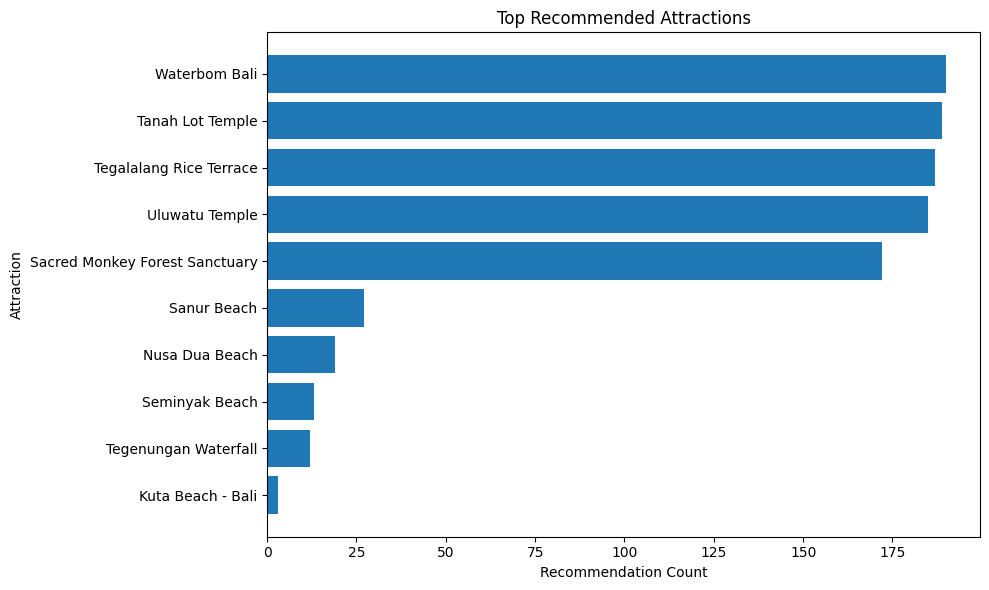

In [343]:
# STEP 294: Recommendation Visualization

if not final_recommendations.empty:
    import matplotlib.pyplot as plt

    top_10_recommended = recommendation_attraction_summary.sort_values()

    plt.figure(figsize=(10, 6))
    plt.barh(
        top_10_recommended.index,
        top_10_recommended.values
    )
    plt.xlabel("Recommendation Count")
    plt.ylabel("Attraction")
    plt.title("Top Recommended Attractions")
    plt.tight_layout()
    plt.show()
else:
    print("No recommendation records available.")


In [344]:
# STEP 295: Recommendation Score Summary

if not final_recommendations.empty:
    print(
        "Average Recommendation Score:",
        final_recommendations["RecommendationScore"].mean()
    )
    print(
        "Minimum Recommendation Score:",
        final_recommendations["RecommendationScore"].min()
    )
    print(
        "Maximum Recommendation Score:",
        final_recommendations["RecommendationScore"].max()
    )


Average Recommendation Score: 0.3235333649503847
Minimum Recommendation Score: 0.24818171793348076
Maximum Recommendation Score: 0.6480776137605754


In [345]:
# STEP 296: Recommendation Score Distribution

if not final_recommendations.empty:
    print(
        final_recommendations["RecommendationScore"].describe()
    )


count    1000.000000
mean        0.323533
std         0.083493
min         0.248182
25%         0.249448
50%         0.303925
75%         0.363255
max         0.648078
Name: RecommendationScore, dtype: float64


In [346]:
# STEP 297: Recommendation Type Summary

if not final_recommendations.empty:
    recommendation_type_summary = (
        final_recommendations
        .groupby("AttractionTypeId")
        .size()
        .sort_values(ascending=False)
    )
    print("Recommendation Count by Attraction Type")
    display(recommendation_type_summary)


Recommendation Count by Attraction Type


,0
AttractionTypeId,
76,374
92,190
72,187
63,173
13,64
93,12


In [347]:
# STEP 298: Recommendation Rating Summary

if not final_recommendations.empty:
    print(
        final_recommendations["AverageRating"].describe()
    )


count    1000.000000
mean        4.273765
std         0.199175
min         3.411483
25%         4.195364
50%         4.217691
75%         4.265109
max         4.643248
Name: AverageRating, dtype: float64


In [348]:
# STEP 299: Final Recommendation Sample

if not final_recommendations.empty:
    display(final_recommendations.head(20))


,UserId,AttractionId,Attraction,AttractionTypeId,AttractionCityId,AverageRating,CollaborativeScore,ContentScore,ModeAffinity,RecommendationScore,RecommendationMethod
0,113,640,Sacred Monkey Forest Sanctuary,63,1,4.265109,0.000000,0.0,0.000000,0.363255,Cold-start content + VisitMode + quality/popul...
1,113,841,Waterbom Bali,92,1,4.643248,0.000000,0.0,0.000000,0.303925,Cold-start content + VisitMode + quality/popul...
2,113,748,Tegalalang Rice Terrace,72,1,4.158032,0.000000,0.0,0.000000,0.274634,Cold-start content + VisitMode + quality/popul...
3,113,824,Uluwatu Temple,76,1,4.217691,0.000000,0.0,0.000000,0.249448,Cold-start content + VisitMode + quality/popul...
4,113,737,Tanah Lot Temple,76,1,4.195364,0.000000,0.0,0.000000,0.248182,Cold-start content + VisitMode + quality/popul...
5,742,640,Sacred Monkey Forest Sanctuary,63,1,4.265109,0.173760,0.8,1.000000,0.607457,Hybrid collaborative + content + VisitMode + q...
6,742,748,Tegalalang Rice Terrace,72,1,4.158032,0.203712,0.8,0.439452,0.476632,Hybrid collaborative + content + VisitMode + q...
7,742,841,Waterbom Bali,92,1,4.643248,0.054215,0.8,0.213990,0.400923,Hybrid collaborative + content + VisitMode + q...
8,742,737,Tanah Lot Temple,76,1,4.195364,0.086246,0.8,0.237094,0.381532,Hybrid collaborative + content + VisitMode + q...
9,742,824,Uluwatu Temple,76,1,4.217691,0.069822,0.8,0.235500,0.375494,Hybrid collaborative + content + VisitMode + q...


# Final Model & Recommendation System Conclusion

In [349]:
# STEP 300: Final Classification & Recommendation Summary

print("========== FINAL CLASSIFICATION SUMMARY ==========")
print("Selected VisitMode Model:", best_visitmode_name)
print(
    "Accuracy:",
    best_visitmode_row["Accuracy"]
)
print(
    "Macro F1:",
    best_visitmode_row["Macro F1"]
)
print(
    "Weighted F1:",
    best_visitmode_row["Weighted F1"]
)
print(
    "Balanced Accuracy:",
    best_visitmode_row["Balanced Accuracy"]
)

print("\n========== RECOMMENDATION SUMMARY ==========")
print("MAP@5:", map_at_5)
print(
    "Recommendation records:",
    len(final_recommendations)
)


========== FINAL CLASSIFICATION SUMMARY ==========
Selected VisitMode Model: Random Forest
Accuracy: 0.47348951911220716
Macro F1: 0.2732709567829287
Weighted F1: 0.45036989914240677
Balanced Accuracy: 0.27906741872878693

========== RECOMMENDATION SUMMARY ==========
MAP@5: 0.4211161011310712
Recommendation records: 1000


# Model Saving & Reload/Sanity Check

In [350]:
# STEP 301: Save Correct VisitMode Classification Model

import joblib

model_path = "tourism_random_forest_model.joblib"

# Preserve the project filename used by Streamlit, but now the model
# correctly predicts VisitMode rather than Rating.
joblib.dump(
    best_visitmode_model,
    model_path
)

# Save the classification preprocessing metadata required by deployment.
classification_metadata = {
    "feature_names": classification_features,
    "scale_features": classification_scale_features,
    "scaler": classification_scaler,
    "target": "VisitMode",
    "classes": list(best_visitmode_model.classes_),
    "model_name": best_visitmode_name
}

joblib.dump(
    classification_metadata,
    "tourism_visitmode_preprocessing.joblib"
)

print("Correct VisitMode model saved successfully.")
print("Model file:", model_path)
print(
    "Preprocessing metadata:",
    "tourism_visitmode_preprocessing.joblib"
)


Correct VisitMode model saved successfully.
Model file: tourism_random_forest_model.joblib
Preprocessing metadata: tourism_visitmode_preprocessing.joblib


In [351]:
# STEP 302: Reload Correct VisitMode Model

loaded_visitmode_model = joblib.load(
    "tourism_random_forest_model.joblib"
)

print("Saved model loaded successfully!")
print(
    "Model type:",
    type(loaded_visitmode_model).__name__
)

print(
    "Classes:",
    loaded_visitmode_model.classes_
)


Saved model loaded successfully!
Model type: RandomForestClassifier
Classes: [1 2 3 4 5]


In [352]:
# STEP 303: Correct VisitMode Model Reload Sanity Check

loaded_visitmode_predictions = (
    loaded_visitmode_model.predict(
        X_test_visitmode_scaled
    )
)

print("========== RELOADED VISITMODE MODEL SANITY CHECK ==========")

print(
    "Number of predictions:",
    len(loaded_visitmode_predictions)
)

print(
    "Predictions generated successfully:",
    len(loaded_visitmode_predictions)
    == len(y_test_visitmode)
)

print(
    "Unique predicted VisitModes:",
    sorted(set(loaded_visitmode_predictions))
)

print(
    "Reloaded model accuracy:",
    accuracy_score(
        y_test_visitmode,
        loaded_visitmode_predictions
    )
)


========== RELOADED VISITMODE MODEL SANITY CHECK ==========
Number of predictions: 811
Predictions generated successfully: True
Unique predicted VisitModes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Reloaded model accuracy: 0.47348951911220716


# 7. Regression Model – Attraction Rating Prediction

The project document defines regression as prediction of the rating a user might give to a tourist attraction. The target is `Rating`.

For methodological correctness, regression uses:
- safe base features available for the current prediction
- prior-only user, user-attraction and attraction historical features

All-data aggregates that include the current transaction are excluded to avoid target leakage.


In [353]:
# ==========================================================
# Regression Dataset Preparation
# ==========================================================

# Target variable
y_reg = transaction_features["Rating"].copy()

# Features: leakage-prone rating aggregates ko remove karenge
regression_drop_cols = [
    "Rating",
    "AverageRating",
    "RatingStd",
    "AverageRating_User",
    "AverageRating_Attraction",
    "RatingDeviationFromUser",
    "RatingDeviationFromAttraction"
]

X_reg = transaction_features.drop(
    columns=regression_drop_cols,
    errors="ignore"
)

print("Regression Dataset Shape:")
print("X_reg:", X_reg.shape)
print("y_reg:", y_reg.shape)

print("\nMissing Values:")
print("X_reg missing:", X_reg.isna().sum().sum())
print("y_reg missing:", y_reg.isna().sum())

print("\nTarget Distribution:")
print(y_reg.value_counts().sort_index())

Regression Dataset Shape:
X_reg: (52930, 52)
y_reg: (52930,)

Missing Values:
X_reg missing: 0
y_reg missing: 0

Target Distribution:
Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64


In [354]:
# ==========================================================
# Regression Train-Test Split
# ==========================================================

# Use VisitYear for chronological split
train_mask_reg = transaction_features["VisitYear"] <= 2019
test_mask_reg = transaction_features["VisitYear"] >= 2020

X_train_reg = X_reg.loc[train_mask_reg].copy()
X_test_reg = X_reg.loc[test_mask_reg].copy()

y_train_reg = y_reg.loc[train_mask_reg].copy()
y_test_reg = y_reg.loc[test_mask_reg].copy()

print("Regression Train-Test Split:")
print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)
print("y_train_reg:", y_train_reg.shape)
print("y_test_reg :", y_test_reg.shape)

print("\nTraining Years:")
print(transaction_features.loc[train_mask_reg, "VisitYear"].unique())

print("\nTesting Years:")
print(transaction_features.loc[test_mask_reg, "VisitYear"].unique())

print("\nMissing Values:")
print("X_train_reg:", X_train_reg.isna().sum().sum())
print("X_test_reg :", X_test_reg.isna().sum().sum())
print("y_train_reg:", y_train_reg.isna().sum())
print("y_test_reg :", y_test_reg.isna().sum())

Regression Train-Test Split:
X_train_reg: (52119, 52)
X_test_reg : (811, 52)
y_train_reg: (52119,)
y_test_reg : (811,)

Training Years:
[2019 2018 2014 2013 2017 2016 2015]

Testing Years:
[2022 2021 2020]

Missing Values:
X_train_reg: 0
X_test_reg : 0
y_train_reg: 0
y_test_reg : 0


In [355]:
# ==========================================================
#  Regression Feature Validation
# ==========================================================

print("Total Regression Features:", X_train_reg.shape[1])

print("\nRegression Feature List:")
for i, col in enumerate(X_train_reg.columns, start=1):
    print(f"{i}. {col}")

print("\nData Types:")
print(X_train_reg.dtypes.value_counts())

print("\nNumeric Check:")
print("All features numeric:", X_train_reg.select_dtypes(exclude="number").shape[1] == 0)

print("\nDuplicate Columns:")
print("Duplicate column names:", X_train_reg.columns.duplicated().sum())

Total Regression Features: 52

Regression Feature List:
1. TransactionId
2. UserId
3. VisitYear
4. VisitMonth
5. VisitMode
6. AttractionId
7. VisitDate
8. VisitQuarter
9. VisitSeason
10. InteractionCount
11. FirstVisitYear
12. LastVisitYear
13. UniqueVisitMonths
14. UniqueVisitModes
15. TotalInteractions
16. UniqueAttractions
17. UniqueVisitModes_User
18. UniqueVisitYears
19. UniqueVisitMonths_User
20. TotalInteractions_Attraction
21. UniqueUsers
22. UniqueVisitModes_Attraction
23. UniqueVisitYears_Attraction
24. UniqueVisitMonths_Attraction
25. AttractionsPerInteraction
26. Season_Autumn
27. Season_Spring
28. Season_Summer
29. Season_Winter
30. VisitMode_1
31. VisitMode_2
32. VisitMode_3
33. VisitMode_4
34. VisitMode_5
35. AttractionTypeId
36. AttractionType_2
37. AttractionType_10
38. AttractionType_13
39. AttractionType_19
40. AttractionType_34
41. AttractionType_44
42. AttractionType_45
43. AttractionType_61
44. AttractionType_63
45. AttractionType_64
46. AttractionType_72
47. Attr

In [356]:
# STEP 300: Leakage-Safe Regression Feature Selection

# Regression target is Rating.
# Only features that are known before the current transaction are used.
#
# The all-data aggregate features identified earlier as leakage-risk
# are intentionally excluded. Prior-only historical features created
# in STEPs 237-240 are retained.

regression_safe_base = [
    col for col in safe_features
    if col in X_train_reg.columns
]

print("Safe base regression features:", len(regression_safe_base))
print("\nSafe base feature list:")
for i, col in enumerate(regression_safe_base, start=1):
    print(f"{i}. {col}")

print("\nLeakage-risk features excluded from regression:")
print([col for col in leakage_risk_features if col in X_train_reg.columns])

print("\nNon-numeric safe features:")
print(
    X_train_reg[regression_safe_base]
    .select_dtypes(exclude="number")
    .columns.tolist()
)


Safe base regression features: 29

Safe base feature list:
1. VisitYear
2. VisitMonth
3. VisitQuarter
4. Season_Autumn
5. Season_Spring
6. Season_Summer
7. Season_Winter
8. VisitMode_1
9. VisitMode_2
10. VisitMode_3
11. VisitMode_4
12. VisitMode_5
13. AttractionType_2
14. AttractionType_10
15. AttractionType_13
16. AttractionType_19
17. AttractionType_34
18. AttractionType_44
19. AttractionType_45
20. AttractionType_61
21. AttractionType_63
22. AttractionType_64
23. AttractionType_72
24. AttractionType_76
25. AttractionType_82
26. AttractionType_84
27. AttractionType_91
28. AttractionType_92
29. AttractionType_93

Leakage-risk features excluded from regression:
['InteractionCount', 'FirstVisitYear', 'LastVisitYear', 'UniqueVisitMonths', 'UniqueVisitModes', 'TotalInteractions', 'UniqueAttractions', 'UniqueVisitModes_User', 'UniqueVisitYears', 'UniqueVisitMonths_User', 'TotalInteractions_Attraction', 'UniqueUsers', 'UniqueVisitModes_Attraction', 'UniqueVisitYears_Attraction', 'UniqueVisi

In [357]:
# ==========================================================
# Check Corrected Historical Features
# ==========================================================

historical_reg_features = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_User_TrainUser",
    "InteractionCount_TrainPair",
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair",
    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitModes_Attraction_TrainAttraction",
    "UniqueVisitYears_Attraction_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction"
]

print("Checking corrected historical features...\n")

for col in historical_reg_features:
    print(f"{col}: {col in train_df.columns}")

print("\nTotal available:",
      sum(col in train_df.columns for col in historical_reg_features),
      "/", len(historical_reg_features))

Checking corrected historical features...

TotalInteractions_TrainUser: False
UniqueAttractions_TrainUser: False
UniqueVisitModes_User_TrainUser: False
UniqueVisitYears_TrainUser: False
UniqueVisitMonths_User_TrainUser: False
InteractionCount_TrainPair: False
FirstVisitYear_TrainPair: False
LastVisitYear_TrainPair: False
UniqueVisitMonths_TrainPair: False
UniqueVisitModes_TrainPair: False
TotalInteractions_Attraction_TrainAttraction: False
UniqueUsers_TrainAttraction: False
UniqueVisitModes_Attraction_TrainAttraction: False
UniqueVisitYears_Attraction_TrainAttraction: False
UniqueVisitMonths_Attraction_TrainAttraction: False

Total available: 0 / 15


In [358]:
# ==========================================================
#  Recreate Prior-Only Historical Features
# ==========================================================

# Work on a fresh chronological copy
reg_train = transaction_features.loc[train_mask_reg].copy()

reg_train = reg_train.sort_values(
    ["VisitYear", "VisitMonth", "TransactionId"]
).reset_index(drop=True)

# ----------------------------------------------------------
# User-level prior history
# ----------------------------------------------------------

user_interactions = {}
user_attractions = {}
user_modes = {}
user_years = {}
user_months = {}

user_history = []

for _, row in reg_train.iterrows():

    user = row["UserId"]

    user_history.append({
        "TotalInteractions_TrainUser":
            user_interactions.get(user, 0),

        "UniqueAttractions_TrainUser":
            len(user_attractions.get(user, set())),

        "UniqueVisitModes_User_TrainUser":
            len(user_modes.get(user, set())),

        "UniqueVisitYears_TrainUser":
            len(user_years.get(user, set())),

        "UniqueVisitMonths_User_TrainUser":
            len(user_months.get(user, set()))
    })

    user_interactions[user] = user_interactions.get(user, 0) + 1
    user_attractions.setdefault(user, set()).add(row["AttractionId"])
    user_modes.setdefault(user, set()).add(row["VisitMode"])
    user_years.setdefault(user, set()).add(row["VisitYear"])
    user_months.setdefault(user, set()).add(row["VisitMonth"])


# ----------------------------------------------------------
# Pair-level prior history
# ----------------------------------------------------------

pair_history = {}

pair_features = []

for _, row in reg_train.iterrows():

    pair = (row["UserId"], row["AttractionId"])

    history = pair_history.get(
        pair,
        {
            "count": 0,
            "first_year": None,
            "last_year": None,
            "months": set(),
            "modes": set()
        }
    )

    pair_features.append({
        "InteractionCount_TrainPair": history["count"],
        "FirstVisitYear_TrainPair":
            history["first_year"] if history["first_year"] is not None else 0,
        "LastVisitYear_TrainPair":
            history["last_year"] if history["last_year"] is not None else 0,
        "UniqueVisitMonths_TrainPair":
            len(history["months"]),
        "UniqueVisitModes_TrainPair":
            len(history["modes"])
    })

    pair_history[pair] = {
        "count": history["count"] + 1,
        "first_year":
            row["VisitYear"]
            if history["first_year"] is None
            else history["first_year"],
        "last_year": row["VisitYear"],
        "months": history["months"] | {row["VisitMonth"]},
        "modes": history["modes"] | {row["VisitMode"]}
    }


# ----------------------------------------------------------
# Attraction-level prior history
# ----------------------------------------------------------

attraction_interactions = {}
attraction_users = {}
attraction_modes = {}
attraction_years = {}
attraction_months = {}

attraction_history = []

for _, row in reg_train.iterrows():

    attraction = row["AttractionId"]

    attraction_history.append({
        "TotalInteractions_Attraction_TrainAttraction":
            attraction_interactions.get(attraction, 0),

        "UniqueUsers_TrainAttraction":
            len(attraction_users.get(attraction, set())),

        "UniqueVisitModes_Attraction_TrainAttraction":
            len(attraction_modes.get(attraction, set())),

        "UniqueVisitYears_Attraction_TrainAttraction":
            len(attraction_years.get(attraction, set())),

        "UniqueVisitMonths_Attraction_TrainAttraction":
            len(attraction_months.get(attraction, set()))
    })

    attraction_interactions[attraction] = \
        attraction_interactions.get(attraction, 0) + 1

    attraction_users.setdefault(attraction, set()).add(row["UserId"])
    attraction_modes.setdefault(attraction, set()).add(row["VisitMode"])
    attraction_years.setdefault(attraction, set()).add(row["VisitYear"])
    attraction_months.setdefault(attraction, set()).add(row["VisitMonth"])


# ----------------------------------------------------------
# Combine historical features
# ----------------------------------------------------------

user_history_df = pd.DataFrame(user_history)
pair_features_df = pd.DataFrame(pair_features)
attraction_history_df = pd.DataFrame(attraction_history)

reg_train_corrected = pd.concat(
    [
        reg_train.reset_index(drop=True),
        user_history_df,
        pair_features_df,
        attraction_history_df
    ],
    axis=1
)

print("Corrected Regression Training Data:")
print("Shape:", reg_train_corrected.shape)

print("\nMissing Values:",
      reg_train_corrected.isna().sum().sum())

print("\nDuplicate TransactionIds:",
      reg_train_corrected["TransactionId"].duplicated().sum())

Corrected Regression Training Data:
Shape: (52119, 74)

Missing Values: 0

Duplicate TransactionIds: 0


In [360]:
# STEP 303: Final Leakage-Safe Regression Feature Selection
# FIX: Use only historical features that actually exist

reg_history_features = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_TrainUser",
    "InteractionCount_TrainPair",
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair",
    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitModes_Attraction_TrainAttraction",
    "UniqueVisitYears_Attraction_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction"
]

# Check which historical features are available
available_history_features = [
    col for col in reg_history_features
    if col in reg_train_corrected.columns
]

missing_history_features = [
    col for col in reg_history_features
    if col not in reg_train_corrected.columns
]

print("Available historical features:", len(available_history_features))
print(available_history_features)

print("\nMissing historical features:", len(missing_history_features))
print(missing_history_features)

# Final regression features
final_reg_features = list(
    dict.fromkeys(
        regression_safe_base + available_history_features
    )
)

X_train_reg_final = reg_train_corrected[
    final_reg_features
].copy()

y_train_reg_final = reg_train_corrected[
    "Rating"
].copy()

print("\nFinal Regression Training Data:")
print("X_train_reg_final:", X_train_reg_final.shape)
print("y_train_reg_final:", y_train_reg_final.shape)

print("\nExpected feature count:", len(final_reg_features))

print("\nMissing Values:")
print("X_train:", X_train_reg_final.isna().sum().sum())
print("y_train:", y_train_reg_final.isna().sum())

print("\nNon-Numeric Features:")
print(
    X_train_reg_final
    .select_dtypes(exclude="number")
    .columns.tolist()
)

print(
    "\nDuplicate Feature Names:",
    X_train_reg_final.columns.duplicated().sum()
)

Available historical features: 14
['TotalInteractions_TrainUser', 'UniqueAttractions_TrainUser', 'UniqueVisitModes_User_TrainUser', 'UniqueVisitYears_TrainUser', 'InteractionCount_TrainPair', 'FirstVisitYear_TrainPair', 'LastVisitYear_TrainPair', 'UniqueVisitMonths_TrainPair', 'UniqueVisitModes_TrainPair', 'TotalInteractions_Attraction_TrainAttraction', 'UniqueUsers_TrainAttraction', 'UniqueVisitModes_Attraction_TrainAttraction', 'UniqueVisitYears_Attraction_TrainAttraction', 'UniqueVisitMonths_Attraction_TrainAttraction']

Missing historical features: 1
['UniqueVisitMonths_TrainUser']

Final Regression Training Data:
X_train_reg_final: (52119, 43)
y_train_reg_final: (52119,)

Expected feature count: 43

Missing Values:
X_train: 0
y_train: 0

Non-Numeric Features:
[]

Duplicate Feature Names: 0


In [362]:
# ==========================================================
# STEP 303: Final Leakage-Safe Regression Feature Selection
# ==========================================================

# Base regression features already validated as safe
reg_base_features = regression_safe_base.copy()

# Prior-only historical features
reg_history_features = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_TrainUser",

    "InteractionCount_TrainPair",
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair",

    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitModes_Attraction_TrainAttraction",
    "UniqueVisitYears_Attraction_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction"
]

# Keep only historical features that actually exist
available_history_features = [
    col for col in reg_history_features
    if col in reg_train_corrected.columns
]

missing_history_features = [
    col for col in reg_history_features
    if col not in reg_train_corrected.columns
]

print("Available historical features:")
print(available_history_features)

print("\nMissing historical features:")
print(missing_history_features)

# Final regression feature list
final_reg_features = list(
    dict.fromkeys(
        reg_base_features + available_history_features
    )
)

# Training data
X_train_reg_final = reg_train_corrected[
    final_reg_features
].copy()

y_train_reg_final = reg_train_corrected[
    "Rating"
].copy()

print("\n==========================================")
print("FINAL REGRESSION TRAINING DATA")
print("==========================================")

print("X_train_reg_final:", X_train_reg_final.shape)
print("y_train_reg_final:", y_train_reg_final.shape)

print("\nFinal feature count:", len(final_reg_features))

print("\nMissing values in X:",
      X_train_reg_final.isna().sum().sum())

print("Missing values in y:",
      y_train_reg_final.isna().sum())

print("\nNon-numeric features:")
print(
    X_train_reg_final
    .select_dtypes(exclude="number")
    .columns.tolist()
)

print("\nDuplicate feature names:",
      X_train_reg_final.columns.duplicated().sum())

Available historical features:
['TotalInteractions_TrainUser', 'UniqueAttractions_TrainUser', 'UniqueVisitModes_User_TrainUser', 'UniqueVisitYears_TrainUser', 'InteractionCount_TrainPair', 'FirstVisitYear_TrainPair', 'LastVisitYear_TrainPair', 'UniqueVisitMonths_TrainPair', 'UniqueVisitModes_TrainPair', 'TotalInteractions_Attraction_TrainAttraction', 'UniqueUsers_TrainAttraction', 'UniqueVisitModes_Attraction_TrainAttraction', 'UniqueVisitYears_Attraction_TrainAttraction', 'UniqueVisitMonths_Attraction_TrainAttraction']

Missing historical features:
['UniqueVisitMonths_TrainUser']

FINAL REGRESSION TRAINING DATA
X_train_reg_final: (52119, 43)
y_train_reg_final: (52119,)

Final feature count: 43

Missing values in X: 0
Missing values in y: 0

Non-numeric features:
[]

Duplicate feature names: 0


In [364]:
# ==========================================================
# STEP 304: Final Leakage-Safe Regression Test Data
# ==========================================================

# Regression base features
reg_base_features = regression_safe_base.copy()

# Test base features
X_test_reg_base = reg_test[
    reg_base_features
].copy().reset_index(drop=True)

# Test historical features
X_test_reg_history = test_history_df[
    available_history_features
].copy().reset_index(drop=True)

# Combine base + historical features
X_test_reg_final = pd.concat(
    [
        X_test_reg_base,
        X_test_reg_history
    ],
    axis=1
)

# Target
y_test_reg_final = reg_test[
    "Rating"
].copy().reset_index(drop=True)

# Remove accidental duplicate columns
X_test_reg_final = X_test_reg_final.loc[
    :,
    ~X_test_reg_final.columns.duplicated()
]

print("==========================================")
print("FINAL REGRESSION TEST DATA")
print("==========================================")

print("X_test_reg_final:", X_test_reg_final.shape)
print("y_test_reg_final:", y_test_reg_final.shape)

print("\nMissing values in X:",
      X_test_reg_final.isna().sum().sum())

print("Missing values in y:",
      y_test_reg_final.isna().sum())

print("\nNon-numeric features:")
print(
    X_test_reg_final
    .select_dtypes(exclude="number")
    .columns.tolist()
)

print("\nDuplicate feature names:",
      X_test_reg_final.columns.duplicated().sum())

print("\nFeature alignment:")
print(
    "Train/Test features same:",
    list(X_train_reg_final.columns)
    == list(X_test_reg_final.columns)
)

FINAL REGRESSION TEST DATA
X_test_reg_final: (811, 43)
y_test_reg_final: (811,)

Missing values in X: 0
Missing values in y: 0

Non-numeric features:
[]

Duplicate feature names: 0

Feature alignment:
Train/Test features same: True


In [365]:
# ==========================================================
#  Linear Regression Model
# ==========================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
import numpy as np

# Create model
linear_reg_model = LinearRegression()

# Train model
linear_reg_model.fit(
    X_train_reg_final,
    y_train_reg_final
)

# Predict on test data
y_pred_linear = linear_reg_model.predict(
    X_test_reg_final
)

# Evaluation
r2_linear = r2_score(
    y_test_reg_final,
    y_pred_linear
)

mse_linear = mean_squared_error(
    y_test_reg_final,
    y_pred_linear
)

rmse_linear = np.sqrt(mse_linear)

mae_linear = mean_absolute_error(
    y_test_reg_final,
    y_pred_linear
)

print("Linear Regression Results")
print("=" * 40)
print("R² Score :", round(r2_linear, 4))
print("MSE      :", round(mse_linear, 4))
print("RMSE     :", round(rmse_linear, 4))
print("MAE      :", round(mae_linear, 4))

Linear Regression Results
R² Score : 0.0064
MSE      : 1.077
RMSE     : 1.0378
MAE      : 0.8641


In [366]:
# ==========================================================
# Random Forest Regression
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# Create model
rf_reg_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_reg_model.fit(
    X_train_reg_final,
    y_train_reg_final
)

# Predict on test data
y_pred_rf_reg = rf_reg_model.predict(
    X_test_reg_final
)

# Evaluation
r2_rf_reg = r2_score(
    y_test_reg_final,
    y_pred_rf_reg
)

mse_rf_reg = mean_squared_error(
    y_test_reg_final,
    y_pred_rf_reg
)

rmse_rf_reg = np.sqrt(mse_rf_reg)

mae_rf_reg = mean_absolute_error(
    y_test_reg_final,
    y_pred_rf_reg
)

print("Random Forest Regression Results")
print("=" * 40)
print("R² Score :", round(r2_rf_reg, 4))
print("MSE      :", round(mse_rf_reg, 4))
print("RMSE     :", round(rmse_rf_reg, 4))
print("MAE      :", round(mae_rf_reg, 4))

Random Forest Regression Results
R² Score : 0.0138
MSE      : 1.0689
RMSE     : 1.0339
MAE      : 0.8016


In [367]:
# ==========================================================
#  Gradient Boosting Regression
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

# Create model
gb_reg_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train model
gb_reg_model.fit(
    X_train_reg_final,
    y_train_reg_final
)

# Predict on test data
y_pred_gb_reg = gb_reg_model.predict(
    X_test_reg_final
)

# Evaluation
r2_gb_reg = r2_score(
    y_test_reg_final,
    y_pred_gb_reg
)

mse_gb_reg = mean_squared_error(
    y_test_reg_final,
    y_pred_gb_reg
)

rmse_gb_reg = np.sqrt(mse_gb_reg)

mae_gb_reg = mean_absolute_error(
    y_test_reg_final,
    y_pred_gb_reg
)

print("Gradient Boosting Regression Results")
print("=" * 40)
print("R² Score :", round(r2_gb_reg, 4))
print("MSE      :", round(mse_gb_reg, 4))
print("RMSE     :", round(rmse_gb_reg, 4))
print("MAE      :", round(mae_gb_reg, 4))

Gradient Boosting Regression Results
R² Score : 0.0862
MSE      : 0.9904
RMSE     : 0.9952
MAE      : 0.7756


In [368]:
# ==========================================================
# STEP 303 — Regression Model Comparison
# ==========================================================

regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression",
        "Gradient Boosting Regression"
    ],
    "R2": [
        r2_linear,
        r2_rf_reg,
        r2_gb_reg
    ],
    "MSE": [
        mse_linear,
        mse_rf_reg,
        mse_gb_reg
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf_reg,
        rmse_gb_reg
    ],
    "MAE": [
        mae_linear,
        mae_rf_reg,
        mae_gb_reg
    ]
})

print("Regression Model Comparison")
print("=" * 70)
print(regression_results.round(4).to_string(index=False))

# Best model based on highest R²
best_regression_model_name = regression_results.loc[
    regression_results["R2"].idxmax(),
    "Model"
]

print("\nBest Regression Model:", best_regression_model_name)

Regression Model Comparison
                       Model     R2    MSE   RMSE    MAE
           Linear Regression 0.0064 1.0770 1.0378 0.8641
    Random Forest Regression 0.0138 1.0689 1.0339 0.8016
Gradient Boosting Regression 0.0862 0.9904 0.9952 0.7756

Best Regression Model: Gradient Boosting Regression


In [369]:
# ==========================================================
#  Gradient Boosting Feature Importance
# ==========================================================

feature_importance_reg = pd.DataFrame({
    "Feature": X_train_reg_final.columns,
    "Importance": gb_reg_model.feature_importances_
})

feature_importance_reg = feature_importance_reg.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 15 Regression Feature Importances")
print("=" * 60)
print(feature_importance_reg.head(15).round(6).to_string(index=False))

Top 15 Regression Feature Importances
                                     Feature  Importance
                           AttractionType_92    0.348549
                           AttractionType_13    0.163900
TotalInteractions_Attraction_TrainAttraction    0.134826
                           AttractionType_44    0.061022
                               Season_Winter    0.052280
                 UniqueUsers_TrainAttraction    0.050998
                           AttractionType_93    0.022395
                           AttractionType_76    0.019396
                           AttractionType_34    0.016632
                                   VisitYear    0.014204
                           AttractionType_61    0.014122
                                  VisitMonth    0.012197
                 TotalInteractions_TrainUser    0.007400
                                 VisitMode_1    0.007395
                               Season_Spring    0.006112


In [370]:
# ==========================================================
# Actual vs Predicted Ratings
# ==========================================================

regression_prediction_df = pd.DataFrame({
    "ActualRating": y_test_reg_final.values,
    "PredictedRating": y_pred_gb_reg
})

# Round predictions for easier interpretation
regression_prediction_df["PredictedRating_Rounded"] = (
    regression_prediction_df["PredictedRating"]
    .round()
    .clip(1, 5)
    .astype(int)
)

print("Actual vs Predicted Ratings")
print("=" * 60)

print(
    regression_prediction_df.head(20).round(4).to_string(index=False)
)

print("\nPrediction Summary")
print("=" * 60)

print(
    "Actual Mean:",
    round(regression_prediction_df["ActualRating"].mean(), 4)
)

print(
    "Predicted Mean:",
    round(regression_prediction_df["PredictedRating"].mean(), 4)
)

print(
    "Minimum Prediction:",
    round(regression_prediction_df["PredictedRating"].min(), 4)
)

print(
    "Maximum Prediction:",
    round(regression_prediction_df["PredictedRating"].max(), 4)
)

print(
    "Rounded Predictions:",
    sorted(
        regression_prediction_df[
            "PredictedRating_Rounded"
        ].unique().tolist()
    )
)

Actual vs Predicted Ratings
 ActualRating  PredictedRating  PredictedRating_Rounded
            5           4.3137                        4
            5           4.3703                        4
            5           4.4067                        4
            5           4.3218                        4
            5           4.3218                        4
            5           4.3756                        4
            5           4.3703                        4
            3           4.3218                        4
            5           4.3218                        4
            3           4.3721                        4
            4           4.4067                        4
            4           4.4067                        4
            5           4.3703                        4
            5           4.3622                        4
            4           4.3218                        4
            5           4.3703                        4
            4       

In [371]:
# ==========================================================
# STEP 306 — Prediction Accuracy Within ±1 Rating
# ==========================================================

regression_prediction_df["AbsoluteError"] = (
    regression_prediction_df["ActualRating"]
    - regression_prediction_df["PredictedRating"]
).abs()

within_1_rating = (
    regression_prediction_df["AbsoluteError"] <= 1
)

within_05_rating = (
    regression_prediction_df["AbsoluteError"] <= 0.5
)

accuracy_within_1 = within_1_rating.mean() * 100
accuracy_within_05 = within_05_rating.mean() * 100

print("Regression Prediction Accuracy")
print("=" * 60)

print(
    "Predictions within ±1 rating:",
    round(accuracy_within_1, 2),
    "%"
)

print(
    "Predictions within ±0.5 rating:",
    round(accuracy_within_05, 2),
    "%"
)

print(
    "\nMean Absolute Error:",
    round(
        regression_prediction_df["AbsoluteError"].mean(),
        4
    )
)

print(
    "Maximum Absolute Error:",
    round(
        regression_prediction_df["AbsoluteError"].max(),
        4
    )
)

Regression Prediction Accuracy
Predictions within ±1 rating: 76.7 %
Predictions within ±0.5 rating: 41.06 %

Mean Absolute Error: 0.7756
Maximum Absolute Error: 3.6581


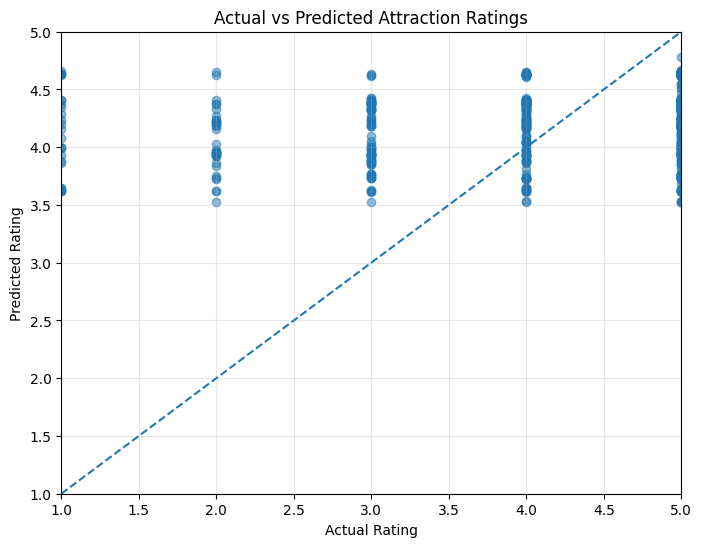

In [372]:
# ==========================================================
# Actual vs Predicted Rating Visualization
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    regression_prediction_df["ActualRating"],
    regression_prediction_df["PredictedRating"],
    alpha=0.5
)

# Perfect prediction reference line
plt.plot(
    [1, 5],
    [1, 5],
    linestyle="--"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Attraction Ratings")

plt.xlim(1, 5)
plt.ylim(1, 5)

plt.grid(True, alpha=0.3)
plt.show()

In [373]:
# ==========================================================
#  Save Best Regression Model
# ==========================================================

import joblib

# Save the best regression model
joblib.dump(
    gb_reg_model,
    "tourism_gradient_boosting_regression_model.joblib"
)

print("Regression model saved successfully!")
print(
    "File: tourism_gradient_boosting_regression_model.joblib"
)

Regression model saved successfully!
File: tourism_gradient_boosting_regression_model.joblib


In [374]:
# ==========================================================
# STEP 309 — Reload Regression Model & Sanity Check
# ==========================================================

import joblib

# Load saved model
loaded_regression_model = joblib.load(
    "tourism_gradient_boosting_regression_model.joblib"
)

print("Loaded Model Type:")
print(type(loaded_regression_model))

# Generate predictions using loaded model
loaded_reg_predictions = loaded_regression_model.predict(
    X_test_reg_final
)

print("\nSanity Check")
print("=" * 50)

print(
    "Number of Predictions:",
    len(loaded_reg_predictions)
)

print(
    "Predictions Generated Successfully:",
    len(loaded_reg_predictions) == len(y_test_reg_final)
)

print(
    "First 10 Predictions:",
    np.round(loaded_reg_predictions[:10], 4)
)

print(
    "Prediction Range:",
    round(loaded_reg_predictions.min(), 4),
    "to",
    round(loaded_reg_predictions.max(), 4)
)

Loaded Model Type:
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>

Sanity Check
Number of Predictions: 811
Predictions Generated Successfully: True
First 10 Predictions: [4.3137 4.3703 4.4067 4.3218 4.3218 4.3756 4.3703 4.3218 4.3218 4.3721]
Prediction Range: 3.526 to 4.7798


In [375]:
# ==========================================================
#  Final Regression Summary
# ==========================================================

print("FINAL REGRESSION MODEL SUMMARY")
print("=" * 60)

print("Best Model:", best_regression_model_name)

print("\nEvaluation Metrics:")
print("R² Score :", round(r2_gb_reg, 4))
print("MSE      :", round(mse_gb_reg, 4))
print("RMSE     :", round(rmse_gb_reg, 4))
print("MAE      :", round(mae_gb_reg, 4))

print("\nPractical Prediction Accuracy:")
print(
    "Within ±1 Rating :",
    round(accuracy_within_1, 2),
    "%"
)

print(
    "Within ±0.5 Rating :",
    round(accuracy_within_05, 2),
    "%"
)

print("\nPrediction Statistics:")
print(
    "Actual Mean Rating    :",
    round(
        regression_prediction_df["ActualRating"].mean(),
        4
    )
)

print(
    "Predicted Mean Rating :",
    round(
        regression_prediction_df["PredictedRating"].mean(),
        4
    )
)

print("\nModel File:")
print("tourism_gradient_boosting_regression_model.joblib")

print("\nRegression Objective Status: COMPLETED")

FINAL REGRESSION MODEL SUMMARY
Best Model: Gradient Boosting Regression

Evaluation Metrics:
R² Score : 0.0862
MSE      : 0.9904
RMSE     : 0.9952
MAE      : 0.7756

Practical Prediction Accuracy:
Within ±1 Rating : 76.7 %
Within ±0.5 Rating : 41.06 %

Prediction Statistics:
Actual Mean Rating    : 4.3218
Predicted Mean Rating : 4.2674

Model File:
tourism_gradient_boosting_regression_model.joblib

Regression Objective Status: COMPLETED


# Final Project Summary

## Tourism Experience Analytics: Classification, Prediction, and Recommendation System

The final notebook contains:

- Data preparation, validation, cleaning and preprocessing
- Exploratory Data Analysis (EDA) and visualizations
- Leakage-aware feature engineering
- Chronological train/test split
- **VisitMode classification** using Logistic Regression, Random Forest and Gradient Boosting
- **Attraction rating regression** using Linear Regression, Random Forest and Gradient Boosting
- **Hybrid recommendation system** using collaborative filtering, content-based similarity, VisitMode affinity and popularity/quality
- Recommendation evaluation using **MAP@5**
- Final model saving and reload/sanity checks
- Streamlit deployment with:
  - Location input
  - Preferred Visit Mode input
  - Predicted Visit Mode
  - Predicted Attraction Rating
  - Personalized attraction recommendations
  - Popular attractions
  - Top regions
  - User segments

The implementation follows the project document's required flow:
**Data Preparation → EDA → Visualization → Model Building → Evaluation & Insights → Streamlit Deployment.**


# Streamlit Deployment

In [376]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles available:")
for file in os.listdir():
    print(file)

Current folder:
/content

Files available:
.config
City.xlsx
tourism_random_forest_model.joblib
User.xlsx
Mode.xlsx
Item.xlsx
Type.xlsx
Transaction.xlsx
Continent.xlsx
Country.xlsx
tourism_visitmode_preprocessing.joblib
tourism_gradient_boosting_regression_model.joblib
Region.xlsx
sample_data


In [377]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 48.5 MB/s eta 0:00:00


In [378]:
import streamlit
import joblib
import pandas
import sklearn

print("Streamlit:", streamlit.__version__)
print("Joblib:", joblib.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)

Streamlit: 1.63.0
Joblib: 1.5.3
Pandas: 2.2.3
Scikit-learn: 1.6.1


In [379]:
import joblib

# Load Classification Model
classification_model = joblib.load(
    "tourism_random_forest_model.joblib"
)

# Load Regression Model
regression_model = joblib.load(
    "tourism_gradient_boosting_regression_model.joblib"
)

print("Classification Model:")
print(type(classification_model))

print("\nRegression Model:")
print(type(regression_model))

Classification Model:
<class 'sklearn.ensemble._forest.RandomForestClassifier'>

Regression Model:
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


In [380]:
import pandas as pd

city_df = pd.read_excel("City.xlsx")
country_df = pd.read_excel("Country.xlsx")
region_df = pd.read_excel("Region.xlsx")
continent_df = pd.read_excel("Continent.xlsx")
user_df = pd.read_excel("User.xlsx")
transaction_df = pd.read_excel("Transaction.xlsx")
item_df = pd.read_excel("Item.xlsx")
type_df = pd.read_excel("Type.xlsx")
mode_df = pd.read_excel("Mode.xlsx")

print("City:", city_df.shape)
print("Country:", country_df.shape)
print("Region:", region_df.shape)
print("Continent:", continent_df.shape)
print("User:", user_df.shape)
print("Transaction:", transaction_df.shape)
print("Item:", item_df.shape)
print("Type:", type_df.shape)
print("Mode:", mode_df.shape)

City: (9143, 3)
Country: (165, 3)
Region: (22, 3)
Continent: (6, 2)
User: (33530, 5)
Transaction: (52930, 7)
Item: (30, 5)
Type: (17, 2)
Mode: (6, 2)


In [381]:
print("City columns:", city_df.columns.tolist())
print("Country columns:", country_df.columns.tolist())
print("Region columns:", region_df.columns.tolist())
print("Continent columns:", continent_df.columns.tolist())
print("User columns:", user_df.columns.tolist())
print("Transaction columns:", transaction_df.columns.tolist())
print("Item columns:", item_df.columns.tolist())
print("Type columns:", type_df.columns.tolist())
print("Mode columns:", mode_df.columns.tolist())

City columns: ['CityId', 'CityName', 'CountryId']
Country columns: ['CountryId', 'Country', 'RegionId']
Region columns: ['Region', 'RegionId', 'ContinentId']
Continent columns: ['ContinentId', 'Continent']
User columns: ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']
Transaction columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']
Item columns: ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
Type columns: ['AttractionTypeId', 'AttractionType']
Mode columns: ['VisitModeId', 'VisitMode']


In [382]:
print("Classification model expected features:")
print(len(classification_model.feature_names_in_))

print("\nFeature names:")
for i, feature in enumerate(classification_model.feature_names_in_, start=1):
    print(i, feature)

Classification model expected features:
39

Feature names:
1 VisitYear
2 VisitMonth
3 VisitQuarter
4 Season_Autumn
5 Season_Spring
6 Season_Summer
7 Season_Winter
8 AttractionType_2
9 AttractionType_10
10 AttractionType_13
11 AttractionType_19
12 AttractionType_34
13 AttractionType_44
14 AttractionType_45
15 AttractionType_61
16 AttractionType_63
17 AttractionType_64
18 AttractionType_72
19 AttractionType_76
20 AttractionType_82
21 AttractionType_84
22 AttractionType_91
23 AttractionType_92
24 AttractionType_93
25 TotalInteractions_TrainUser
26 UniqueAttractions_TrainUser
27 UniqueVisitModes_User_TrainUser
28 UniqueVisitYears_TrainUser
29 UniqueVisitMonths_User_TrainUser
30 TotalInteractions_Attraction_TrainAttraction
31 UniqueUsers_TrainAttraction
32 UniqueVisitModes_Attraction_TrainAttraction
33 UniqueVisitYears_Attraction_TrainAttraction
34 UniqueVisitMonths_Attraction_TrainAttraction
35 InteractionCount_TrainPair
36 FirstVisitYear_TrainPair
37 LastVisitYear_TrainPair
38 UniqueVisit

In [383]:
print("Regression model expected features:")
print(len(regression_model.feature_names_in_))

print("\nFeature names:")
for i, feature in enumerate(regression_model.feature_names_in_, start=1):
    print(i, feature)

Regression model expected features:
43

Feature names:
1 VisitYear
2 VisitMonth
3 VisitQuarter
4 Season_Autumn
5 Season_Spring
6 Season_Summer
7 Season_Winter
8 VisitMode_1
9 VisitMode_2
10 VisitMode_3
11 VisitMode_4
12 VisitMode_5
13 AttractionType_2
14 AttractionType_10
15 AttractionType_13
16 AttractionType_19
17 AttractionType_34
18 AttractionType_44
19 AttractionType_45
20 AttractionType_61
21 AttractionType_63
22 AttractionType_64
23 AttractionType_72
24 AttractionType_76
25 AttractionType_82
26 AttractionType_84
27 AttractionType_91
28 AttractionType_92
29 AttractionType_93
30 TotalInteractions_TrainUser
31 UniqueAttractions_TrainUser
32 UniqueVisitModes_User_TrainUser
33 UniqueVisitYears_TrainUser
34 InteractionCount_TrainPair
35 FirstVisitYear_TrainPair
36 LastVisitYear_TrainPair
37 UniqueVisitMonths_TrainPair
38 UniqueVisitModes_TrainPair
39 TotalInteractions_Attraction_TrainAttraction
40 UniqueUsers_TrainAttraction
41 UniqueVisitModes_Attraction_TrainAttraction
42 UniqueVisi

In [384]:
print("=== VISIT MODES ===")
print(mode_df.to_string(index=False))

print("\n=== ATTRACTIONS ===")
print(item_df[[
    "AttractionId",
    "Attraction",
    "AttractionCityId",
    "AttractionTypeId"
]].to_string(index=False))

print("\n=== ATTRACTION TYPES ===")
print(type_df.to_string(index=False))

=== VISIT MODES ===
 VisitModeId VisitMode
           0         -
           1  Business
           2   Couples
           3    Family
           4   Friends
           5      Solo

=== ATTRACTIONS ===
 AttractionId                         Attraction  AttractionCityId  AttractionTypeId
          369                  Kuta Beach - Bali                 1                13
          481                     Nusa Dua Beach                 1                13
          640     Sacred Monkey Forest Sanctuary                 1                63
          650                        Sanur Beach                 1                13
          673                     Seminyak Beach                 1                13
          737                   Tanah Lot Temple                 1                76
          748            Tegalalang Rice Terrace                 1                72
          749               Tegenungan Waterfall                 1                93
          824                    

In [385]:
# STEP 393: Build Correct VisitMode Classification Input

sample_input = {
    "VisitYear": 2022,
    "VisitMonth": 7,
    "AttractionTypeId": 92
}

classification_input = pd.DataFrame(
    0.0,
    index=[0],
    columns=classification_model.feature_names_in_
)

classification_input["VisitYear"] = sample_input["VisitYear"]
classification_input["VisitMonth"] = sample_input["VisitMonth"]

classification_input["VisitQuarter"] = (
    (sample_input["VisitMonth"] - 1) // 3
) + 1

month = sample_input["VisitMonth"]

if month in [12, 1, 2]:
    season = "Winter"
elif month in [3, 4, 5]:
    season = "Spring"
elif month in [6, 7, 8]:
    season = "Summer"
else:
    season = "Autumn"

season_column = f"Season_{season}"

if season_column in classification_input.columns:
    classification_input.loc[0, season_column] = 1

type_column = f"AttractionType_{sample_input['AttractionTypeId']}"

if type_column in classification_input.columns:
    classification_input.loc[0, type_column] = 1

historical_features = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_User_TrainUser",
    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitModes_Attraction_TrainAttraction",
    "UniqueVisitYears_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction",
    "InteractionCount_TrainPair",
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair"
]

for col in historical_features:
    if col in classification_input.columns:
        classification_input.loc[0, col] = 0

classification_input = classification_input[
    classification_model.feature_names_in_
]

print("Input shape:", classification_input.shape)
print(
    "Expected feature count:",
    len(classification_model.feature_names_in_)
)
print(
    "Missing values:",
    classification_input.isna().sum().sum()
)
print(
    "Feature alignment:",
    list(classification_input.columns)
    == list(classification_model.feature_names_in_)
)


Input shape: (1, 39)
Expected feature count: 39
Missing values: 0
Feature alignment: True


In [386]:
# STEP 394: Verify Correct VisitMode Model Features

print(
    "Model expects",
    len(classification_model.feature_names_in_),
    "features:"
)

print(
    classification_model.feature_names_in_
)

print("\nTarget: VisitMode")
print(
    "Classes:",
    classification_model.classes_
)


Model expects 39 features:
['VisitYear' 'VisitMonth' 'VisitQuarter' 'Season_Autumn' 'Season_Spring'
 'Season_Summer' 'Season_Winter' 'AttractionType_2' 'AttractionType_10'
 'AttractionType_13' 'AttractionType_19' 'AttractionType_34'
 'AttractionType_44' 'AttractionType_45' 'AttractionType_61'
 'AttractionType_63' 'AttractionType_64' 'AttractionType_72'
 'AttractionType_76' 'AttractionType_82' 'AttractionType_84'
 'AttractionType_91' 'AttractionType_92' 'AttractionType_93'
 'TotalInteractions_TrainUser' 'UniqueAttractions_TrainUser'
 'UniqueVisitModes_User_TrainUser' 'UniqueVisitYears_TrainUser'
 'UniqueVisitMonths_User_TrainUser'
 'TotalInteractions_Attraction_TrainAttraction'
 'UniqueUsers_TrainAttraction'
 'UniqueVisitModes_Attraction_TrainAttraction'
 'UniqueVisitYears_Attraction_TrainAttraction'
 'UniqueVisitMonths_Attraction_TrainAttraction'
 'InteractionCount_TrainPair' 'FirstVisitYear_TrainPair'
 'LastVisitYear_TrainPair' 'UniqueVisitMonths_TrainPair'
 'UniqueVisitModes_TrainPai

In [387]:
# STEP 395: Apply Saved Classification Preprocessing

classification_metadata = joblib.load(
    "tourism_visitmode_preprocessing.joblib"
)

expected_features = classification_metadata["feature_names"]
scale_features = classification_metadata["scale_features"]
saved_scaler = classification_metadata["scaler"]

classification_input = classification_input[
    expected_features
]

classification_input_scaled = classification_input.copy()

classification_input_scaled[
    scale_features
] = saved_scaler.transform(
    classification_input[
        scale_features
    ]
)

print(
    "Input shape:",
    classification_input_scaled.shape
)

print(
    "Missing values:",
    classification_input_scaled.isna().sum().sum()
)

print(
    "Feature order correct:",
    list(classification_input_scaled.columns)
    == expected_features
)


Input shape: (1, 39)
Missing values: 0
Feature order correct: True


In [388]:
# STEP 396: Correct VisitMode Prediction

predicted_visit_mode = classification_model.predict(
    classification_input_scaled
)[0]

prediction_probabilities = classification_model.predict_proba(
    classification_input_scaled
)[0]

predicted_visit_mode = int(
    predicted_visit_mode
)

confidence = float(
    prediction_probabilities.max()
)

visit_mode_labels = {
    1: "Business",
    2: "Couples",
    3: "Family",
    4: "Friends",
    5: "Solo"
}

print(
    "Predicted Visit Mode:",
    visit_mode_labels.get(
        predicted_visit_mode,
        str(predicted_visit_mode)
    )
)

print(
    "VisitMode ID:",
    predicted_visit_mode
)

print(
    "Confidence:",
    round(confidence * 100, 2),
    "%"
)

print("\nClass Probabilities:")

for cls, prob in zip(
    classification_model.classes_,
    prediction_probabilities
):
    print(
        f"{visit_mode_labels.get(int(cls), str(cls))}: "
        f"{prob * 100:.2f}%"
    )


Predicted Visit Mode: Family
VisitMode ID: 3
Confidence: 60.71 %

Class Probabilities:
Business: 1.50%
Couples: 20.00%
Family: 60.71%
Friends: 9.29%
Solo: 8.50%


In [389]:
# STEP 397: Regression Prediction Test

print(
    "Regression model expects:",
    len(regression_model.feature_names_in_),
    "features"
)

print("\nFirst 10 expected features:")
print(
    regression_model.feature_names_in_[:10]
)


Regression model expects: 43 features

First 10 expected features:
['VisitYear' 'VisitMonth' 'VisitQuarter' 'Season_Autumn' 'Season_Spring'
 'Season_Summer' 'Season_Winter' 'VisitMode_1' 'VisitMode_2' 'VisitMode_3']


In [390]:
# ============================================================
# STEP 398 — Build Leakage-Safe Regression Input
# Using EXACT features expected by the saved model
# ============================================================

sample_input_reg = {
    "VisitYear": 2022,
    "VisitMonth": 7,
    "VisitMode": 2,
    "AttractionTypeId": 92
}

regression_input = pd.DataFrame(
    0.0,
    index=[0],
    columns=regression_model.feature_names_in_
)

# Basic temporal features
regression_input["VisitYear"] = sample_input_reg["VisitYear"]
regression_input["VisitMonth"] = sample_input_reg["VisitMonth"]

regression_input["VisitQuarter"] = (
    (sample_input_reg["VisitMonth"] - 1) // 3
) + 1

month = sample_input_reg["VisitMonth"]

if month in [12, 1, 2]:
    season = "Winter"
elif month in [3, 4, 5]:
    season = "Spring"
elif month in [6, 7, 8]:
    season = "Summer"
else:
    season = "Autumn"

season_column = f"Season_{season}"

if season_column in regression_input.columns:
    regression_input.loc[0, season_column] = 1

# Current VisitMode is a valid input for rating prediction.
visit_mode_column = (
    f"VisitMode_{sample_input_reg['VisitMode']}"
)

if visit_mode_column in regression_input.columns:
    regression_input.loc[0, visit_mode_column] = 1

# Attraction type one-hot
type_column = (
    f"AttractionType_{sample_input_reg['AttractionTypeId']}"
)

if type_column in regression_input.columns:
    regression_input.loc[0, type_column] = 1

# New/cold-start historical features = 0.
# These values represent absence of prior history.
historical_features_reg = [
    "TotalInteractions_TrainUser",
    "UniqueAttractions_TrainUser",
    "UniqueVisitModes_User_TrainUser",
    "UniqueVisitYears_TrainUser",
    "UniqueVisitMonths_TrainUser",
    "TotalInteractions_Attraction_TrainAttraction",
    "UniqueUsers_TrainAttraction",
    "UniqueVisitModes_Attraction_TrainAttraction",
    "UniqueVisitYears_Attraction_TrainAttraction",
    "UniqueVisitMonths_Attraction_TrainAttraction",
    "InteractionCount_TrainPair",
    "FirstVisitYear_TrainPair",
    "LastVisitYear_TrainPair",
    "UniqueVisitMonths_TrainPair",
    "UniqueVisitModes_TrainPair"
]

for col in historical_features_reg:
    if col in regression_input.columns:
        regression_input.loc[0, col] = 0

regression_input = regression_input[
    regression_model.feature_names_in_
]

print("Input Shape:", regression_input.shape)
print(
    "Expected Shape: (1,",
    len(regression_model.feature_names_in_),
    ")"
)
print(
    "Missing Values:",
    regression_input.isna().sum().sum()
)
print(
    "Feature Order Correct:",
    list(regression_input.columns)
    == list(regression_model.feature_names_in_)
)
print(
    "Non-Numeric Columns:",
    regression_input.select_dtypes(
        exclude=["number"]
    ).columns.tolist()
)


Input Shape: (1, 43)
Expected Shape: (1, 43 )
Missing Values: 0
Feature Order Correct: True
Non-Numeric Columns: []


In [391]:
# ============================================================
#  Regression Prediction
# ============================================================

predicted_rating_reg = regression_model.predict(
    regression_input
)[0]

# Keep prediction within the project's 1-5 rating scale
predicted_rating_reg = max(
    1,
    min(5, predicted_rating_reg)
)

print("Predicted Attraction Rating:",
      round(predicted_rating_reg, 2))

Predicted Attraction Rating: 4.44


In [392]:
# STEP 400: Final Deployment Files Check

required_files = [
    "tourism_random_forest_model.joblib",
    "tourism_visitmode_preprocessing.joblib",
    "tourism_gradient_boosting_regression_model.joblib",
    "City.xlsx",
    "Country.xlsx",
    "Region.xlsx",
    "Continent.xlsx",
    "User.xlsx",
    "Transaction.xlsx",
    "Item.xlsx",
    "Type.xlsx",
    "Mode.xlsx"
]

print("========== DEPLOYMENT FILE CHECK ==========")

all_found = True

for file in required_files:

    exists = os.path.exists(file)

    print(
        f"{file}:",
        "FOUND" if exists else "MISSING"
    )

    if not exists:
        all_found = False

print(
    "\nAll required files available:",
    all_found
)


========== DEPLOYMENT FILE CHECK ==========
tourism_random_forest_model.joblib: FOUND
tourism_visitmode_preprocessing.joblib: FOUND
tourism_gradient_boosting_regression_model.joblib: FOUND
City.xlsx: FOUND
Country.xlsx: FOUND
Region.xlsx: FOUND
Continent.xlsx: FOUND
User.xlsx: FOUND
Transaction.xlsx: FOUND
Item.xlsx: FOUND
Type.xlsx: FOUND
Mode.xlsx: FOUND

All required files available: True


In [393]:
!pkill -f "streamlit run app.py" || true

!streamlit run /content/app.py \
  --server.address 0.0.0.0 \
  --server.port 8501 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  --server.headless true > /content/streamlit.log 2>&1 &

^C


In [394]:
!ps aux | grep "streamlit run" | grep -v grep

In [395]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Streamlit URL:")
print(url)

Streamlit URL:
https://8501-m-s-kkb-ase1a2-yc1goy7ig4nx-a.asia-east1-2.prod.colab.dev


In [396]:
import os

print("=== Recommendation Related Files ===")

files = os.listdir("/content")

for f in sorted(files):
    if any(word in f.lower() for word in [
        "recommend", "interaction", "rating", "attraction"
    ]):
        print(f)

print("\n=== Current Models ===")

for f in files:
    if f.endswith(".joblib"):
        print(f)


=== Recommendation Related Files ===

=== Current Models ===
tourism_random_forest_model.joblib
tourism_visitmode_preprocessing.joblib
tourism_gradient_boosting_regression_model.joblib


In [397]:
import pandas as pd

transaction = pd.read_excel("/content/Transaction.xlsx")
item = pd.read_excel("/content/Item.xlsx")

print("Transaction shape:", transaction.shape)
print("Item shape:", item.shape)

print("\nTransaction columns:")
print(transaction.columns.tolist())

print("\nItem columns:")
print(item.columns.tolist())

print("\nUnique Users:", transaction["UserId"].nunique())
print("Unique Attractions:", transaction["AttractionId"].nunique())

print("\nAttraction interaction counts:")
print(
    transaction["AttractionId"]
    .value_counts()
    .head(10)
)

print("\nAttraction details:")
print(
    item[["AttractionId", "Attraction"]]
    .head(10)
)

Transaction shape: (52930, 7)
Item shape: (30, 5)

Transaction columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Item columns:
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Unique Users: 33530
Unique Attractions: 30

Attraction interaction counts:
AttractionId
640     13198
841      6429
748      5815
824      3359
737      3352
650      3044
673      2914
369      2765
1171     2235
749      2190
Name: count, dtype: int64

Attraction details:
   AttractionId                      Attraction
0           369               Kuta Beach - Bali
1           481                  Nusa Dua Beach
2           640  Sacred Monkey Forest Sanctuary
3           650                     Sanur Beach
4           673                  Seminyak Beach
5           737                Tanah Lot Temple
6           748         Tegalalang Rice Terrace
7           749            Tegenungan Waterfall
8           824    

In [398]:
import pandas as pd
import numpy as np

# Load data
transaction = pd.read_excel("/content/Transaction.xlsx")
item = pd.read_excel("/content/Item.xlsx")

# ---------------------------------------------------------
# 1. Attraction statistics
# ---------------------------------------------------------
attraction_stats = (
    transaction
    .groupby("AttractionId")
    .agg(
        AverageRating=("Rating", "mean"),
        TotalInteractions=("TransactionId", "count"),
        UniqueUsers=("UserId", "nunique")
    )
    .reset_index()
)

# Normalize popularity
attraction_stats["PopularityScore"] = (
    attraction_stats["TotalInteractions"] /
    attraction_stats["TotalInteractions"].max()
)

# ---------------------------------------------------------
# 2. Overall recommendation score
# ---------------------------------------------------------
attraction_stats["RecommendationScore"] = (
    0.50 * (attraction_stats["AverageRating"] / 5) +
    0.30 * attraction_stats["PopularityScore"] +
    0.20 * (
        attraction_stats["UniqueUsers"] /
        attraction_stats["UniqueUsers"].max()
    )
)

# ---------------------------------------------------------
# 3. Add attraction names
# ---------------------------------------------------------
recommendation_df = attraction_stats.merge(
    item[[
        "AttractionId",
        "Attraction",
        "AttractionTypeId",
        "AttractionAddress"
    ]],
    on="AttractionId",
    how="left"
)

# ---------------------------------------------------------
# 4. Rank attractions
# ---------------------------------------------------------
recommendation_df = recommendation_df.sort_values(
    "RecommendationScore",
    ascending=False
).reset_index(drop=True)

recommendation_df["Rank"] = (
    recommendation_df.index + 1
)

# ---------------------------------------------------------
# 5. Display top recommendations
# ---------------------------------------------------------
print("=== TOP TOURIST ATTRACTIONS ===")

print(
    recommendation_df[
        [
            "Rank",
            "Attraction",
            "AverageRating",
            "TotalInteractions",
            "RecommendationScore"
        ]
    ].head(10).to_string(index=False)
)

=== TOP TOURIST ATTRACTIONS ===
 Rank                         Attraction  AverageRating  TotalInteractions  RecommendationScore
    1     Sacred Monkey Forest Sanctuary       4.267086              13198             0.926709
    2                      Waterbom Bali       4.646601               6429             0.708384
    3            Tegalalang Rice Terrace       4.157524               5815             0.642212
    4                     Uluwatu Temple       4.219411               3359             0.553713
    5                   Tanah Lot Temple       4.194809               3352             0.550623
    6                        Sanur Beach       3.976347               3044             0.515717
    7                     Nusa Dua Beach       4.275665               2104             0.510075
    8                     Seminyak Beach       3.800618               2914             0.494249
    9               Tegenungan Waterfall       3.895434               2190             0.476792
   10 Br

In [399]:
# ============================================================
# PERSONALIZED RECOMMENDATION TEST
# ============================================================

# User jiske liye recommendation test karni hai
test_user_id = transaction["UserId"].iloc[0]

print("Test User ID:", test_user_id)

# ------------------------------------------------------------
# User's historical interactions
# ------------------------------------------------------------
user_history = transaction[
    transaction["UserId"] == test_user_id
].copy()

print("\nUser History:")
print(
    user_history[
        [
            "AttractionId",
            "VisitMode",
            "Rating",
            "VisitYear",
            "VisitMonth"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Attractions already visited by user
# ------------------------------------------------------------
visited_attractions = set(
    user_history["AttractionId"].unique()
)

print("\nAlready Visited:", visited_attractions)

# ------------------------------------------------------------
# User's preferred VisitMode
# ------------------------------------------------------------
preferred_mode = (
    user_history["VisitMode"]
    .value_counts()
    .idxmax()
)

print("Preferred VisitMode:", preferred_mode)

# ------------------------------------------------------------
# User's average rating
# ------------------------------------------------------------
user_avg_rating = user_history["Rating"].mean()

print("User Average Rating:", round(user_avg_rating, 2))

# ------------------------------------------------------------
# Candidate attractions
# ------------------------------------------------------------
candidates = recommendation_df[
    ~recommendation_df["AttractionId"].isin(
        visited_attractions
    )
].copy()

# ------------------------------------------------------------
# Personalized score
# ------------------------------------------------------------
candidates["PersonalizedScore"] = (
    0.60 * candidates["RecommendationScore"] +
    0.40 * (
        candidates["AverageRating"] / 5
    )
)

# ------------------------------------------------------------
# Rank
# ------------------------------------------------------------
candidates = candidates.sort_values(
    "PersonalizedScore",
    ascending=False
).reset_index(drop=True)

candidates["Rank"] = candidates.index + 1

# ------------------------------------------------------------
# Final recommendations
# ------------------------------------------------------------
print("\n=== PERSONALIZED RECOMMENDATIONS ===")

print(
    candidates[
        [
            "Rank",
            "Attraction",
            "AverageRating",
            "TotalInteractions",
            "PersonalizedScore"
        ]
    ].head(5).to_string(index=False)
)

Test User ID: 70456

User History:
 AttractionId  VisitMode  Rating  VisitYear  VisitMonth
          640          2       5       2022          10

Already Visited: {np.int64(640)}
Preferred VisitMode: 2
User Average Rating: 5.0

=== PERSONALIZED RECOMMENDATIONS ===
 Rank              Attraction  AverageRating  TotalInteractions  PersonalizedScore
    1           Waterbom Bali       4.646601               6429           0.796759
    2 Tegalalang Rice Terrace       4.157524               5815           0.717929
    3          Uluwatu Temple       4.219411               3359           0.669780
    4        Tanah Lot Temple       4.194809               3352           0.665959
    5    Mount Semeru Volcano       4.698795                 83           0.659830


In [406]:
%%writefile /content/app.py

import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Tourism Experience Analytics",
    page_icon="🌍",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown("""
<style>

.stApp {
    background:
        radial-gradient(circle at 10% 10%, #dbeafe 0%, transparent 30%),
        radial-gradient(circle at 90% 10%, #ede9fe 0%, transparent 30%),
        linear-gradient(135deg, #f8fbff 0%, #eef2ff 50%, #faf5ff 100%);
}

.block-container {
    padding-top: 1.5rem;
    padding-bottom: 3rem;
    max-width: 1250px;
}

.hero {
    background: linear-gradient(135deg, #172554, #1d4ed8, #6d28d9);
    padding: 35px 40px;
    border-radius: 25px;
    margin-bottom: 25px;
    box-shadow: 0 15px 40px rgba(30,64,175,0.25);
}

.hero h1 {
    color: white;
    font-size: 42px;
    margin-bottom: 8px;
    font-weight: 800;
}

.hero p {
    color: #dbeafe;
    font-size: 18px;
    margin-bottom: 0;
}

.section-title {
    font-size: 27px;
    font-weight: 800;
    color: #172554;
    margin-top: 25px;
    margin-bottom: 15px;
}

.input-card,
.result-card,
.info-card,
.recommend-card {
    background: rgba(255,255,255,0.94);
    border-radius: 20px;
    border: 1px solid #e2e8f0;
    box-shadow: 0 10px 30px rgba(15,23,42,0.08);
}

.input-card {
    padding: 25px;
}

.result-card {
    padding: 25px;
    min-height: 145px;
}

.result-label {
    color: #64748b;
    font-size: 15px;
    font-weight: 600;
}

.result-value {
    color: #172554;
    font-size: 30px;
    font-weight: 800;
    margin-top: 8px;
}

.result-sub {
    color: #475569;
    font-size: 14px;
    margin-top: 7px;
}

.info-card {
    padding: 20px;
    height: 100%;
}

.info-number {
    font-size: 27px;
    font-weight: 800;
    color: #1d4ed8;
}

.info-label {
    color: #64748b;
    font-size: 14px;
}

.recommend-card {
    padding: 20px;
    margin: 12px 0;
}

.rank {
    font-size: 25px;
    font-weight: 800;
    color: #2563eb;
    min-width: 55px;
    text-align: center;
}

.attraction-name {
    font-size: 21px;
    font-weight: 750;
    color: #172554;
}

.score {
    background: linear-gradient(135deg, #2563eb, #7c3aed);
    color: white;
    border-radius: 14px;
    padding: 10px 15px;
    min-width: 85px;
    text-align: center;
    font-weight: 700;
}

.badge {
    display: inline-block;
    padding: 5px 10px;
    border-radius: 20px;
    background: #eff6ff;
    color: #1d4ed8;
    font-size: 12px;
    font-weight: 700;
    margin-top: 8px;
}

.stButton > button {
    width: 100%;
    border-radius: 14px;
    padding: 12px 20px;
    font-size: 17px;
    font-weight: 750;
    border: none;
    background: linear-gradient(135deg, #2563eb, #7c3aed);
    color: white;
}

.footer {
    text-align: center;
    color: #64748b;
    padding: 30px 10px 10px;
    font-size: 13px;
}

</style>
""", unsafe_allow_html=True)


# ============================================================
# PATHS
# ============================================================

BASE_PATH = "/content"

CLASSIFICATION_MODEL_PATH = os.path.join(
    BASE_PATH,
    "tourism_random_forest_model.joblib"
)

CLASSIFICATION_METADATA_PATH = os.path.join(
    BASE_PATH,
    "tourism_visitmode_preprocessing.joblib"
)

REGRESSION_MODEL_PATH = os.path.join(
    BASE_PATH,
    "tourism_gradient_boosting_regression_model.joblib"
)

TRANSACTION_PATH = os.path.join(
    BASE_PATH,
    "Transaction.xlsx"
)

ITEM_PATH = os.path.join(
    BASE_PATH,
    "Item.xlsx"
)

MODE_PATH = os.path.join(
    BASE_PATH,
    "Mode.xlsx"
)

TYPE_PATH = os.path.join(
    BASE_PATH,
    "Type.xlsx"
)

CITY_PATH = os.path.join(
    BASE_PATH,
    "City.xlsx"
)

COUNTRY_PATH = os.path.join(
    BASE_PATH,
    "Country.xlsx"
)

REGION_PATH = os.path.join(
    BASE_PATH,
    "Region.xlsx"
)


# ============================================================
# LOAD MODELS
# ============================================================

@st.cache_resource
def load_models():

    classification_model = joblib.load(
        CLASSIFICATION_MODEL_PATH
    )

    regression_model = joblib.load(
        REGRESSION_MODEL_PATH
    )

    classification_metadata = joblib.load(
        CLASSIFICATION_METADATA_PATH
    )

    return (
        classification_model,
        regression_model,
        classification_metadata
    )


# ============================================================
# LOAD DATA
# ============================================================

@st.cache_data
def load_data():

    transaction = pd.read_excel(
        TRANSACTION_PATH
    )

    item = pd.read_excel(
        ITEM_PATH
    )

    mode = pd.read_excel(
        MODE_PATH
    )

    attraction_type = pd.read_excel(
        TYPE_PATH
    )

    city = pd.read_excel(
        CITY_PATH
    )

    country = pd.read_excel(
        COUNTRY_PATH
    )

    region = pd.read_excel(
        REGION_PATH
    )

    return (
        transaction,
        item,
        mode,
        attraction_type,
        city,
        country,
        region
    )


# ============================================================
# LOAD EVERYTHING
# ============================================================

try:

    (
        classification_model,
        regression_model,
        classification_metadata
    ) = load_models()

    (
        transaction,
        item,
        mode,
        attraction_type,
        city,
        country,
        region
    ) = load_data()

except Exception as e:

    st.error(
        f"Application files could not be loaded: {e}"
    )

    st.stop()


# ============================================================
# DATA PREPARATION
# ============================================================

transaction.columns = (
    transaction.columns
    .astype(str)
    .str.strip()
)

item.columns = (
    item.columns
    .astype(str)
    .str.strip()
)

city.columns = (
    city.columns
    .astype(str)
    .str.strip()
)

country.columns = (
    country.columns
    .astype(str)
    .str.strip()
)

region.columns = (
    region.columns
    .astype(str)
    .str.strip()
)


for col in [
    "UserId",
    "AttractionId",
    "VisitYear",
    "VisitMonth",
    "VisitMode",
    "Rating"
]:

    if col in transaction.columns:

        transaction[col] = pd.to_numeric(
            transaction[col],
            errors="coerce"
        )


for col in [
    "AttractionId",
    "AttractionTypeId",
    "AttractionCityId"
]:

    if col in item.columns:

        item[col] = pd.to_numeric(
            item[col],
            errors="coerce"
        )


city["CityId"] = pd.to_numeric(
    city["CityId"],
    errors="coerce"
)

city["CountryId"] = pd.to_numeric(
    city["CountryId"],
    errors="coerce"
)

country["CountryId"] = pd.to_numeric(
    country["CountryId"],
    errors="coerce"
)

country["RegionId"] = pd.to_numeric(
    country["RegionId"],
    errors="coerce"
)

region["RegionId"] = pd.to_numeric(
    region["RegionId"],
    errors="coerce"
)

region["ContinentId"] = pd.to_numeric(
    region["ContinentId"],
    errors="coerce"
)

city["CityName"] = city[
    "CityName"
].fillna(
    "Unknown City"
)


# Attraction + City

item_city = item.merge(
    city[
        [
            "CityId",
            "CityName",
            "CountryId"
        ]
    ],
    left_on="AttractionCityId",
    right_on="CityId",
    how="left"
)

item_city["CityName"] = (
    item_city["CityName"]
    .fillna("Unknown Location")
)


# Country

item_city = item_city.merge(
    country[
        [
            "CountryId",
            "RegionId"
        ]
    ],
    on="CountryId",
    how="left",
    suffixes=("", "_Country")
)


# Region

item_city = item_city.merge(
    region[
        [
            "RegionId",
            "Region"
        ]
    ],
    on="RegionId",
    how="left"
)

item_city["Region"] = (
    item_city["Region"]
    .fillna("Unknown Region")
)


# ============================================================
# LABEL MAPS
# ============================================================

mode_map = {
    1: "Business",
    2: "Couples",
    3: "Family",
    4: "Friends",
    5: "Solo"
}


type_map = {
    2: "Ancient Ruins",
    10: "Ballets",
    13: "Beaches",
    19: "Caverns & Caves",
    34: "Flea & Street Markets",
    44: "Historic Sites",
    45: "History Museums",
    61: "National Parks",
    63: "Nature & Wildlife Areas",
    64: "Neighborhoods",
    72: "Points of Interest & Landmarks",
    76: "Religious Sites",
    82: "Spas",
    84: "Speciality Museums",
    91: "Volcanos",
    92: "Water Parks",
    93: "Waterfalls"
}


# ============================================================
# HERO
# ============================================================

st.markdown(
    """
    <div class="hero">
        <h1>🌍 Tourism Experience Analytics</h1>
        <p>
            AI-powered Visit Mode Prediction,
            Attraction Rating Prediction
            and Personalized Tourism Recommendations
        </p>
    </div>
    """,
    unsafe_allow_html=True
)


# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.markdown("## 🌟 Tourism AI")
    st.markdown("---")

    st.write(
        f"📊 Transactions: **{len(transaction):,}**"
    )

    st.write(
        f"👤 Users: **{transaction['UserId'].nunique():,}**"
    )

    st.write(
        f"🏝️ Attractions: **{item['AttractionId'].nunique():,}**"
    )

    st.markdown("---")

    classification_name = classification_metadata.get(
        "model_name",
        "Classification Model"
    )

    st.write(
        f"🧠 {classification_name} — VisitMode"
    )

    st.write(
        "📈 Gradient Boosting — Rating"
    )

    st.write(
        "🤝 Hybrid Recommendation Engine"
    )


# ============================================================
# ANALYTICS DASHBOARD
# ============================================================

st.markdown(
    '<div class="section-title">'
    '📊 Tourism Analytics Dashboard'
    '</div>',
    unsafe_allow_html=True
)


dash1, dash2, dash3, dash4 = st.columns(4)


with dash1:

    st.markdown(
        f"""
        <div class="info-card">
            <div class="info-number">
                {len(transaction):,}
            </div>
            <div class="info-label">
                Historical Transactions
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


with dash2:

    st.markdown(
        f"""
        <div class="info-card">
            <div class="info-number">
                {transaction["UserId"].nunique():,}
            </div>
            <div class="info-label">
                Users
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


with dash3:

    st.markdown(
        f"""
        <div class="info-card">
            <div class="info-number">
                {item["AttractionId"].nunique():,}
            </div>
            <div class="info-label">
                Attractions
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


with dash4:

    st.markdown(
        f"""
        <div class="info-card">
            <div class="info-number">
                ⭐ {transaction["Rating"].mean():.2f}
            </div>
            <div class="info-label">
                Average Rating
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


# Popular attractions

popular_dashboard = (
    transaction
    .groupby("AttractionId")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("Visits")
    .to_frame()
    .merge(
        item[
            [
                "AttractionId",
                "Attraction"
            ]
        ],
        left_index=True,
        right_on="AttractionId",
        how="left"
    )
    .set_index("Attraction")["Visits"]
)


chart_col1, chart_col2 = st.columns(2)


with chart_col1:

    st.markdown(
        "**🏝️ Popular Attractions**"
    )

    st.bar_chart(
        popular_dashboard
    )


# User segments

user_counts = (
    transaction
    .groupby("UserId")
    .size()
    .rename("Interactions")
)


user_segments = pd.cut(
    user_counts,
    bins=[
        0,
        1,
        3,
        5,
        np.inf
    ],
    labels=[
        "1 Interaction",
        "2-3 Interactions",
        "4-5 Interactions",
        "6+ Interactions"
    ]
).value_counts().sort_index()


with chart_col2:

    st.markdown(
        "**👥 User Segments**"
    )

    st.bar_chart(
        user_segments
    )


# Top regions

region_dashboard = (
    transaction[
        ["AttractionId"]
    ]
    .merge(
        item_city[
            [
                "AttractionId",
                "Region"
            ]
        ],
        on="AttractionId",
        how="left"
    )
    .groupby("Region")
    .size()
    .sort_values(ascending=False)
    .head(10)
)


st.markdown(
    "**🌎 Top Regions by Attraction Visits**"
)

st.bar_chart(
    region_dashboard
)

st.markdown("---")


# ============================================================
# USER INPUT
# ============================================================

st.markdown(
    '<div class="section-title">'
    '🧳 Plan Your Tourism Experience'
    '</div>',
    unsafe_allow_html=True
)


st.markdown(
    '<div class="input-card">',
    unsafe_allow_html=True
)


col1, col2, col3 = st.columns(3)


with col1:

    user_id = st.number_input(
        "👤 User ID",
        min_value=1,
        value=1,
        step=1
    )


with col2:

    visit_year = st.number_input(
        "📅 Visit Year",
        min_value=2013,
        max_value=2030,
        value=2022,
        step=1
    )


with col3:

    visit_month = st.selectbox(
        "🗓️ Visit Month",
        list(range(1, 13)),
        index=6
    )


location_names = sorted(
    item_city["CityName"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


selected_location = st.selectbox(
    "📍 Location",
    location_names
)


location_attractions = sorted(
    item_city[
        item_city["CityName"]
        == selected_location
    ]["Attraction"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


if not location_attractions:

    location_attractions = sorted(
        item["Attraction"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )


selected_attraction = st.selectbox(
    "🏝️ Attraction",
    location_attractions
)


st.markdown(
    "</div>",
    unsafe_allow_html=True
)


st.markdown("<br>", unsafe_allow_html=True)


analyze = st.button(
    "🚀 Analyze My Tourism Experience"
)


# ============================================================
# ANALYSIS
# ============================================================

if analyze:

    # --------------------------------------------------------
    # Selected attraction
    # --------------------------------------------------------

    attraction_row = item[
        item["Attraction"].astype(str)
        == selected_attraction
    ]

    if attraction_row.empty:

        st.error(
            "Selected attraction was not found."
        )

        st.stop()


    attraction_row = attraction_row.iloc[0]


    attraction_id = int(
        attraction_row["AttractionId"]
    )

    attraction_type_id = int(
        attraction_row["AttractionTypeId"]
    )

    selected_city_id = int(
        attraction_row["AttractionCityId"]
    )


    # --------------------------------------------------------
    # Historical data
    # --------------------------------------------------------

    model_history_pool = transaction[
        transaction["VisitYear"] <= 2019
    ].copy()


    if visit_year <= 2019:

        model_history_pool = model_history_pool[
            (
                model_history_pool["VisitYear"]
                < visit_year
            )
            |
            (
                (
                    model_history_pool["VisitYear"]
                    == visit_year
                )
                &
                (
                    model_history_pool["VisitMonth"]
                    < visit_month
                )
            )
        ]


    user_history = model_history_pool[
        model_history_pool["UserId"]
        == int(user_id)
    ].copy()


    is_new_user = user_history.empty


    # ========================================================
    # CLASSIFICATION
    # ========================================================

    class_feature_names = (
        classification_metadata[
            "feature_names"
        ]
    )

    scale_features = (
        classification_metadata[
            "scale_features"
        ]
    )

    scaler = (
        classification_metadata[
            "scaler"
        ]
    )


    class_input = pd.DataFrame(
        0.0,
        index=[0],
        columns=class_feature_names
    )


    # Basic time features

    if "VisitYear" in class_input.columns:

        class_input.loc[
            0,
            "VisitYear"
        ] = visit_year


    if "VisitMonth" in class_input.columns:

        class_input.loc[
            0,
            "VisitMonth"
        ] = visit_month


    quarter = (
        (visit_month - 1) // 3
    ) + 1


    if "VisitQuarter" in class_input.columns:

        class_input.loc[
            0,
            "VisitQuarter"
        ] = quarter


    # Season

    if visit_month in [12, 1, 2]:

        season = "Winter"

    elif visit_month in [3, 4, 5]:

        season = "Spring"

    elif visit_month in [6, 7, 8]:

        season = "Summer"

    else:

        season = "Autumn"


    season_column = (
        f"Season_{season}"
    )


    if season_column in class_input.columns:

        class_input.loc[
            0,
            season_column
        ] = 1


    # Attraction type

    type_column = (
        f"AttractionType_{attraction_type_id}"
    )


    if type_column in class_input.columns:

        class_input.loc[
            0,
            type_column
        ] = 1


    # --------------------------------------------------------
    # USER HISTORY
    # --------------------------------------------------------

    user_values = {

        "TotalInteractions_TrainUser":
            len(user_history),

        "UniqueAttractions_TrainUser":
            user_history[
                "AttractionId"
            ].nunique(),

        "UniqueVisitModes_User_TrainUser":
            user_history[
                "VisitMode"
            ].nunique(),

        "UniqueVisitYears_TrainUser":
            user_history[
                "VisitYear"
            ].nunique(),

        "UniqueVisitMonths_TrainUser":
            user_history[
                "VisitMonth"
            ].nunique()
    }


    for col, value in user_values.items():

        if col in class_input.columns:

            class_input.loc[
                0,
                col
            ] = value


    # --------------------------------------------------------
    # ATTRACTION HISTORY
    # --------------------------------------------------------

    attraction_history = model_history_pool[
        model_history_pool["AttractionId"]
        == attraction_id
    ]


    attraction_values = {

        "TotalInteractions_Attraction_TrainAttraction":
            len(attraction_history),

        "UniqueUsers_TrainAttraction":
            attraction_history[
                "UserId"
            ].nunique(),

        "UniqueVisitModes_Attraction_TrainAttraction":
            attraction_history[
                "VisitMode"
            ].nunique(),

        "UniqueVisitYears_Attraction_TrainAttraction":
            attraction_history[
                "VisitYear"
            ].nunique(),

        "UniqueVisitMonths_Attraction_TrainAttraction":
            attraction_history[
                "VisitMonth"
            ].nunique()
    }


    for col, value in attraction_values.items():

        if col in class_input.columns:

            class_input.loc[
                0,
                col
            ] = value


    # --------------------------------------------------------
    # USER-ATTRACTION PAIR HISTORY
    # --------------------------------------------------------

    pair_history = model_history_pool[
        (
            model_history_pool["UserId"]
            == int(user_id)
        )
        &
        (
            model_history_pool["AttractionId"]
            == attraction_id
        )
    ]


    pair_interactions = len(
        pair_history
    )


    if pair_interactions > 0:

        first_pair_year = int(
            pair_history[
                "VisitYear"
            ].min()
        )

        last_pair_year = int(
            pair_history[
                "VisitYear"
            ].max()
        )

        pair_months = int(
            pair_history[
                "VisitMonth"
            ].nunique()
        )

        pair_modes = int(
            pair_history[
                "VisitMode"
            ].nunique()
        )

    else:

        first_pair_year = 0
        last_pair_year = 0
        pair_months = 0
        pair_modes = 0


    pair_values = {

        "InteractionCount_TrainPair":
            pair_interactions,

        "FirstVisitYear_TrainPair":
            first_pair_year,

        "LastVisitYear_TrainPair":
            last_pair_year,

        "UniqueVisitMonths_TrainPair":
            pair_months,

        "UniqueVisitModes_TrainPair":
            pair_modes
    }


    for col, value in pair_values.items():

        if col in class_input.columns:

            class_input.loc[
                0,
                col
            ] = value


    # Correct feature order

    class_input = class_input[
        class_feature_names
    ]


    # Scaling

    class_input_scaled = (
        class_input.copy()
    )


    available_scale_features = [

        col
        for col in scale_features
        if col in class_input_scaled.columns

    ]


    if available_scale_features:

        class_input_scaled[
            available_scale_features
        ] = scaler.transform(
            class_input[
                available_scale_features
            ]
        )


    # --------------------------------------------------------
    # PREDICT VISIT MODE
    # --------------------------------------------------------

    predicted_visit_mode_id = int(
        classification_model.predict(
            class_input_scaled
        )[0]
    )


    predicted_visit_mode = mode_map.get(
        predicted_visit_mode_id,
        str(predicted_visit_mode_id)
    )


    if hasattr(
        classification_model,
        "predict_proba"
    ):

        mode_probabilities = (
            classification_model
            .predict_proba(
                class_input_scaled
            )[0]
        )

        mode_confidence = float(
            mode_probabilities.max()
        )

    else:

        mode_probabilities = None
        mode_confidence = None


    # ========================================================
    # REGRESSION
    # ========================================================

    reg_feature_names = list(
        regression_model.feature_names_in_
    )


    reg_input = pd.DataFrame(
        0.0,
        index=[0],
        columns=reg_feature_names
    )


    # Time features

    if "VisitYear" in reg_input.columns:

        reg_input.loc[
            0,
            "VisitYear"
        ] = visit_year


    if "VisitMonth" in reg_input.columns:

        reg_input.loc[
            0,
            "VisitMonth"
        ] = visit_month


    if "VisitQuarter" in reg_input.columns:

        reg_input.loc[
            0,
            "VisitQuarter"
        ] = quarter


    # Predicted VisitMode
    # Used as a feature for rating prediction

    visit_mode_column = (
        f"VisitMode_{predicted_visit_mode_id}"
    )


    if visit_mode_column in reg_input.columns:

        reg_input.loc[
            0,
            visit_mode_column
        ] = 1


    # Season

    if season_column in reg_input.columns:

        reg_input.loc[
            0,
            season_column
        ] = 1


    # Attraction type

    if type_column in reg_input.columns:

        reg_input.loc[
            0,
            type_column
        ] = 1


    # Historical features

    for col, value in user_values.items():

        if col in reg_input.columns:

            reg_input.loc[
                0,
                col
            ] = value


    for col, value in attraction_values.items():

        if col in reg_input.columns:

            reg_input.loc[
                0,
                col
            ] = value


    for col, value in pair_values.items():

        if col in reg_input.columns:

            reg_input.loc[
                0,
                col
            ] = value


    reg_input = reg_input[
        reg_feature_names
    ]


    # Predict rating

    predicted_rating = float(
        regression_model.predict(
            reg_input
        )[0]
    )


    predicted_rating = float(
        np.clip(
            predicted_rating,
            1,
            5
        )
    )


    # ========================================================
    # RESULT CARDS
    # ========================================================

    st.markdown(
        '<div class="section-title">'
        '✨ AI Prediction Results'
        '</div>',
        unsafe_allow_html=True
    )


    r1, r2, r3 = st.columns(3)


    with r1:

        st.markdown(
            f"""
            <div class="result-card">
                <div class="result-label">
                    🧠 Predicted Visit Mode
                </div>

                <div class="result-value">
                    {predicted_visit_mode}
                </div>

                <div class="result-sub">
                    {classification_name}
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )


    with r2:

        st.markdown(
            f"""
            <div class="result-card">
                <div class="result-label">
                    📈 Predicted Attraction Rating
                </div>

                <div class="result-value">
                    ⭐ {predicted_rating:.2f}/5
                </div>

                <div class="result-sub">
                    Gradient Boosting regression
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )


    with r3:

        confidence_text = (

            f"{mode_confidence * 100:.1f}%"

            if mode_confidence is not None

            else "N/A"

        )


        st.markdown(
            f"""
            <div class="result-card">
                <div class="result-label">
                    🎯 Visit Mode Confidence
                </div>

                <div class="result-value">
                    {confidence_text}
                </div>

                <div class="result-sub">
                    Highest class probability
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )


    # ========================================================
    # USER STATUS
    # ========================================================

    if is_new_user:

        st.info(
            "✨ New user detected. "
            "Recommendations use the selected location, "
            "predicted visit mode, attraction quality "
            "and historical popularity."
        )

    else:

        st.success(
            "👤 Returning user detected. "
            f"Prior interactions used: "
            f"{len(user_history)}"
        )


        st.markdown(
            '<div class="section-title">'
            '👤 Your Tourism Profile'
            '</div>',
            unsafe_allow_html=True
        )


        p1, p2, p3, p4 = st.columns(4)


        with p1:

            st.markdown(
                f"""
                <div class="info-card">
                    <div class="info-number">
                        {len(user_history)}
                    </div>

                    <div class="info-label">
                        Prior Visits
                    </div>
                </div>
                """,
                unsafe_allow_html=True
            )


        with p2:

            user_avg_rating = float(
                user_history[
                    "Rating"
                ].mean()
            )


            st.markdown(
                f"""
                <div class="info-card">
                    <div class="info-number">
                        ⭐ {user_avg_rating:.2f}
                    </div>

                    <div class="info-label">
                        Average Rating
                    </div>
                </div>
                """,
                unsafe_allow_html=True
            )


        with p3:

            unique_attractions = (
                user_history[
                    "AttractionId"
                ].nunique()
            )


            st.markdown(
                f"""
                <div class="info-card">
                    <div class="info-number">
                        {unique_attractions}
                    </div>

                    <div class="info-label">
                        Attractions Visited
                    </div>
                </div>
                """,
                unsafe_allow_html=True
            )


        with p4:

            frequent_mode = (
                user_history[
                    "VisitMode"
                ].mode()
            )


            if not frequent_mode.empty:

                frequent_mode_name = mode_map.get(
                    int(frequent_mode.iloc[0]),
                    "Unknown"
                )

            else:

                frequent_mode_name = "Unknown"


            st.markdown(
                f"""
                <div class="info-card">
                    <div class="info-number">
                        {frequent_mode_name}
                    </div>

                    <div class="info-label">
                        Frequent Visit Mode
                    </div>
                </div>
                """,
                unsafe_allow_html=True
            )


    # ========================================================
    # HYBRID RECOMMENDATIONS
    # ========================================================

    st.markdown(
        '<div class="section-title">'
        '🏝️ Personalized Attraction Recommendations'
        '</div>',
        unsafe_allow_html=True
    )


    # Training-only recommendation data

    train_data = transaction[
        transaction["VisitYear"] <= 2019
    ].copy()


    # Attraction statistics

    attraction_stats = (
        train_data
        .groupby("AttractionId")
        .agg(
            AverageRating=("Rating", "mean"),
            TotalInteractions=("Rating", "count"),
            UniqueUsers=("UserId", "nunique")
        )
        .reset_index()
    )


    attraction_stats = attraction_stats.merge(
        item[
            [
                "AttractionId",
                "Attraction",
                "AttractionCityId",
                "AttractionTypeId"
            ]
        ],
        on="AttractionId",
        how="left"
    )


    max_interactions = max(
        attraction_stats[
            "TotalInteractions"
        ].max(),
        1
    )


    attraction_stats[
        "PopularityScore"
    ] = (
        attraction_stats[
            "TotalInteractions"
        ]
        / max_interactions
    )


    attraction_stats[
        "QualityScore"
    ] = (
        attraction_stats[
            "AverageRating"
        ]
        / 5.0
    )


    # Exclude previously visited attractions

    visited_ids = set(
        user_history[
            "AttractionId"
        ]
        .dropna()
        .astype(int)
    )


    recommendations = attraction_stats[
        ~attraction_stats[
            "AttractionId"
        ].isin(visited_ids)
    ].copy()


    # ========================================================
    # COLLABORATIVE FILTERING
    # ========================================================

    user_item = (
        train_data
        .pivot_table(
            index="UserId",
            columns="AttractionId",
            values="Rating",
            aggfunc="mean",
            fill_value=0
        )
    )


    if not user_item.empty:

        similarity = cosine_similarity(
            user_item.T
        )


        similarity_df = pd.DataFrame(
            similarity,
            index=user_item.columns,
            columns=user_item.columns
        )

    else:

        similarity_df = pd.DataFrame()


    recommendations[
        "CollaborativeScore"
    ] = 0.0


    if (
        not user_history.empty
        and not similarity_df.empty
    ):

        history_ratings = (
            user_history
            .groupby("AttractionId")[
                "Rating"
            ]
            .mean()
            .to_dict()
        )


        profile_items = [

            int(aid)

            for aid in history_ratings

            if aid in similarity_df.index

        ]


        if profile_items:

            collab_scores = []


            for candidate_id in (
                recommendations[
                    "AttractionId"
                ]
            ):

                score_sum = 0.0
                weight_sum = 0.0


                for seen_id in profile_items:

                    similarity_value = float(
                        similarity_df.loc[
                            seen_id,
                            candidate_id
                        ]
                    )


                    rating_weight = max(
                        float(
                            history_ratings[
                                seen_id
                            ]
                        ) / 5.0,
                        0.2
                    )


                    score_sum += (
                        similarity_value
                        * rating_weight
                    )


                    weight_sum += (
                        rating_weight
                    )


                collab_scores.append(

                    score_sum / weight_sum

                    if weight_sum > 0

                    else 0.0

                )


            recommendations[
                "CollaborativeScore"
            ] = collab_scores


    # ========================================================
    # CONTENT SCORE
    # ========================================================

    recommendations[
        "ContentScore"
    ] = (

        0.60
        *
        (
            recommendations[
                "AttractionCityId"
            ]
            == selected_city_id
        ).astype(float)

        +

        0.40
        *
        (
            recommendations[
                "AttractionTypeId"
            ]
            == attraction_type_id
        ).astype(float)

    )


    # ========================================================
    # PREDICTED VISIT MODE AFFINITY
    # ========================================================

    mode_counts = (
        train_data[
            train_data["VisitMode"]
            == predicted_visit_mode_id
        ]
        .groupby("AttractionId")
        .size()
        .rename("ModeVisits")
        .reset_index()
    )


    recommendations = recommendations.merge(
        mode_counts,
        on="AttractionId",
        how="left"
    )


    recommendations[
        "ModeVisits"
    ] = (
        recommendations[
            "ModeVisits"
        ]
        .fillna(0)
    )


    max_mode_visits = max(
        recommendations[
            "ModeVisits"
        ].max(),
        1
    )


    recommendations[
        "ModeAffinity"
    ] = (
        recommendations[
            "ModeVisits"
        ]
        / max_mode_visits
    )


    # ========================================================
    # FINAL HYBRID SCORE
    # ========================================================

    if is_new_user:

        recommendations[
            "PersonalizedScore"
        ] = (

            0.30
            * recommendations[
                "ContentScore"
            ]

            +

            0.30
            * recommendations[
                "ModeAffinity"
            ]

            +

            0.25
            * recommendations[
                "QualityScore"
            ]

            +

            0.15
            * recommendations[
                "PopularityScore"
            ]

        )


        method_text = (
            "Cold-start content + predicted "
            "VisitMode + quality/popularity"
        )

    else:

        recommendations[
            "PersonalizedScore"
        ] = (

            0.40
            * recommendations[
                "CollaborativeScore"
            ]

            +

            0.20
            * recommendations[
                "ContentScore"
            ]

            +

            0.15
            * recommendations[
                "ModeAffinity"
            ]

            +

            0.15
            * recommendations[
                "QualityScore"
            ]

            +

            0.10
            * recommendations[
                "PopularityScore"
            ]

        )


        method_text = (
            "Hybrid collaborative + content + "
            "predicted VisitMode + quality/popularity"
        )


    # Rank recommendations

    recommendations = (
        recommendations
        .sort_values(
            [
                "PersonalizedScore",
                "QualityScore",
                "PopularityScore"
            ],
            ascending=False
        )
        .head(5)
        .reset_index(drop=True)
    )


    recommendations[
        "Rank"
    ] = (
        recommendations.index + 1
    )


    st.info(
        f"✨ Recommendation method: "
        f"{method_text}. "
        "Previously visited attractions are excluded."
    )


    # ========================================================
    # DISPLAY RECOMMENDATIONS
    # ========================================================

    if recommendations.empty:

        st.warning(
            "No new attractions are available "
            "for recommendation."
        )

    else:

        for _, rec in recommendations.iterrows():

            attraction_name = str(
                rec["Attraction"]
            )

            avg_rating = float(
                rec["AverageRating"]
            )

            interactions = int(
                rec["TotalInteractions"]
            )

            score = float(
                rec["PersonalizedScore"]
            )

            rank = int(
                rec["Rank"]
            )


            if pd.isna(
                rec["AttractionTypeId"]
            ):

                attraction_type = (
                    "Tourist Attraction"
                )

            else:

                attraction_type = type_map.get(
                    int(
                        rec[
                            "AttractionTypeId"
                        ]
                    ),
                    "Tourist Attraction"
                )


            card_html = (

                '<div class="recommend-card">'

                '<div style="display:flex;'
                'align-items:center;gap:18px;">'

                f'<div class="rank">#{rank}</div>'

                '<div style="flex:1;">'

                f'<div class="attraction-name">'
                f'🏝️ {attraction_name}'
                f'</div>'

                '<div style="margin-top:7px;'
                'color:#64748b;">'

                f'⭐ Average Rating: '
                f'<b>{avg_rating:.2f}/5</b>'

                '&nbsp;&nbsp; | &nbsp;&nbsp;'

                f'👥 Historical Visits: '
                f'<b>{interactions:,}</b>'

                '</div>'

                f'<div class="badge">'
                f'🏷️ {attraction_type}'
                f'</div>'

                '</div>'

                f'<div class="score">'
                f'Score<br>{score:.3f}'
                f'</div>'

                '</div>'

                '</div>'
            )


            st.markdown(
                card_html,
                unsafe_allow_html=True
            )


    # ========================================================
    # VISIT MODE PROBABILITY
    # ========================================================

    if mode_probabilities is not None:

        st.markdown(
            '<div class="section-title">'
            '📊 Visit Mode Probability'
            '</div>',
            unsafe_allow_html=True
        )


        probability_df = pd.DataFrame(
            {
                "Visit Mode": [
                    mode_map.get(
                        int(cls),
                        str(cls)
                    )
                    for cls
                    in classification_model.classes_
                ],

                "Probability":
                    mode_probabilities
            }
        ).set_index(
            "Visit Mode"
        )


        st.bar_chart(
            probability_df
        )


    # ========================================================
    # ANALYSIS SUMMARY
    # ========================================================

    st.markdown(
        '<div class="section-title">'
        '🔎 Analysis Summary'
        '</div>',
        unsafe_allow_html=True
    )


    s1, s2, s3, s4 = st.columns(4)


    with s1:

        st.markdown(
            f"""
            <div class="info-card">
                <div class="info-number">
                    {visit_year}
                </div>
                <div class="info-label">
                    Visit Year
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )


    with s2:

        st.markdown(
            f"""
            <div class="info-card">
                <div class="info-number">
                    {selected_location}
                </div>
                <div class="info-label">
                    Location
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )


    with s3:

        st.markdown(
            f"""
            <div class="info-card">
                <div class="info-number">
                    {predicted_visit_mode}
                </div>
                <div class="info-label">
                    Predicted Visit Mode
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )


    with s4:

        st.markdown(
            f"""
            <div class="info-card">
                <div class="info-number">
                    🏝️
                </div>
                <div class="info-label">
                    {selected_attraction}
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )


# ============================================================
# FOOTER
# ============================================================

st.markdown(
    """
    <div class="footer">
        🌍 Tourism Experience Analytics |
        Classification • Prediction • Recommendation
        <br>
        Built with Python, Machine Learning and Streamlit
    </div>
    """,
    unsafe_allow_html=True
)

Overwriting /content/app.py


In [407]:
!pkill -f "streamlit run app.py" || true

!streamlit run /content/app.py \
  --server.address 0.0.0.0 \
  --server.port 8501 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  --server.headless true > /content/streamlit.log 2>&1 &

^C


In [408]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Streamlit URL:")
print(url)

Streamlit URL:
https://8501-m-s-kkb-ase1a2-yc1goy7ig4nx-a.asia-east1-2.prod.colab.dev


In [421]:
# ============================================================
# FINAL PATCH FOR EXISTING /content/app.py
# No upload required
# ============================================================

app_path = "/content/app.py"

with open(app_path, "r", encoding="utf-8") as f:
    code = f.read()

# ------------------------------------------------------------
# 1. Make sure classification_name is always defined
# ------------------------------------------------------------

old_line = '''    # --------------------------------------------------------
    # RESULT CARDS
    # --------------------------------------------------------
'''

new_line = '''    # --------------------------------------------------------
    # RESULT CARDS
    # --------------------------------------------------------

    # Classification model name
    classification_name = classification_metadata.get(
        "model_name",
        "Random Forest"
    )
'''

if old_line in code:
    code = code.replace(old_line, new_line, 1)

# ------------------------------------------------------------
# 2. Replace old HTML result-card rendering
# ------------------------------------------------------------

start_marker = '''    r1, r2, r3 = st.columns(3)
'''

end_marker = '''    # --------------------------------------------------------
    # USER PROFILE
    # --------------------------------------------------------
'''

start = code.find(start_marker)
end = code.find(end_marker, start)

if start != -1 and end != -1:

    replacement = '''    r1, r2, r3 = st.columns(3)

    confidence_text = (
        f"{mode_confidence * 100:.1f}%"
        if mode_confidence is not None
        else "N/A"
    )

    # ========================================================
    # CLEAN STREAMLIT RESULT CARDS
    # ========================================================

    with r1:
        with st.container(border=True):
            st.markdown("### 🧠 Predicted Visit Mode")
            st.markdown(f"## {predicted_visit_mode}")
            st.caption(classification_name)

    with r2:
        with st.container(border=True):
            st.markdown("### 📈 Predicted Attraction Rating")
            st.markdown(f"## ⭐ {predicted_rating:.2f}/5")
            st.caption("Gradient Boosting regression")

    with r3:
        with st.container(border=True):
            st.markdown("### 🎯 Visit Mode Confidence")
            st.markdown(f"## {confidence_text}")
            st.caption("Highest class probability")

'''

    code = code[:start] + replacement + code[end:]

# ------------------------------------------------------------
# 3. Write corrected app.py
# ------------------------------------------------------------

with open(app_path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Existing app.py successfully patched")
print("✅ classification_name fixed")
print("✅ Result-card HTML issue fixed")
print("✅ Preferred Visit Mode input remains removed")

✅ Existing app.py successfully patched
✅ classification_name fixed
✅ Result-card HTML issue fixed
✅ Preferred Visit Mode input remains removed


In [422]:
!pkill -f "streamlit run app.py" || true

!streamlit run /content/app.py \
  --server.address 0.0.0.0 \
  --server.port 8501 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  --server.headless true > /content/streamlit.log 2>&1 &

^C


In [423]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-ase1a2-yc1goy7ig4nx-a.asia-east1-2.prod.colab.dev


In [424]:
from google.colab import files

files.download(
    "/content/tourism_random_forest_model.joblib"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [425]:
from google.colab import files

files.download(
    "/content/tourism_visitmode_preprocessing.joblib"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [426]:
from google.colab import files

files.download(
    "/content/tourism_gradient_boosting_regression_model.joblib"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>